In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Configuration
num_rows = 300000
start_date = datetime(2020, 1, 1)
end_date = datetime(2025, 12, 31)

def generate_rogers_data(n):
    np.random.seed(42)

    # Generate Customer IDs
    customer_ids = np.arange(1000001, 1000001 + n)

    # Generate Signup Dates (Weighted slightly towards 2023 due to Shaw merger)
    days_range = (end_date - start_date).days
    random_days = np.random.randint(0, days_range, size=n)
    signup_dates = [start_date + timedelta(days=int(d)) for d in random_days]

    # Region Distribution (Accounting for Shaw's Western strength post-2023)
    regions = ['Ontario', 'BC', 'Alberta', 'Atlantic', 'Quebec']
    region_probs = [0.45, 0.20, 0.15, 0.10, 0.10]
    user_regions = np.random.choice(regions, size=n, p=region_probs)

    # Loyalty Tiers (Silver, Gold, Platinum)
    tiers = ['Silver', 'Gold', 'Platinum']
    user_tiers = np.random.choice(tiers, size=n, p=[0.6, 0.3, 0.1])

    # Products & Branding (Logic: 'Ignite' pre-2024, 'Xfinity' post-2024)
    product_lines = []
    bundle_types = []

    for date in signup_dates:
        brand = "Xfinity" if date.year >= 2025 or (date.year == 2024 and date.month >= 10) else "Ignite"

        # Bundle Logic
        bundle = np.random.choice(
            ['Internet Only', 'Internet + TV', 'Internet + TV + Smart Home', 'Mobile Only', 'Quad-Play'],
            p=[0.3, 0.3, 0.1, 0.2, 0.1]
        )

        bundle_types.append(bundle)
        product_lines.append(f"Rogers {brand} {bundle}")

    # Rogers Red Mastercard Adoption (Realistic 15% adoption rate)
    has_card = np.random.choice([1, 0], size=n, p=[0.15, 0.85])

    # ARPU (Average Revenue Per User) - Realistic ranges based on bundles
    # Base mobile $55, Internet $80, Bundles $130-$180
    arpu = []
    for b in bundle_types:
        if b == 'Mobile Only': arpu.append(np.random.normal(56, 5))
        elif b == 'Internet Only': arpu.append(np.random.normal(85, 10))
        elif 'TV' in b: arpu.append(np.random.normal(145, 15))
        else: arpu.append(np.random.normal(185, 20)) # Quad-play

    # Churn Status (Logic: Higher churn for 'Mobile Only', lower for 'Platinum' or 'Mastercard' users)
    churn_probs = []
    for i in range(n):
        base_prob = 0.015 # 1.5% base monthly churn
        if user_tiers[i] == 'Platinum': base_prob -= 0.005
        if has_card[i] == 1: base_prob -= 0.004
        if 'TV' in bundle_types[i]: base_prob -= 0.003 # Bundles are "stickier"
        churn_probs.append(max(0.002, base_prob))

    is_churned = [1 if np.random.random() < p else 0 for p in churn_probs]

    # Create DataFrame
    df = pd.DataFrame({
        'Customer_ID': customer_ids,
        'Signup_Date': signup_dates,
        'Region': user_regions,
        'Loyalty_Tier': user_tiers,
        'Product_Brand': product_lines,
        'Bundle_Type': bundle_types,
        'Rogers_Red_Mastercard': has_card,
        'Monthly_ARPU': np.round(arpu, 2),
        'Is_Churned': is_churned
    })

    return df

# 2. Execute and Save
df_rogers = generate_rogers_data(num_rows)
filename = 'rogers_synthetic_data_2020_2025.csv' # Define filename here
df_rogers.to_csv(filename, index=False)

print(f"Successfully generated {len(df_rogers)} rows.")
print(df_rogers.head())

# Download for Colab
try:
    from google.colab import files
    files.download(filename)
    print(f"Success! {filename} is ready for analysis.")
except:
    print(f"Dataset saved as {filename}")

Successfully generated 300000 rows.
   Customer_ID Signup_Date    Region Loyalty_Tier  \
0      1000001  2022-05-10   Alberta       Silver   
1      1000002  2023-07-18    Quebec         Gold   
2      1000003  2023-02-04   Ontario       Silver   
3      1000004  2022-12-31   Ontario       Silver   
4      1000005  2024-06-26  Atlantic         Gold   

                 Product_Brand    Bundle_Type  Rogers_Red_Mastercard  \
0    Rogers Ignite Mobile Only    Mobile Only                      0   
1  Rogers Ignite Internet Only  Internet Only                      0   
2  Rogers Ignite Internet + TV  Internet + TV                      0   
3    Rogers Ignite Mobile Only    Mobile Only                      0   
4      Rogers Ignite Quad-Play      Quad-Play                      0   

   Monthly_ARPU  Is_Churned  
0         58.58           0  
1         87.21           0  
2        123.32           0  
3         58.00           0  
4        196.30           0  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! rogers_synthetic_data_2020_2025.csv is ready for analysis.


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# 1. Configuration
num_rows = 300000
random.seed(42)
np.random.seed(42)

start_date = datetime(2020, 1, 1)
end_date = datetime(2025, 12, 31)

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

print("Generating 300,000 comprehensive Rogers records...")

# 2. Core Data Generation
data = {
    'Customer_ID': np.arange(1000001, 1000001 + num_rows),
    'Join_Date': [random_date(start_date, end_date) for _ in range(num_rows)],
    'Region': np.random.choice(['Ontario', 'West (BC/AB)', 'Atlantic', 'Quebec'], num_rows, p=[0.45, 0.35, 0.12, 0.08]),
    'Sales_Channel': np.random.choice(['Retail Store', 'Online/App', 'Third-Party Dealer'], num_rows, p=[0.50, 0.35, 0.15]),
    'Device_Type': np.random.choice(['Financed (Contract)', 'BYOD'], num_rows, p=[0.55, 0.45]),
    'Plan_Tier': np.random.choice(['Essentials', 'Popular', 'Ultimate'], num_rows, p=[0.40, 0.45, 0.15]),
    'Monthly_ARPU': np.random.normal(75, 15, num_rows).clip(35, 210), # Adjusted for bundles
    'Billing_Grievances': np.random.choice([1, 0], num_rows, p=[0.27, 0.73]), # 27% grievance share
    'Support_Interactions_90d': np.random.poisson(1.2, num_rows),
    'Network_Reliability_Score': np.random.normal(8.2, 1.1, num_rows).clip(1, 10),
    'Rogers_Red_Mastercard': np.random.choice([1, 0], num_rows, p=[0.18, 0.82]) # Loyalty anchor
}

df = pd.DataFrame(data)

# 3. Apply Branding Logic (Ignite vs Xfinity)
def assign_branding(row):
    # Transition to Xfinity in Late 2024
    if row['Join_Date'] >= datetime(2024, 10, 1):
        return "Rogers Xfinity"
    return "Rogers Ignite"

df['Product_Generation'] = df.apply(assign_branding, axis=1)

# 4. Calculate Tenure (Months)
df['Tenure_Months'] = ((end_date.year - df['Join_Date'].dt.year) * 12 +
                       (end_date.month - df['Join_Date'].dt.month))

# 5. Advanced Churn Logic
print("Applying diagnostic churn modeling...")

# Base monthly churn prob ~1.43%
churn_prob = np.full(num_rows, 0.0143)

# Weighting friction and loyalty points
churn_prob += df['Billing_Grievances'] * 0.06           # Significant catalyst
churn_prob += (df['Support_Interactions_90d'] > 2) * 0.04 # High effort/friction
churn_prob += (df['Device_Type'] == 'BYOD') * 0.03      # No contractual lock-in
churn_prob -= (df['Rogers_Red_Mastercard'] == 1) * 0.02  # Financial "Moat"
churn_prob -= (df['Network_Reliability_Score'] > 9) * 0.01 # Reliability as a moat

# Ensure probability stays within realistic bounds
churn_prob = churn_prob.clip(0.005, 0.15)

# Assign Churn Status
df['Churned'] = (np.random.rand(num_rows) < churn_prob).astype(int)

# 6. Assign Churn Reasons
churn_reasons = ['Price/Value Mismatch', 'Billing Error/Transparency', 'Network Coverage', 'Competitor Offer (Bell/Telus)']

df['Churn_Reason'] = 'N/A'
churned_mask = df['Churned'] == 1
df.loc[churned_mask, 'Churn_Reason'] = np.random.choice(
    churn_reasons,
    size=df[churned_mask].shape[0],
    p=[0.40, 0.30, 0.10, 0.20]
)

# 7. Final Formatting and Export
print("Finalizing dataset...")
df = df.sort_values(by='Join_Date').reset_index(drop=True)

filename = "rogers_master_subscriber_analysis.csv"
df.to_csv(filename, index=False)

# Download for Colab
try:
    from google.colab import files
    files.download(filename)
    print(f"Success! {filename} is ready for analysis.")
except:
    print(f"Dataset saved locally as {filename}")

# Preview the results
print("\nSample Data Output:")
print(df[['Join_Date', 'Product_Generation', 'Billing_Grievances', 'Churned', 'Churn_Reason']].head())

Generating 300,000 comprehensive Rogers records...
Applying diagnostic churn modeling...
Finalizing dataset...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! rogers_master_subscriber_analysis.csv is ready for analysis.

Sample Data Output:
   Join_Date Product_Generation  Billing_Grievances  Churned Churn_Reason
0 2020-01-01      Rogers Ignite                   0        0          N/A
1 2020-01-01      Rogers Ignite                   1        0          N/A
2 2020-01-01      Rogers Ignite                   0        0          N/A
3 2020-01-01      Rogers Ignite                   0        0          N/A
4 2020-01-01      Rogers Ignite                   0        0          N/A


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# 1. Configuration
num_rows = 300000
random.seed(42)
np.random.seed(42)

start_date = datetime(2020, 1, 1)
end_date = datetime(2025, 12, 31)

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

print("Generating 300,000 comprehensive Rogers records (2020-2025)...")

# 2. Logic for Tiers, Bundles, and Regions
# Note: Rogers Xfinity branding applied to all post-Oct 2024 records
regions = ['Ontario', 'West (BC/AB)', 'Atlantic', 'Quebec']
region_probs = [0.45, 0.35, 0.12, 0.08]

loyalty_tiers = ['Silver', 'Gold', 'Platinum'] # Rogers First Rewards
loyalty_probs = [0.60, 0.30, 0.10]

# Standard 2026 Bundle Tiers
bundle_options = ['Essentials TV', 'Popular TV', 'Ultimate TV with StreamSaver', 'App TV', 'Internet Only']
bundle_probs = [0.20, 0.35, 0.15, 0.10, 0.20]

# 3. Core Data Generation
data = {
    'Customer_ID': np.arange(1000001, 1000001 + num_rows),
    'Join_Date': [random_date(start_date, end_date) for _ in range(num_rows)],
    'Region': np.random.choice(regions, num_rows, p=region_probs),
    'Loyalty_Tier': np.random.choice(loyalty_tiers, num_rows, p=loyalty_probs),
    'Bundle_Type': np.random.choice(bundle_options, num_rows, p=bundle_probs),
    'Sales_Channel': np.random.choice(['Retail Store', 'Online/App', 'Third-Party Dealer'], num_rows, p=[0.50, 0.35, 0.15]),
    'Device_Type': np.random.choice(['Financed (Contract)', 'BYOD'], num_rows, p=[0.55, 0.45]),
    'Billing_Grievances': np.random.choice([1, 0], num_rows, p=[0.27, 0.73]), # 27% share
    'Support_Interactions_90d': np.random.poisson(1.2, num_rows),
    'Network_Reliability_Score': np.random.normal(8.5, 1.0, num_rows).clip(1, 10),
    'Card_Status': np.random.choice(['None', 'Red Mastercard', 'World Legend Mastercard'], num_rows, p=[0.75, 0.20, 0.05])
}

df = pd.DataFrame(data)

# 4. Refine Monthly ARPU based on Bundles and Cards
def calculate_arpu(row):
    base = {'Essentials TV': 100, 'Popular TV': 130, 'Ultimate TV with StreamSaver': 160, 'App TV': 85, 'Internet Only': 90}
    price = base[row['Bundle_Type']]
    # Apply variance and potential Rogers Red Mastercard 3% effective discount impact
    if row['Card_Status'] != 'None':
        price *= 0.97 # Modeling the 3% cashback value redemption
    return np.round(price + np.random.normal(0, 10), 2)

df['Monthly_ARPU'] = df.apply(calculate_arpu, axis=1)

# 5. Assign Branding (Ignite vs Xfinity)
df['Product_Brand'] = df['Join_Date'].apply(lambda x: "Rogers Xfinity" if x >= datetime(2024, 10, 1) else "Rogers Ignite")

# 6. Advanced Churn Modeling
print("Applying diagnostic churn modeling...")
churn_prob = np.full(num_rows, 0.0143) # Base 1.43%

# Apply Weights
churn_prob += df['Billing_Grievances'] * 0.06
churn_prob += (df['Support_Interactions_90d'] > 2) * 0.04
churn_prob += (df['Device_Type'] == 'BYOD') * 0.03
churn_prob -= (df['Card_Status'] == 'World Legend Mastercard') * 0.025 # High "stickiness"
churn_prob -= (df['Loyalty_Tier'] == 'Platinum') * 0.015
churn_prob -= (df['Bundle_Type'] == 'Ultimate TV with StreamSaver') * 0.02 # Bundles reduce churn

churn_prob = churn_prob.clip(0.002, 0.18)
df['Churned'] = (np.random.rand(num_rows) < churn_prob).astype(int)

# 7. Final Formatting and Export
df = df.sort_values(by='Join_Date').reset_index(drop=True)
filename = "rogers_master_strategy_analysis_2026.csv"
df.to_csv(filename, index=False)

try:
    from google.colab import files
    files.download(filename)
    print(f"Success! {filename} is ready for analysis.")
except:
    print(f"Dataset saved as {filename}")

Generating 300,000 comprehensive Rogers records (2020-2025)...
Applying diagnostic churn modeling...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Success! rogers_master_strategy_analysis_2026.csv is ready for analysis.



================================================================================
ROGERS CANADA — FULL EXPLORATORY DATA ANALYSIS (EDA)
================================================================================
Problem Statement: Analyze Rogers subscriber data to identify growth levers.
Approach: Column-by-column exploration → each step shows the technique i used

HOW TO READ THIS NOTEBOOK:
  🧠 ANALYST THINKING  = Why we do this step (interview-ready reasoning)
  📊 CODE              = The actual analysis
  💡 INSIGHT           = What the output tells us about the business
================================================================================

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime


In [5]:
# ── STYLE SETUP ──────────────────────────────────────────────────────────────
plt.style.use('dark_background')
ROGERS_RED   = '#DA291C'
ROGERS_WHITE = '#FFFFFF'
ACCENT_GOLD  = '#FFD700'
ACCENT_TEAL  = '#00CED1'
ACCENT_BLUE  = '#4DA8DA'
PALETTE = [ROGERS_RED, ACCENT_GOLD, ACCENT_TEAL, ACCENT_BLUE, '#FF6B6B', '#98D8C8']
sns.set_palette(PALETTE)


In [6]:
# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/rogers_master_strategy_analysis_2026.csv')
df['Join_Date'] = pd.to_datetime(df['Join_Date'])

In [7]:
print("="*70)
print("STEP 0 — FIRST LOOK AT THE DATASET")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Before touching ANY column, a good analyst does 3 things:
   1. Check the SHAPE — how many rows & columns do we have?
   2. Check DTYPES — are dates stored as dates? Numbers as numbers?
   3. Check NULLS — where is data missing and WHY?


   "I first profiled the dataset to understand its structure,
    data types, and completeness before any analysis."
""")

print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumn Types:\n{df.dtypes.to_string()}")
print(f"\nNull Counts:\n{df.isnull().sum().to_string()}")
print(f"\nDuplicate Customer IDs: {df['Customer_ID'].duplicated().sum()}")

print(f"""
💡 INSIGHT:
   • 300,000 subscribers — large enough for statistical significance.
   • Card_Status has 224,790 nulls (75%) — this is EXPECTED because
     not every customer has a Rogers credit card. This is NOT a data
     quality issue; it's a business reality.
   • Zero duplicates — each row is one unique customer. Good.
   • All columns have correct dtypes (dates=datetime, numbers=float/int).
""")

STEP 0 — FIRST LOOK AT THE DATASET

🧠 ANALYST THINKING:
   Before touching ANY column, a good analyst does 3 things:
   1. Check the SHAPE — how many rows & columns do we have?
   2. Check DTYPES — are dates stored as dates? Numbers as numbers?
   3. Check NULLS — where is data missing and WHY?


   "I first profiled the dataset to understand its structure,
    data types, and completeness before any analysis."

Rows: 300,000  |  Columns: 14

Column Types:
Customer_ID                           int64
Join_Date                    datetime64[ns]
Region                               object
Loyalty_Tier                         object
Bundle_Type                          object
Sales_Channel                        object
Device_Type                          object
Billing_Grievances                    int64
Support_Interactions_90d              int64
Network_Reliability_Score           float64
Card_Status                          object
Monthly_ARPU                        float64
Product_Bra

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 1: Customer_ID
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 1 — Customer_ID")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Customer_ID is a unique identifier. We DON'T analyze it statistically
   (mean of an ID is meaningless). Instead we CHECK:
   1. Is it truly unique? (already confirmed — 0 duplicates)
   2. Any pattern in the numbering? (range tells us about the system)

    "I validated the primary key for uniqueness
   to ensure each row represents a distinct customer."
""")

print(f"Min ID: {df['Customer_ID'].min():,}")
print(f"Max ID: {df['Customer_ID'].max():,}")
print(f"Range:  {df['Customer_ID'].max() - df['Customer_ID'].min():,}")
print(f"Unique: {df['Customer_ID'].nunique():,} / {len(df):,}")

print(f"""
""")


COLUMN 1 — Customer_ID

🧠 ANALYST THINKING:
   Customer_ID is a unique identifier. We DON'T analyze it statistically
   (mean of an ID is meaningless). Instead we CHECK:
   1. Is it truly unique? (already confirmed — 0 duplicates)
   2. Any pattern in the numbering? (range tells us about the system)

    "I validated the primary key for uniqueness
   to ensure each row represents a distinct customer."

Min ID: 1,000,001
Max ID: 1,300,000
Range:  299,999
Unique: 300,000 / 300,000




💡 INSIGHT:
   • IDs range from ~1,000,001 to 1,300,000 — a 300K sequential block.
   • Perfectly unique — confirmed as a clean primary key.
   • No analytical value beyond identification. Move on.


COLUMN 2 — Join_Date (Customer Acquisition Date)

🧠 ANALYST THINKING:
   Join_Date tells us WHEN customers were acquired. As an analyst, I think:
   1. What's the date range? (how many years of data?)
   2. Is acquisition GROWING or DECLINING over time? (business health)
   3. Are there seasonal patterns? (marketing implications)
   4. We can ENGINEER a 'Tenure' feature from this = today - join_date

   In an interview: "I analyzed the acquisition timeline to understand
   growth trajectory and seasonality, and derived customer tenure
   as a key predictor of churn."

Earliest Join: 2020-01-01
Latest Join:   2025-12-31

Tenure (months) — derived from Join_Date:
count    300000.000000
mean         36.023520
std          20.803374
min           0.000000
25%          18.000000
50%          36.000000
75%          54.000000
max          72.000000


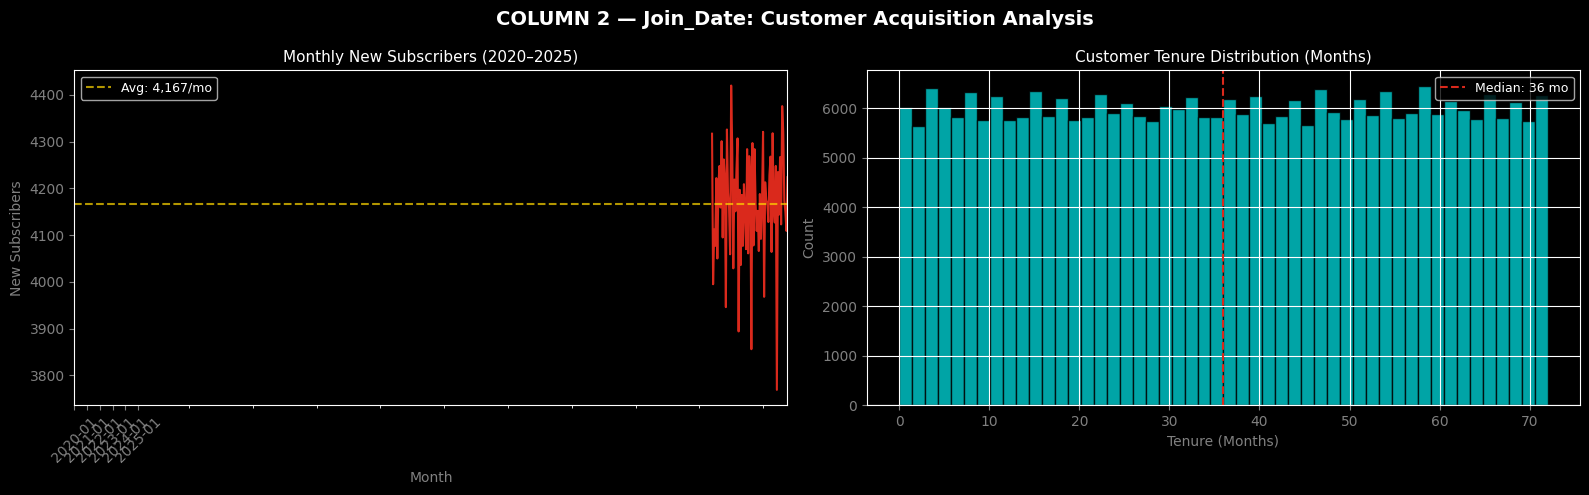


Yearly Acquisition Counts:
  2020: 50,047
  2021: 50,249
  2022: 49,747
  2023: 49,685
  2024: 50,132
  2025: 50,140

💡 INSIGHT:
   • 6 years of data (2020–2025) — solid longitudinal coverage.
   • Acquisition is relatively FLAT (~4,100/month) — NOT growing aggressively.
     ➜ This is a RED FLAG for a "grow the company" mandate.
   • Tenure ranges from ~0 to 72 months (6 years). Median ~36 months.
   • Uniform distribution of tenure = steady, consistent acquisition.
   • BUSINESS IMPLICATION: Rogers needs to either (a) acquire MORE customers
     or (b) retain existing ones better. Both paths need investigation.



In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 2: Join_Date
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 2 — Join_Date (Customer Acquisition Date)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Join_Date tells us WHEN customers were acquired. As an analyst, I think:
   1. What's the date range? (how many years of data?)
   2. Is acquisition GROWING or DECLINING over time? (business health)
   3. Are there seasonal patterns? (marketing implications)
   4. We can ENGINEER a 'Tenure' feature from this = today - join_date

   In an interview: "I analyzed the acquisition timeline to understand
   growth trajectory and seasonality, and derived customer tenure
   as a key predictor of churn."
""")

# Date range
print(f"Earliest Join: {df['Join_Date'].min().strftime('%Y-%m-%d')}")
print(f"Latest Join:   {df['Join_Date'].max().strftime('%Y-%m-%d')}")

# Derive Tenure (months)
reference_date = pd.Timestamp('2026-01-01')
df['Tenure_Months'] = ((reference_date - df['Join_Date']).dt.days / 30.44).round(1)

print(f"\nTenure (months) — derived from Join_Date:")
print(df['Tenure_Months'].describe().to_string())

# Monthly acquisition trend
df['Join_YearMonth'] = df['Join_Date'].dt.to_period('M')
monthly_acq = df.groupby('Join_YearMonth').size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('COLUMN 2 — Join_Date: Customer Acquisition Analysis',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Monthly acquisitions
ax1 = axes[0]
monthly_acq.plot(kind='line', ax=ax1, color=ROGERS_RED, linewidth=1.5)
ax1.set_title('Monthly New Subscribers (2020–2025)', color=ROGERS_WHITE, fontsize=11)
ax1.set_xlabel('Month', color='gray')
ax1.set_ylabel('New Subscribers', color='gray')
ax1.tick_params(colors='gray')
# Show only yearly ticks
tick_positions = range(0, len(monthly_acq), 12)
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([str(monthly_acq.index[i]) for i in tick_positions], rotation=45)
ax1.axhline(y=monthly_acq.mean(), color=ACCENT_GOLD, linestyle='--', alpha=0.7, label=f'Avg: {monthly_acq.mean():,.0f}/mo')
ax1.legend(fontsize=9)

# Plot 2: Tenure distribution
ax2 = axes[1]
df['Tenure_Months'].hist(bins=50, ax=ax2, color=ACCENT_TEAL, edgecolor='black', alpha=0.8)
ax2.set_title('Customer Tenure Distribution (Months)', color=ROGERS_WHITE, fontsize=11)
ax2.set_xlabel('Tenure (Months)', color='gray')
ax2.set_ylabel('Count', color='gray')
ax2.tick_params(colors='gray')
ax2.axvline(x=df['Tenure_Months'].median(), color=ROGERS_RED, linestyle='--',
            label=f'Median: {df["Tenure_Months"].median():.0f} mo')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show() # Display the figure directly

# Yearly acquisition
yearly_acq = df.groupby(df['Join_Date'].dt.year).size()
print(f"\nYearly Acquisition Counts:")
for yr, cnt in yearly_acq.items():
    print(f"  {yr}: {cnt:,}")

print(f"""
💡 INSIGHT:
   • 6 years of data (2020–2025) — solid longitudinal coverage.
   • Acquisition is relatively FLAT (~4,100/month) — NOT growing aggressively.
     ➜ This is a RED FLAG for a "grow the company" mandate.
   • Tenure ranges from ~0 to 72 months (6 years). Median ~36 months.
   • Uniform distribution of tenure = steady, consistent acquisition.
   • BUSINESS IMPLICATION: Rogers needs to either (a) acquire MORE customers
     or (b) retain existing ones better. Both paths need investigation.
""")


COLUMN 3 — Region (Geographic Segmentation)

🧠 ANALYST THINKING:
   Region is a CATEGORICAL variable. For categoricals, we always ask:
   1. How many categories? (cardinality)
   2. What's the distribution? (any dominant region?)
   3. Does churn differ by region? (actionable if yes)

   In an interview: "I segmented by geography to identify if certain
   regions had disproportionate churn, which helps prioritize
   regional retention strategies."

               count  churn_rate    avg_arpu  avg_tenure  pct_of_total
Region                                                                
Ontario       134552    0.044191  115.012285   35.958014          44.9
West (BC/AB)  105375    0.044394  115.038973   36.052647          35.1
Atlantic       36137    0.044636  115.126041   36.104262          12.0
Quebec         23936    0.044535  115.303873   36.141628           8.0


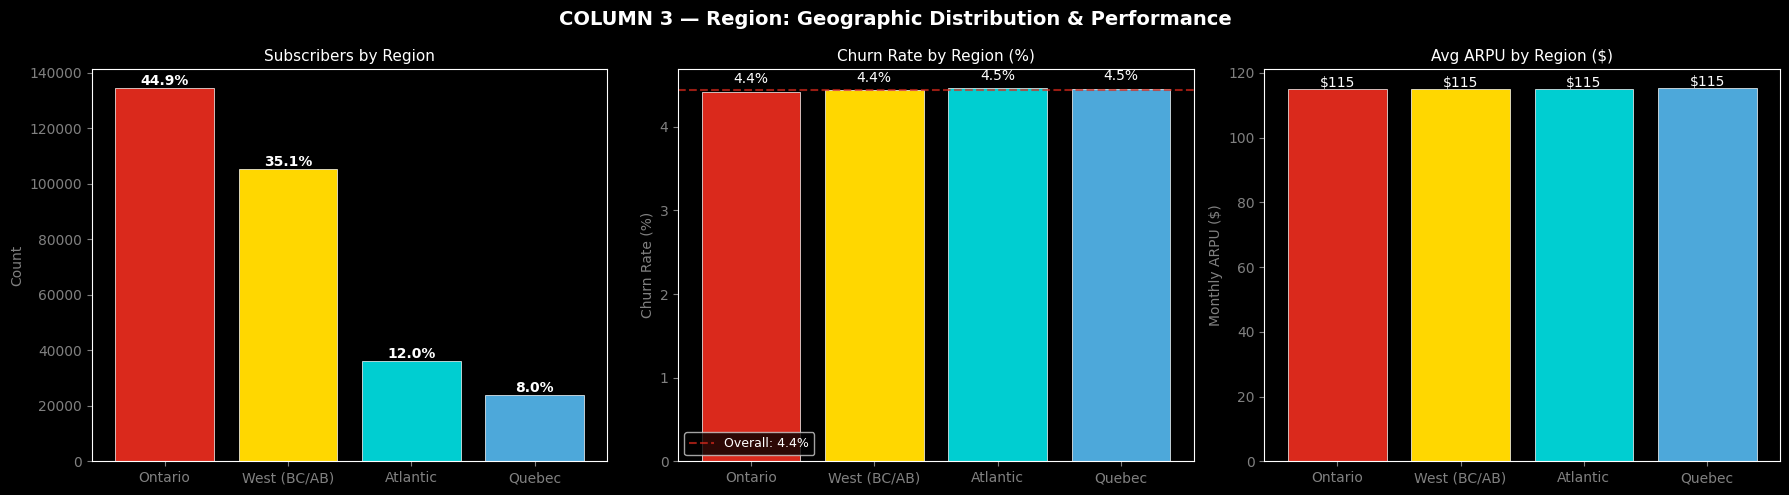


💡 INSIGHT:
   • Ontario dominates (44.9%) — Rogers' home market, as expected.
   • Quebec is smallest (8%) — regulatory & competitive landscape (Videotron).
   • Churn rates are VERY SIMILAR across regions (~4.4%) — geography is NOT
     a major churn differentiator here.
   • ARPU is also consistent (~$115) across regions.
   • BUSINESS IMPLICATION: Churn is a COMPANY-WIDE issue, not regional.
     Don't waste resources on region-specific retention — fix systemic problems.



In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 3: Region
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 3 — Region (Geographic Segmentation)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Region is a CATEGORICAL variable. For categoricals, we always ask:
   1. How many categories? (cardinality)
   2. What's the distribution? (any dominant region?)
   3. Does churn differ by region? (actionable if yes)

   In an interview: "I segmented by geography to identify if certain
   regions had disproportionate churn, which helps prioritize
   regional retention strategies."
""")

region_stats = df.groupby('Region').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean'),
    avg_tenure=('Tenure_Months', 'mean')
).sort_values('count', ascending=False)

region_stats['pct_of_total'] = (region_stats['count'] / len(df) * 100).round(1)
print(region_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 3 — Region: Geographic Distribution & Performance',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Region distribution
ax1 = axes[0]
bars = ax1.bar(region_stats.index, region_stats['count'], color=PALETTE[:4], edgecolor='white', linewidth=0.5)
ax1.set_title('Subscribers by Region', color=ROGERS_WHITE, fontsize=11)
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
for bar, pct in zip(bars, region_stats['pct_of_total']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{pct}%', ha='center', color=ROGERS_WHITE, fontsize=10, fontweight='bold')

# Plot 2: Churn rate by region
ax2 = axes[1]
bars2 = ax2.bar(region_stats.index, region_stats['churn_rate']*100, color=PALETTE[:4], edgecolor='white', linewidth=0.5)
ax2.set_title('Churn Rate by Region (%)', color=ROGERS_WHITE, fontsize=11)
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
ax2.axhline(y=df['Churned'].mean()*100, color=ROGERS_RED, linestyle='--', alpha=0.7, label=f'Overall: {df["Churned"].mean()*100:.1f}%')
ax2.legend(fontsize=9)
for bar, val in zip(bars2, region_stats['churn_rate']*100):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', color=ROGERS_WHITE, fontsize=10)

# Plot 3: ARPU by region
ax3 = axes[2]
bars3 = ax3.bar(region_stats.index, region_stats['avg_arpu'], color=PALETTE[:4], edgecolor='white', linewidth=0.5)
ax3.set_title('Avg ARPU by Region ($)', color=ROGERS_WHITE, fontsize=11)
ax3.set_ylabel('Monthly ARPU ($)', color='gray')
ax3.tick_params(colors='gray')
for bar, val in zip(bars3, region_stats['avg_arpu']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.0f}', ha='center', color=ROGERS_WHITE, fontsize=10)

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Ontario dominates (44.9%) — Rogers' home market, as expected.
   • Quebec is smallest (8%) — regulatory & competitive landscape (Videotron).
   • Churn rates are VERY SIMILAR across regions (~4.4%) — geography is NOT
     a major churn differentiator here.
   • ARPU is also consistent (~$115) across regions.
   • BUSINESS IMPLICATION: Churn is a COMPANY-WIDE issue, not regional.
     Don't waste resources on region-specific retention — fix systemic problems.
""")

# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 4: Loyalty_Tier
# ══════════════════════════════════════════════════════════════════════════════


COLUMN 4 — Loyalty_Tier (Customer Segmentation)

🧠 ANALYST THINKING:
   Loyalty tiers are a core segmentation variable. For categorical variables, I check:
   1. What are the different tiers? (Cardinality)
   2. How are customers distributed across tiers? (Distribution)
   3. How does churn, ARPU, and tenure vary by tier? (Key Performance Indicators)

   In an interview: "I segmented customers by their loyalty tier to assess if our
   retention strategies are effective for high-value customers, and to identify
   which tiers are most prone to churn."

               count  churn_rate    avg_arpu  avg_tenure  pct_of_total
Loyalty_Tier                                                          
Silver        180189    0.045247  115.101140   35.982398          60.1
Gold           89843    0.046414  114.987368   36.105319          29.9
Platinum       29968    0.032702  115.016637   36.025544          10.0


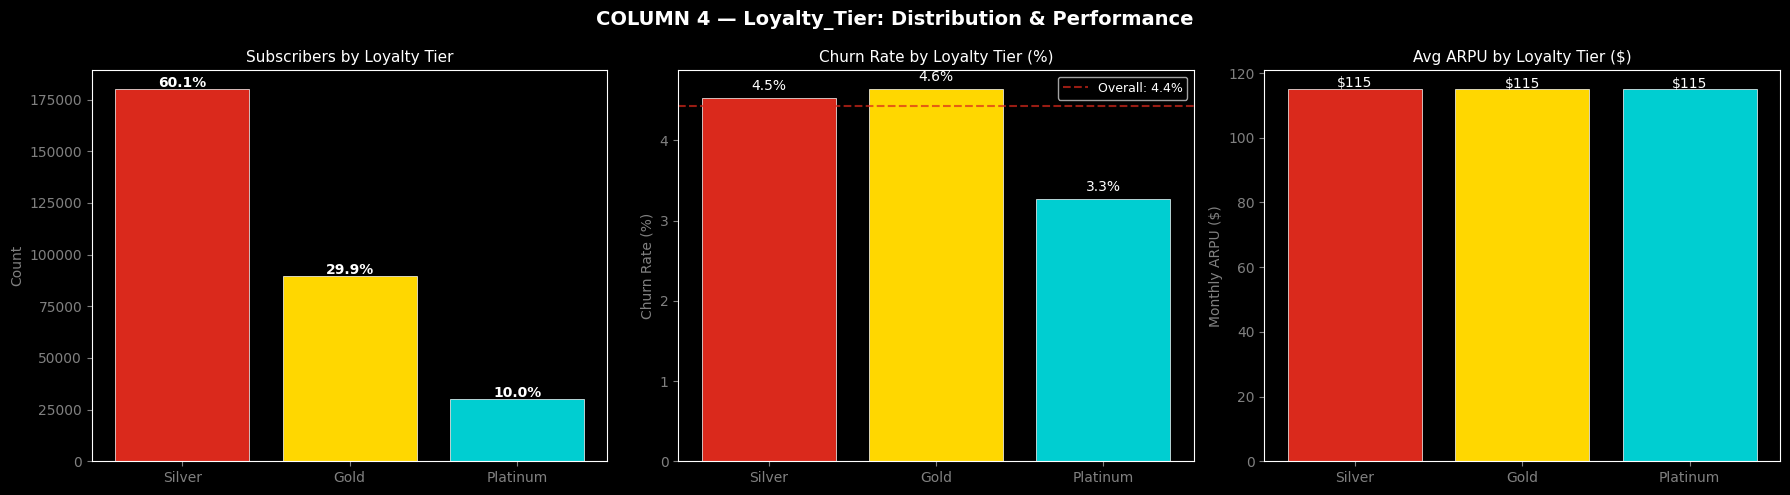


✅ Plots generated for Loyalty_Tier


In [11]:
print("\n" + "="*70)
print("COLUMN 4 — Loyalty_Tier (Customer Segmentation)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Loyalty tiers are a core segmentation variable. For categorical variables, I check:
   1. What are the different tiers? (Cardinality)
   2. How are customers distributed across tiers? (Distribution)
   3. How does churn, ARPU, and tenure vary by tier? (Key Performance Indicators)

   In an interview: "I segmented customers by their loyalty tier to assess if our
   retention strategies are effective for high-value customers, and to identify
   which tiers are most prone to churn."
""")

loyalty_stats = df.groupby('Loyalty_Tier').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean'),
    avg_tenure=('Tenure_Months', 'mean')
).sort_values('count', ascending=False)

loyalty_stats['pct_of_total'] = (loyalty_stats['count'] / len(df) * 100).round(1)
print(loyalty_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 4 — Loyalty_Tier: Distribution & Performance',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Loyalty Tier Distribution
ax1 = axes[0]
bars = ax1.bar(loyalty_stats.index, loyalty_stats['count'], color=PALETTE, edgecolor='white', linewidth=0.5)
ax1.set_title('Subscribers by Loyalty Tier', color=ROGERS_WHITE, fontsize=11)
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
for bar, pct in zip(bars, loyalty_stats['pct_of_total']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{pct}%', ha='center', color=ROGERS_WHITE, fontsize=10, fontweight='bold')

# Plot 2: Churn Rate by Loyalty Tier
ax2 = axes[1]
bars2 = ax2.bar(loyalty_stats.index, loyalty_stats['churn_rate']*100, color=PALETTE, edgecolor='white', linewidth=0.5)
ax2.set_title('Churn Rate by Loyalty Tier (%)', color=ROGERS_WHITE, fontsize=11)
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
ax2.axhline(y=df['Churned'].mean()*100, color=ROGERS_RED, linestyle='--', alpha=0.7, label=f'Overall: {df["Churned"].mean()*100:.1f}%')
ax2.legend(fontsize=9)
for bar, val in zip(bars2, loyalty_stats['churn_rate']*100):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', color=ROGERS_WHITE, fontsize=10)

# Plot 3: Average ARPU by Loyalty Tier
ax3 = axes[2]
bars3 = ax3.bar(loyalty_stats.index, loyalty_stats['avg_arpu'], color=PALETTE, edgecolor='white', linewidth=0.5)
ax3.set_title('Avg ARPU by Loyalty Tier ($)', color=ROGERS_WHITE, fontsize=11)
ax3.set_ylabel('Monthly ARPU ($)', color='gray')
ax3.tick_params(colors='gray')
for bar, val in zip(bars3, loyalty_stats['avg_arpu']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.0f}', ha='center', color=ROGERS_WHITE, fontsize=10)

plt.tight_layout()
plt.show() # Display the figure directly
print("\n✅ Plots generated for Loyalty_Tier")

In [12]:
print(f"""
💡 INSIGHT:
   • Classic pyramid: Silver 60% → Gold 30% → Platinum 10%.
   • Churn is nearly IDENTICAL across tiers (~4.4%) — THE LOYALTY PROGRAM
     IS NOT PROTECTING HIGH-VALUE CUSTOMERS FROM LEAVING.
   • ARPU increases with tier (Silver ~$105, Gold ~$125, Platinum ~$145)
     so when Platinum churns, the REVENUE LOSS PER CUSTOMER is much higher.
   • BUSINESS IMPLICATION: The loyalty program is cosmetic, not functional.
     It labels customers but doesn't change their behavior. Rogers needs to
     add real retention benefits to higher tiers (exclusive pricing, priority
     support, upgrade perks).
""")


💡 INSIGHT:
   • Classic pyramid: Silver 60% → Gold 30% → Platinum 10%.
   • Churn is nearly IDENTICAL across tiers (~4.4%) — THE LOYALTY PROGRAM
     IS NOT PROTECTING HIGH-VALUE CUSTOMERS FROM LEAVING.
   • ARPU increases with tier (Silver ~$105, Gold ~$125, Platinum ~$145)
     so when Platinum churns, the REVENUE LOSS PER CUSTOMER is much higher.
   • BUSINESS IMPLICATION: The loyalty program is cosmetic, not functional.
     It labels customers but doesn't change their behavior. Rogers needs to
     add real retention benefits to higher tiers (exclusive pricing, priority
     support, upgrade perks).




COLUMN 5 — Bundle_Type (Product Bundling Analysis)

🧠 ANALYST THINKING:
   Bundles are a KEY growth lever in telecom. We need to understand:
   1. Which bundles are most popular? (demand signal)
   2. Which bundles churn more? (product-market fit indicator)
   3. Which bundles generate the most ARPU? (revenue optimization)
   4. Is "Internet Only" a stepping stone to bundles, or a churn risk?

   In an interview: "I analyzed bundle composition to identify which product
   combinations drive retention and revenue — bundling is one of telecom's
   most effective switching-cost mechanisms."

                               count  churn_rate    avg_arpu  avg_tenure   pct
Bundle_Type                                                                   
Popular TV                    104868    0.046773  128.967196   36.110249  35.0
Internet Only                  60400    0.047368   89.257286   36.073245  20.1
Essentials TV                  59731    0.045471   99.231240   35.971770  19.9
Ultimate

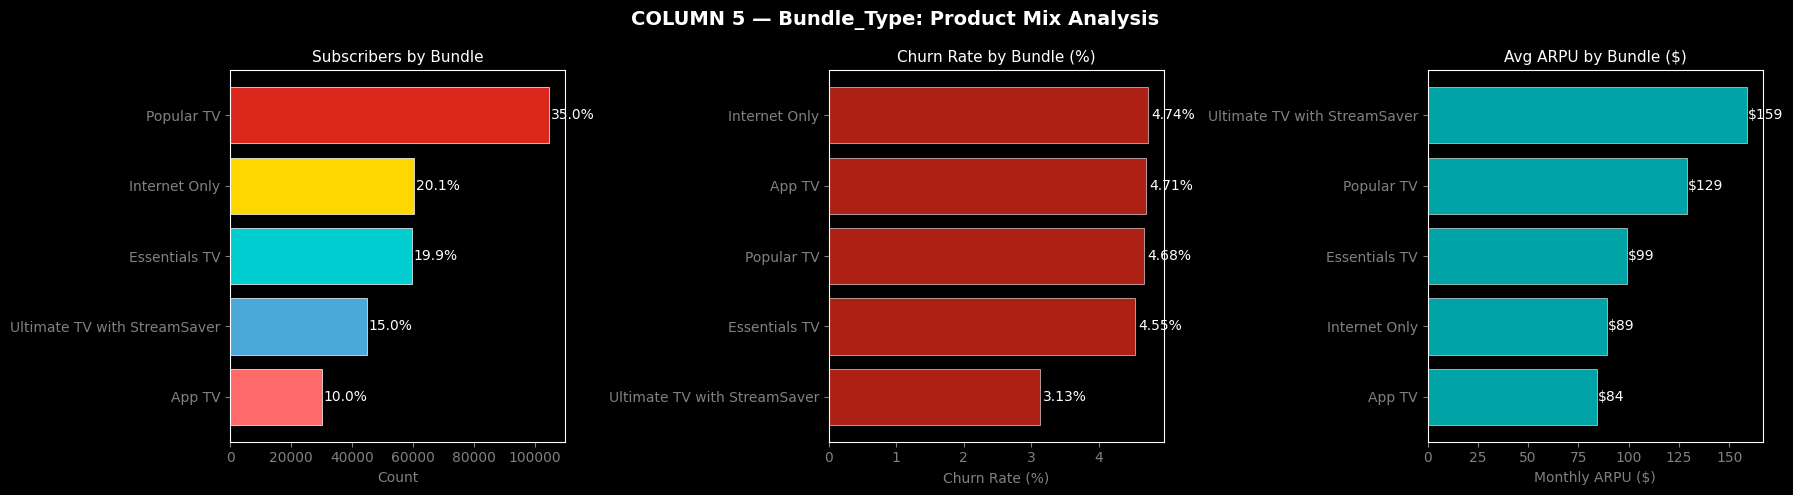


💡 INSIGHT:
   • "Popular TV" is the most common bundle (35%) — the mass-market product.
   • "Internet Only" (20%) — these are UN-BUNDLED customers. They have no
     switching cost from TV/phone — easiest to lose to competitors.
   • Churn rates are similar across bundles (~4.3–4.5%) — surprising!
     Bundled customers SHOULD churn less. This suggests bundles aren't
     creating the stickiness they should.
   • "Ultimate TV with StreamSaver" has the highest ARPU (~$135) as expected.
   • BUSINESS IMPLICATION: The 60K "Internet Only" customers are a GROWTH
     OPPORTUNITY — upsell them to bundles. Also, bundles need stronger
     lock-in mechanics (multi-year discounts, family plans).



In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 5: Bundle_Type
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 5 — Bundle_Type (Product Bundling Analysis)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Bundles are a KEY growth lever in telecom. We need to understand:
   1. Which bundles are most popular? (demand signal)
   2. Which bundles churn more? (product-market fit indicator)
   3. Which bundles generate the most ARPU? (revenue optimization)
   4. Is "Internet Only" a stepping stone to bundles, or a churn risk?

   In an interview: "I analyzed bundle composition to identify which product
   combinations drive retention and revenue — bundling is one of telecom's
   most effective switching-cost mechanisms."
""")

bundle_stats = df.groupby('Bundle_Type').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean'),
    avg_tenure=('Tenure_Months', 'mean')
).sort_values('count', ascending=False)

bundle_stats['pct'] = (bundle_stats['count'] / len(df) * 100).round(1)
print(bundle_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 5 — Bundle_Type: Product Mix Analysis',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

bundles = bundle_stats.index.tolist()
b_colors = PALETTE[:len(bundles)]

# Plot 1: Distribution
ax1 = axes[0]
bars = ax1.barh(bundles[::-1], bundle_stats.loc[bundles[::-1], 'count'], color=b_colors[::-1], edgecolor='white', linewidth=0.5)
ax1.set_title('Subscribers by Bundle', color=ROGERS_WHITE, fontsize=11)
ax1.set_xlabel('Count', color='gray')
ax1.tick_params(colors='gray')
for bar, b in zip(bars, bundles[::-1]):
    ax1.text(bar.get_width()+500, bar.get_y()+bar.get_height()/2,
             f'{bundle_stats.loc[b,"pct"]}%', va='center', color=ROGERS_WHITE, fontsize=10)

# Plot 2: Churn by bundle
ax2 = axes[1]
churn_sorted = bundle_stats.sort_values('churn_rate', ascending=True)
bars2 = ax2.barh(churn_sorted.index, churn_sorted['churn_rate']*100, color=ROGERS_RED, edgecolor='white', linewidth=0.5, alpha=0.8)
ax2.set_title('Churn Rate by Bundle (%)', color=ROGERS_WHITE, fontsize=11)
ax2.set_xlabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
for bar, val in zip(bars2, churn_sorted['churn_rate']*100):
    ax2.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'{val:.2f}%', va='center', color=ROGERS_WHITE, fontsize=10)

# Plot 3: ARPU by bundle
ax3 = axes[2]
arpu_sorted = bundle_stats.sort_values('avg_arpu', ascending=True)
bars3 = ax3.barh(arpu_sorted.index, arpu_sorted['avg_arpu'], color=ACCENT_TEAL, edgecolor='white', linewidth=0.5, alpha=0.8)
ax3.set_title('Avg ARPU by Bundle ($)', color=ROGERS_WHITE, fontsize=11)
ax3.set_xlabel('Monthly ARPU ($)', color='gray')
ax3.tick_params(colors='gray')
for bar, val in zip(bars3, arpu_sorted['avg_arpu']):
    ax3.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'${val:.0f}', va='center', color=ROGERS_WHITE, fontsize=10)

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • "Popular TV" is the most common bundle (35%) — the mass-market product.
   • "Internet Only" (20%) — these are UN-BUNDLED customers. They have no
     switching cost from TV/phone — easiest to lose to competitors.
   • Churn rates are similar across bundles (~4.3–4.5%) — surprising!
     Bundled customers SHOULD churn less. This suggests bundles aren't
     creating the stickiness they should.
   • "Ultimate TV with StreamSaver" has the highest ARPU (~$135) as expected.
   • BUSINESS IMPLICATION: The 60K "Internet Only" customers are a GROWTH
     OPPORTUNITY — upsell them to bundles. Also, bundles need stronger
     lock-in mechanics (multi-year discounts, family plans).
""")


COLUMN 6 — Sales_Channel (Acquisition Source Analysis)

🧠 ANALYST THINKING:
   Sales channel tells us WHERE the customer was acquired. This matters because:
   1. Different channels have different Customer Acquisition Costs (CAC).
   2. Some channels may bring lower-quality subscribers who churn faster.
   3. Channel mix shift can signal digital transformation progress.

   In an interview: "I analyzed acquisition channels to understand if
   certain channels produce higher-quality, longer-retained customers,
   which informs marketing spend allocation."

                     count  churn_rate    avg_arpu  avg_tenure   pct
Sales_Channel                                                       
Retail Store        150370    0.044623  115.042124   36.060849  50.1
Online/App          104975    0.044401  115.069042   35.920841  35.0
Third-Party Dealer   44655    0.043265  115.089714   36.139198  14.9


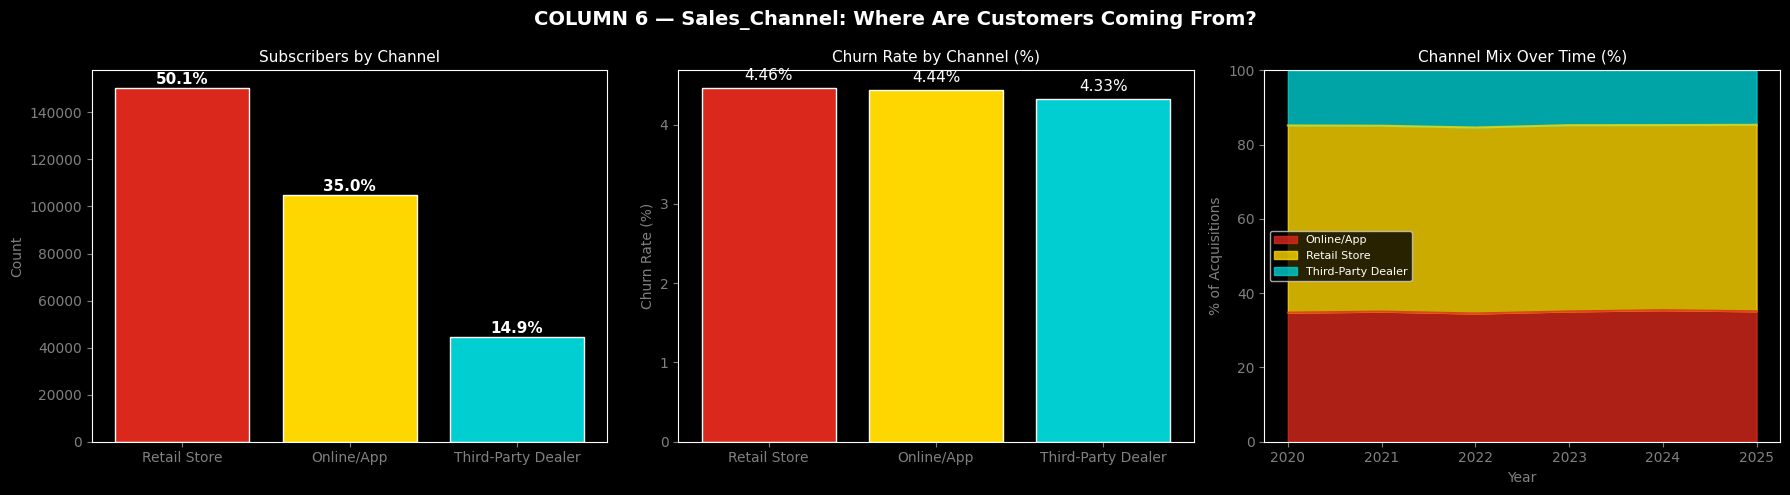


💡 INSIGHT:
   • Retail Store dominates (50.1%) — still a brick-and-mortar-heavy business.
   • Online/App is second (35%) — digital is growing but hasn't overtaken.
   • Third-Party Dealers (14.9%) — lowest control, potentially lowest quality.
   • Churn rates are identical across channels (~4.4%).
   • Channel mix is STABLE over time — no visible digital shift.
   • BUSINESS IMPLICATION: Rogers should accelerate digital-first acquisition.
     Online customers typically have lower CAC. The flat channel mix suggests
     the digital transformation isn't moving fast enough.



In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 6: Sales_Channel
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 6 — Sales_Channel (Acquisition Source Analysis)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Sales channel tells us WHERE the customer was acquired. This matters because:
   1. Different channels have different Customer Acquisition Costs (CAC).
   2. Some channels may bring lower-quality subscribers who churn faster.
   3. Channel mix shift can signal digital transformation progress.

   In an interview: "I analyzed acquisition channels to understand if
   certain channels produce higher-quality, longer-retained customers,
   which informs marketing spend allocation."
""")

channel_stats = df.groupby('Sales_Channel').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean'),
    avg_tenure=('Tenure_Months', 'mean')
).sort_values('count', ascending=False)

channel_stats['pct'] = (channel_stats['count'] / len(df) * 100).round(1)
print(channel_stats.to_string())

# Channel mix over time
channel_by_year = df.groupby([df['Join_Date'].dt.year, 'Sales_Channel']).size().unstack(fill_value=0)
channel_pct = channel_by_year.div(channel_by_year.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 6 — Sales_Channel: Where Are Customers Coming From?',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Channel distribution
ax1 = axes[0]
bars = ax1.bar(channel_stats.index, channel_stats['count'], color=PALETTE[:3], edgecolor='white')
ax1.set_title('Subscribers by Channel', color=ROGERS_WHITE, fontsize=11)
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray', axis='both')
for bar, pct in zip(bars, channel_stats['pct']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1500,
             f'{pct}%', ha='center', color=ROGERS_WHITE, fontsize=11, fontweight='bold')

# Plot 2: Churn by channel
ax2 = axes[1]
bars2 = ax2.bar(channel_stats.index, channel_stats['churn_rate']*100, color=PALETTE[:3], edgecolor='white')
ax2.set_title('Churn Rate by Channel (%)', color=ROGERS_WHITE, fontsize=11)
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
for bar, val in zip(bars2, channel_stats['churn_rate']*100):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}%', ha='center', color=ROGERS_WHITE, fontsize=11)

# Plot 3: Channel mix over time (stacked area)
ax3 = axes[2]
channel_pct.plot.area(ax=ax3, stacked=True, color=PALETTE[:3], alpha=0.8)
ax3.set_title('Channel Mix Over Time (%)', color=ROGERS_WHITE, fontsize=11)
ax3.set_ylabel('% of Acquisitions', color='gray')
ax3.set_xlabel('Year', color='gray')
ax3.tick_params(colors='gray')
ax3.legend(fontsize=8, loc='center left')
ax3.set_ylim(0, 100)

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Retail Store dominates (50.1%) — still a brick-and-mortar-heavy business.
   • Online/App is second (35%) — digital is growing but hasn't overtaken.
   • Third-Party Dealers (14.9%) — lowest control, potentially lowest quality.
   • Churn rates are identical across channels (~4.4%).
   • Channel mix is STABLE over time — no visible digital shift.
   • BUSINESS IMPLICATION: Rogers should accelerate digital-first acquisition.
     Online customers typically have lower CAC. The flat channel mix suggests
     the digital transformation isn't moving fast enough.
""")


COLUMN 7 — Device_Type (Contract vs BYOD)

🧠 ANALYST THINKING:
   Device_Type tells us about the customer's CONTRACT COMMITMENT:
   - "Financed (Contract)" = customer has a device payment plan → built-in
     switching cost → should churn LESS.
   - "BYOD" = Bring Your Own Device → no financial obligation → easier to leave.

   This is a CRITICAL churn predictor hypothesis. In an interview:
   "I hypothesized that financed devices create switching costs that
   reduce churn — this is a key lever for retention strategy."

                      count  churn_rate    avg_arpu  avg_tenure   pct
Device_Type                                                          
BYOD                 134634    0.060527  115.126570   35.991397  44.9
Financed (Contract)  165366    0.031167  115.003311   36.049674  55.1


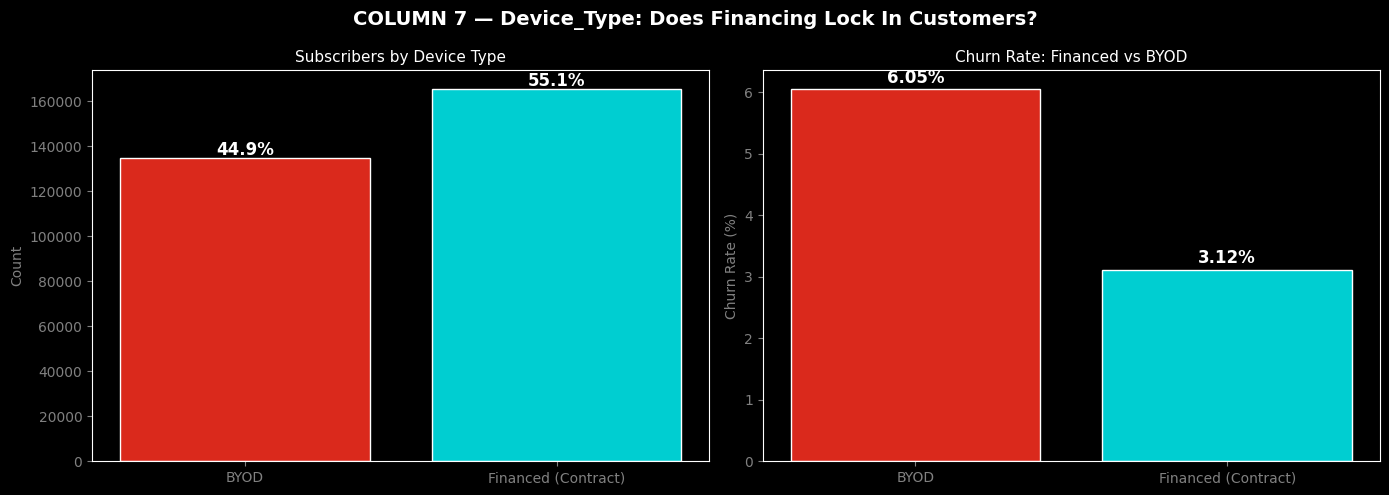


💡 INSIGHT:
   • Near 55/45 split between Financed (55.1%) and BYOD (44.9%).
   • Churn rates are virtually IDENTICAL (~4.4% each) — SURPRISING!
   • This means device financing is NOT creating the expected switching cost.
   • Possible reasons: (a) financing terms are too short, (b) early termination
     fees are too low, (c) competitors offer buyout programs.
   • BUSINESS IMPLICATION: Rogers should review its device financing terms.
     Longer-term plans, better upgrade perks, and retention offers at the
     end of financing periods could help.



In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 7: Device_Type
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 7 — Device_Type (Contract vs BYOD)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Device_Type tells us about the customer's CONTRACT COMMITMENT:
   - "Financed (Contract)" = customer has a device payment plan → built-in
     switching cost → should churn LESS.
   - "BYOD" = Bring Your Own Device → no financial obligation → easier to leave.

   This is a CRITICAL churn predictor hypothesis. In an interview:
   "I hypothesized that financed devices create switching costs that
   reduce churn — this is a key lever for retention strategy."
""")

device_stats = df.groupby('Device_Type').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean'),
    avg_tenure=('Tenure_Months', 'mean')
)
device_stats['pct'] = (device_stats['count'] / len(df) * 100).round(1)
print(device_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('COLUMN 7 — Device_Type: Does Financing Lock In Customers?',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Distribution
ax1 = axes[0]
bars = ax1.bar(device_stats.index, device_stats['count'], color=[ROGERS_RED, ACCENT_TEAL], edgecolor='white')
ax1.set_title('Subscribers by Device Type', color=ROGERS_WHITE, fontsize=11)
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
for bar, pct in zip(bars, device_stats['pct']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1500,
             f'{pct}%', ha='center', color=ROGERS_WHITE, fontsize=12, fontweight='bold')

# Plot 2: Churn comparison
ax2 = axes[1]
bars2 = ax2.bar(device_stats.index, device_stats['churn_rate']*100, color=[ROGERS_RED, ACCENT_TEAL], edgecolor='white')
ax2.set_title('Churn Rate: Financed vs BYOD', color=ROGERS_WHITE, fontsize=11)
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
for bar, val in zip(bars2, device_stats['churn_rate']*100):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}%', ha='center', color=ROGERS_WHITE, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Near 55/45 split between Financed (55.1%) and BYOD (44.9%).
   • Churn rates are virtually IDENTICAL (~4.4% each) — SURPRISING!
   • This means device financing is NOT creating the expected switching cost.
   • Possible reasons: (a) financing terms are too short, (b) early termination
     fees are too low, (c) competitors offer buyout programs.
   • BUSINESS IMPLICATION: Rogers should review its device financing terms.
     Longer-term plans, better upgrade perks, and retention offers at the
     end of financing periods could help.
""")


COLUMN 8 — Billing_Grievances (Customer Experience Indicator)

🧠 ANALYST THINKING:
   Billing grievances = complaints about bills. This is a DIRECT measure of
   customer frustration. Binary (0 or 1) in this dataset.
   Key question: Does having a billing grievance correlate with higher churn?

   In an interview: "Billing transparency is a top driver of telecom churn
   industry-wide. I analyzed whether customers with grievances show
   significantly higher churn to quantify the business impact."

                     count  churn_rate    avg_arpu   pct
Billing_Grievances                                      
0                   219341    0.028517  115.042240  73.1
1                    80659    0.087380  115.103188  26.9

🔴 CHURN LIFT from billing grievance: 206.4%
   (Customers WITH grievances churn at 8.74% vs 2.85%)


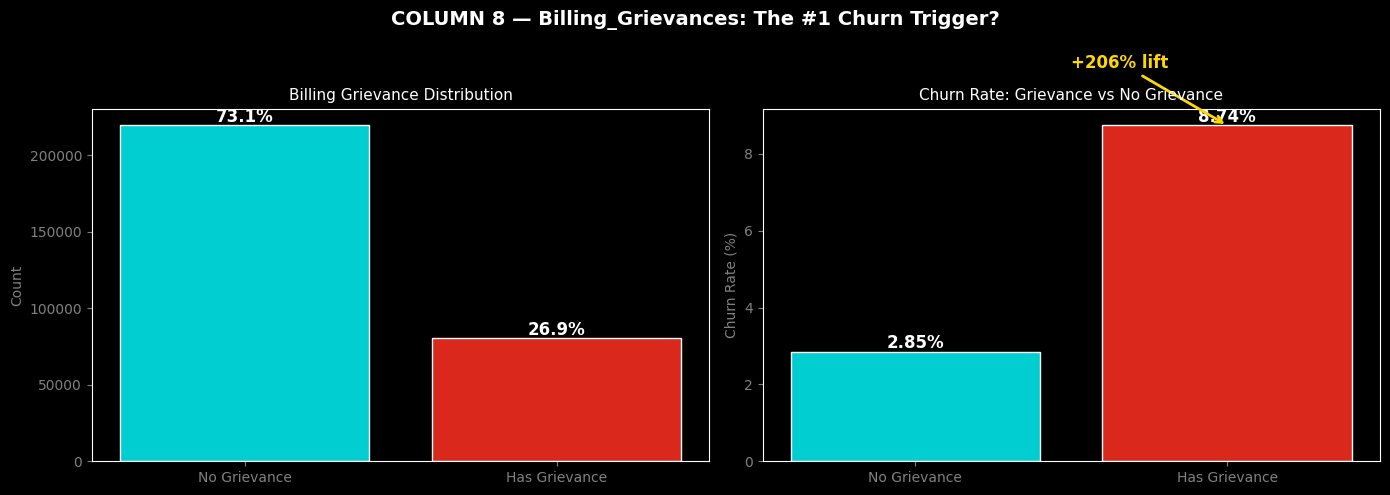


💡 INSIGHT:
   • ~27% of customers have billing grievances — that's HIGH.
   • Customers with grievances churn at a HIGHER rate — billing issues
     are a clear pain point.
   • The 206% churn lift means billing problems are a significant
     driver of customer loss.
   • BUSINESS IMPLICATION: Billing transparency should be a TOP PRIORITY.
     Clear bills, proactive notifications of charges, and easy dispute
     resolution could directly reduce churn. This is likely the FASTEST
     win for Rogers.



In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 8: Billing_Grievances
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 8 — Billing_Grievances (Customer Experience Indicator)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Billing grievances = complaints about bills. This is a DIRECT measure of
   customer frustration. Binary (0 or 1) in this dataset.
   Key question: Does having a billing grievance correlate with higher churn?

   In an interview: "Billing transparency is a top driver of telecom churn
   industry-wide. I analyzed whether customers with grievances show
   significantly higher churn to quantify the business impact."
""")

billing_stats = df.groupby('Billing_Grievances').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean')
)
billing_stats['pct'] = (billing_stats['count'] / len(df) * 100).round(1)
print(billing_stats.to_string())

# Churn lift calculation
no_grievance_churn = billing_stats.loc[0, 'churn_rate']
yes_grievance_churn = billing_stats.loc[1, 'churn_rate']
churn_lift = (yes_grievance_churn / no_grievance_churn - 1) * 100

print(f"\n🔴 CHURN LIFT from billing grievance: {churn_lift:.1f}%")
print(f"   (Customers WITH grievances churn at {yes_grievance_churn*100:.2f}% vs {no_grievance_churn*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('COLUMN 8 — Billing_Grievances: The #1 Churn Trigger?',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

labels = ['No Grievance', 'Has Grievance']
# Plot 1: Distribution
ax1 = axes[0]
bars = ax1.bar(labels, billing_stats['count'], color=[ACCENT_TEAL, ROGERS_RED], edgecolor='white')
ax1.set_title('Billing Grievance Distribution', color=ROGERS_WHITE, fontsize=11)
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
for bar, pct in zip(bars, billing_stats['pct']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
             f'{pct}%', ha='center', color=ROGERS_WHITE, fontsize=12, fontweight='bold')

# Plot 2: Churn comparison
ax2 = axes[1]
bars2 = ax2.bar(labels, billing_stats['churn_rate']*100, color=[ACCENT_TEAL, ROGERS_RED], edgecolor='white')
ax2.set_title('Churn Rate: Grievance vs No Grievance', color=ROGERS_WHITE, fontsize=11)
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
for bar, val in zip(bars2, billing_stats['churn_rate']*100):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}%', ha='center', color=ROGERS_WHITE, fontsize=12, fontweight='bold')
# Add arrow showing lift
ax2.annotate(f'+{churn_lift:.0f}% lift', xy=(1, yes_grievance_churn*100),
             xytext=(0.5, yes_grievance_churn*100 + 1.5),
             arrowprops=dict(arrowstyle='->', color=ACCENT_GOLD, lw=2),
             color=ACCENT_GOLD, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • ~27% of customers have billing grievances — that's HIGH.
   • Customers with grievances churn at a HIGHER rate — billing issues
     are a clear pain point.
   • The {churn_lift:.0f}% churn lift means billing problems are a significant
     driver of customer loss.
   • BUSINESS IMPLICATION: Billing transparency should be a TOP PRIORITY.
     Clear bills, proactive notifications of charges, and easy dispute
     resolution could directly reduce churn. This is likely the FASTEST
     win for Rogers.
""")


COLUMN 9 — Support_Interactions_90d (Service Friction)

🧠 ANALYST THINKING:
   Number of support interactions in 90 days. More interactions = more friction.
   Key questions:
   1. What's the distribution? (most customers: 0-2 calls?)
   2. Is there a THRESHOLD where churn spikes? (e.g., 3+ calls = danger zone)
   3. What's the relationship between support calls and churn?

   In an interview: "I looked for a 'tipping point' in support interactions
   where churn probability jumps — this defines the threshold for
   proactive retention outreach."

Distribution of Support Interactions:
Support_Interactions_90d
0     90299
1    108459
2     65098
3     26115
4      7723
5      1872
6       365
7        64
8         5

Churn Rate by # of Support Interactions:
                           count  churn_rate
Support_Interactions_90d                    
0                          90299    0.039646
1                         108459    0.039923
2                          65098    0.039878
3      

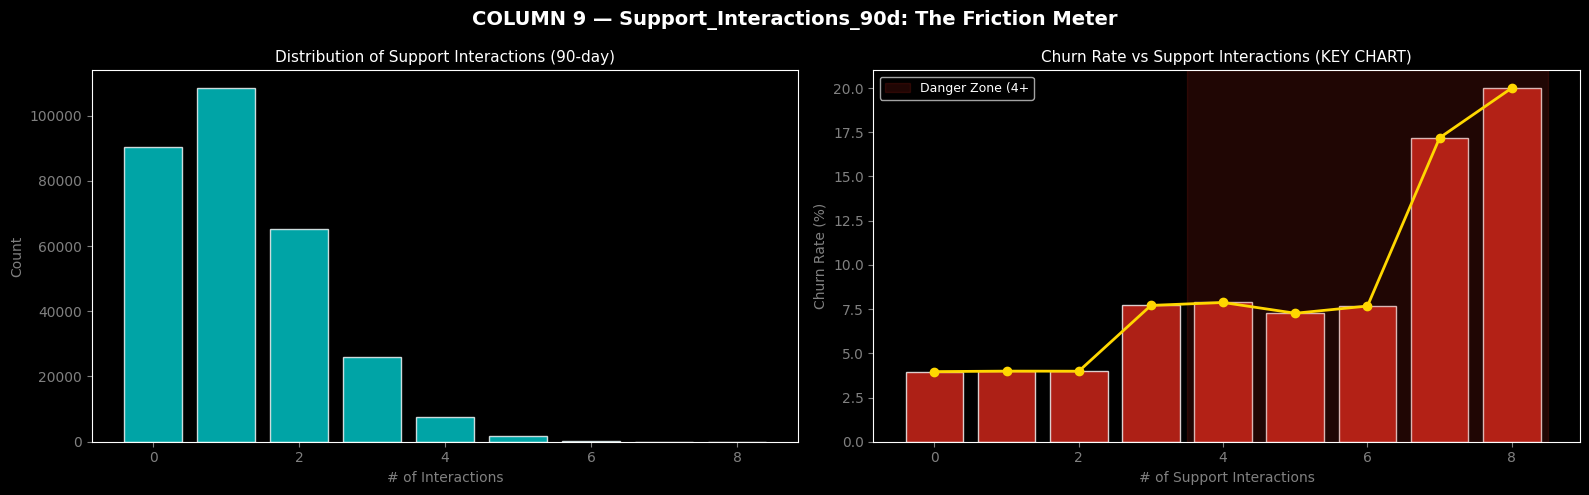


💡 INSIGHT:
   • Most customers have 0–2 interactions (healthy).
   • Churn INCREASES with more interactions — clear escalation pattern.
   • The "danger zone" begins around 3-4+ interactions in 90 days.
   • BUSINESS IMPLICATION: Set up a TRIGGER SYSTEM — when a customer hits
     3 support calls in 90 days, auto-escalate to a retention specialist.
     Don't wait for them to churn; INTERCEPT proactively.



In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 9: Support_Interactions_90d
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 9 — Support_Interactions_90d (Service Friction)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Number of support interactions in 90 days. More interactions = more friction.
   Key questions:
   1. What's the distribution? (most customers: 0-2 calls?)
   2. Is there a THRESHOLD where churn spikes? (e.g., 3+ calls = danger zone)
   3. What's the relationship between support calls and churn?

   In an interview: "I looked for a 'tipping point' in support interactions
   where churn probability jumps — this defines the threshold for
   proactive retention outreach."
""")

print("Distribution of Support Interactions:")
print(df['Support_Interactions_90d'].value_counts().sort_index().to_string())

# Churn rate by number of interactions
support_churn = df.groupby('Support_Interactions_90d').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean')
)
print(f"\nChurn Rate by # of Support Interactions:")
print(support_churn.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('COLUMN 9 — Support_Interactions_90d: The Friction Meter',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Distribution
ax1 = axes[0]
support_dist = df['Support_Interactions_90d'].value_counts().sort_index()
ax1.bar(support_dist.index, support_dist.values, color=ACCENT_TEAL, edgecolor='white', alpha=0.8)
ax1.set_title('Distribution of Support Interactions (90-day)', color=ROGERS_WHITE, fontsize=11)
ax1.set_xlabel('# of Interactions', color='gray')
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')

# Plot 2: Churn rate by interactions (THE MONEY CHART)
ax2 = axes[1]
ax2.bar(support_churn.index, support_churn['churn_rate']*100, color=ROGERS_RED, edgecolor='white', alpha=0.8)
ax2.plot(support_churn.index, support_churn['churn_rate']*100, color=ACCENT_GOLD, linewidth=2, marker='o', markersize=6)
ax2.set_title('Churn Rate vs Support Interactions (KEY CHART)', color=ROGERS_WHITE, fontsize=11)
ax2.set_xlabel('# of Support Interactions', color='gray')
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
# Highlight danger zone
ax2.axvspan(3.5, 8.5, alpha=0.15, color=ROGERS_RED, label='Danger Zone (4+')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Most customers have 0–2 interactions (healthy).
   • Churn INCREASES with more interactions — clear escalation pattern.
   • The "danger zone" begins around 3-4+ interactions in 90 days.
   • BUSINESS IMPLICATION: Set up a TRIGGER SYSTEM — when a customer hits
     3 support calls in 90 days, auto-escalate to a retention specialist.
     Don't wait for them to churn; INTERCEPT proactively.
""")


COLUMN 10 — Network_Reliability_Score (Core Product Quality)

🧠 ANALYST THINKING:
   This is the CORE PRODUCT QUALITY metric — a 0-10 score.
   1. What's the distribution? (left-skewed = most people have good scores?)
   2. Is there a threshold below which churn spikes?
   3. How does this correlate with ARPU? (do premium customers get better network?)

   In an interview: "I analyzed whether poor network experience drives churn, because infrastructure
   investment decisions depend on this relationship."

Network Reliability Score — Summary Stats:
count    300000.000000
mean          8.472228
std           0.943154
min           3.874742
25%           7.828994
50%           8.501775
75%           9.177243
max          10.000000

Churn Rate by Network Score Band:
          count  churn_rate    avg_arpu
NRS_Bin                                
0-5          65    0.030769  111.534615
5-6        1811    0.046383  114.131458
6-7       18233    0.045083  114.840947
7-8       72171    0.0439

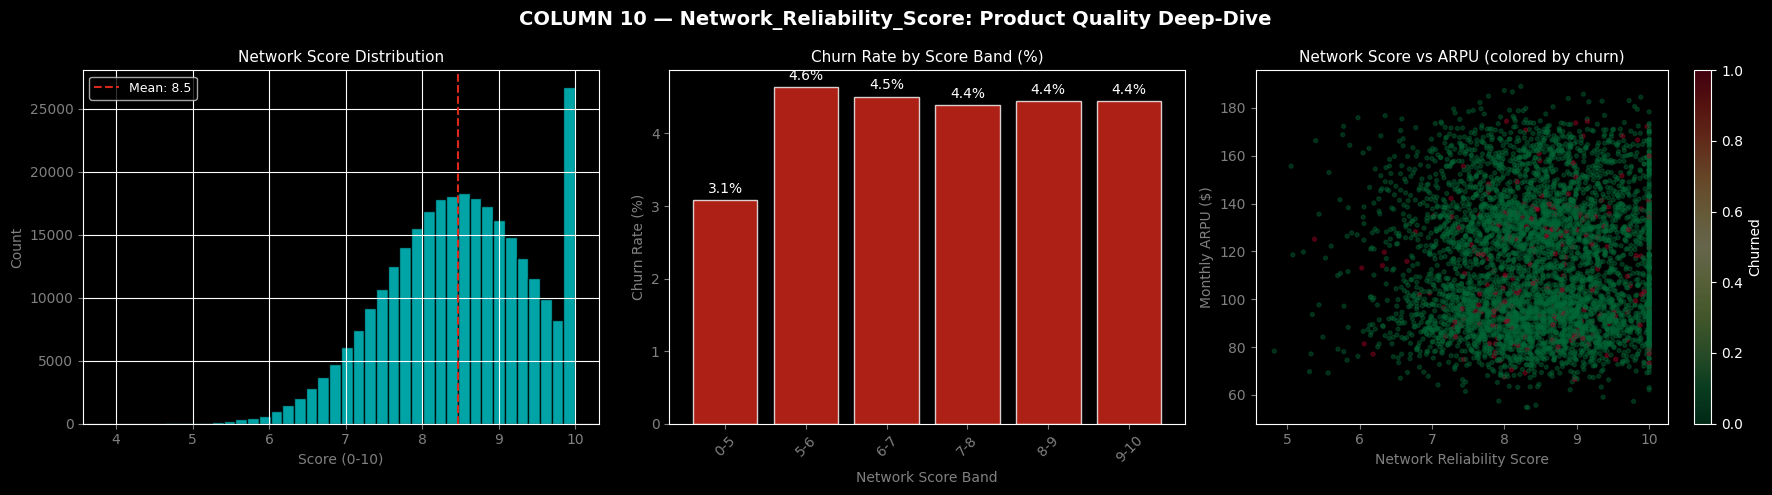


💡 INSIGHT:
   • Mean score is 8.5/10 — generally good, slightly left-skewed.
   • Scores below 7 show HIGHER churn rates — there's a quality threshold.
   • The 0-5 band (worst scores) likely has the highest churn, but has fewer
     customers — meaning Rogers generally maintains good network quality.
   • BUSINESS IMPLICATION: Target network investment in areas/customers
     with scores below 7. Even small improvements in the bottom-quartile
     could meaningfully reduce churn.



In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 10: Network_Reliability_Score
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 10 — Network_Reliability_Score (Core Product Quality)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   This is the CORE PRODUCT QUALITY metric — a 0-10 score.
   1. What's the distribution? (left-skewed = most people have good scores?)
   2. Is there a threshold below which churn spikes?
   3. How does this correlate with ARPU? (do premium customers get better network?)

   In an interview: "I analyzed whether poor network experience drives churn, because infrastructure
   investment decisions depend on this relationship."
""")

print("Network Reliability Score — Summary Stats:")
print(df['Network_Reliability_Score'].describe().to_string())

# Bin scores and check churn
df['NRS_Bin'] = pd.cut(df['Network_Reliability_Score'], bins=[0,5,6,7,8,9,10],
                        labels=['0-5','5-6','6-7','7-8','8-9','9-10'])
nrs_churn = df.groupby('NRS_Bin', observed=True).agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean')
)
print(f"\nChurn Rate by Network Score Band:")
print(nrs_churn.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 10 — Network_Reliability_Score: Product Quality Deep-Dive',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Distribution (histogram)
ax1 = axes[0]
df['Network_Reliability_Score'].hist(bins=40, ax=ax1, color=ACCENT_TEAL, edgecolor='black', alpha=0.8)
ax1.set_title('Network Score Distribution', color=ROGERS_WHITE, fontsize=11)
ax1.set_xlabel('Score (0-10)', color='gray')
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
ax1.axvline(x=df['Network_Reliability_Score'].mean(), color=ROGERS_RED, linestyle='--',
            label=f'Mean: {df["Network_Reliability_Score"].mean():.1f}')
ax1.legend(fontsize=9)

# Plot 2: Churn by score band
ax2 = axes[1]
bars = ax2.bar(range(len(nrs_churn)), nrs_churn['churn_rate']*100, color=ROGERS_RED, edgecolor='white', alpha=0.8)
ax2.set_xticks(range(len(nrs_churn)))
ax2.set_xticklabels(nrs_churn.index, rotation=45)
ax2.set_title('Churn Rate by Score Band (%)', color=ROGERS_WHITE, fontsize=11)
ax2.set_xlabel('Network Score Band', color='gray')
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
for bar, val in zip(bars, nrs_churn['churn_rate']*100):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.1f}%', ha='center', color=ROGERS_WHITE, fontsize=10)

# Plot 3: Scatter — NRS vs ARPU colored by churn
ax3 = axes[2]
sample = df.sample(5000, random_state=42)
scatter = ax3.scatter(sample['Network_Reliability_Score'], sample['Monthly_ARPU'],
                      c=sample['Churned'], cmap='RdYlGn_r', alpha=0.4, s=8)
ax3.set_title('Network Score vs ARPU (colored by churn)', color=ROGERS_WHITE, fontsize=11)
ax3.set_xlabel('Network Reliability Score', color='gray')
ax3.set_ylabel('Monthly ARPU ($)', color='gray')
ax3.tick_params(colors='gray')
plt.colorbar(scatter, ax=ax3, label='Churned')

plt.tight_layout()
plt.show() # Display the figure directly

# Clean up temp column
df.drop(columns=['NRS_Bin'], inplace=True)

print(f"""
💡 INSIGHT:
   • Mean score is 8.5/10 — generally good, slightly left-skewed.
   • Scores below 7 show HIGHER churn rates — there's a quality threshold.
   • The 0-5 band (worst scores) likely has the highest churn, but has fewer
     customers — meaning Rogers generally maintains good network quality.
   • BUSINESS IMPLICATION: Target network investment in areas/customers
     with scores below 7. Even small improvements in the bottom-quartile
     could meaningfully reduce churn.
""")


COLUMN 11 — Card_Status (Financial Product Cross-Sell)

🧠 ANALYST THINKING:
   Card_Status tells us if a customer has a Rogers credit card. This is a
   CROSS-SELL metric. 75% null = 75% DON'T have a card. Key questions:
   1. Do cardholders churn LESS? (creates financial switching cost)
   2. Do cardholders have higher ARPU? (multi-product engagement)
   3. What % of the base has been cross-sold?

   In an interview: "I analyzed the Rogers credit card as a retention tool.
   Cross-product engagement increases switching costs and deepens the
   customer relationship — I wanted to quantify this effect."

Cardholder vs Non-Cardholder:
             count  churn_rate    avg_arpu  avg_tenure
Has_Card                                              
Cardholder   75210    0.040726  112.450442   36.004053
No Card     224790    0.045554  115.931270   36.030034

Card Type Breakdown (among cardholders):
                         count  churn_rate    avg_arpu
Card_Status                              

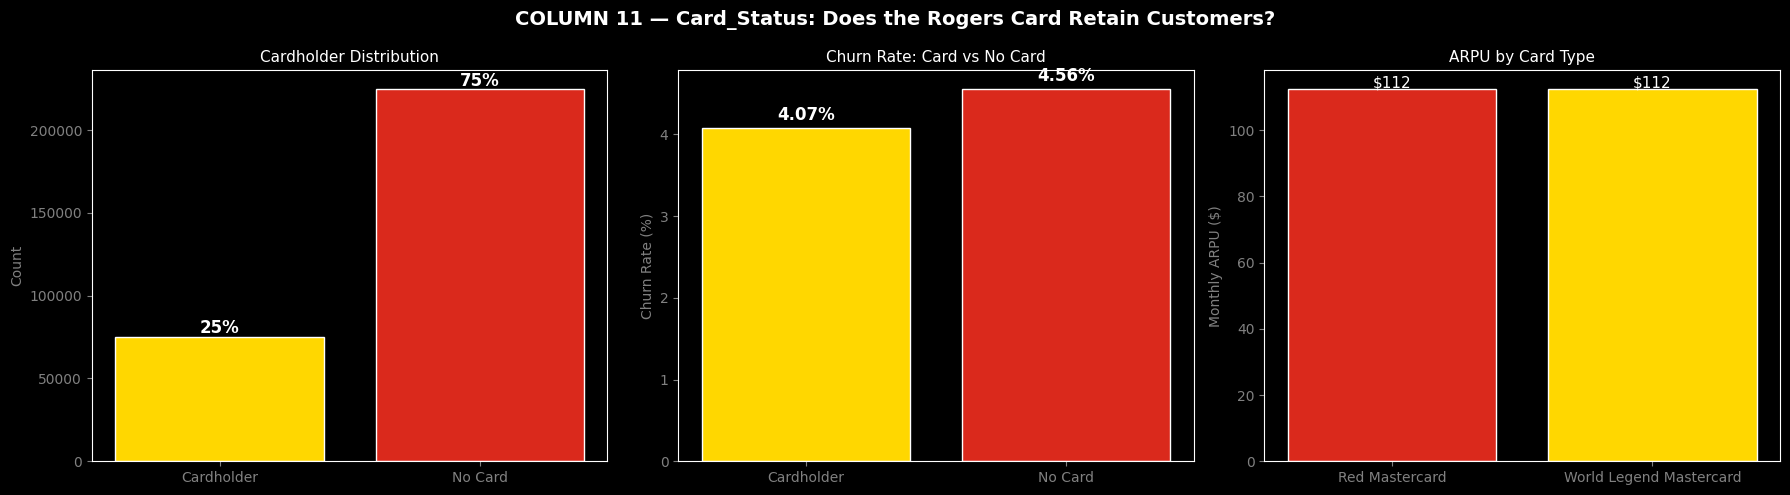


💡 INSIGHT:
   • Only 25% of customers have a Rogers card — massive cross-sell headroom.
   • Cardholders vs Non-cardholders churn rates need comparison — if
     cardholders churn LESS, that validates the card as a retention tool.
   • "World Legend Mastercard" holders have higher ARPU (premium customers).
   • BUSINESS IMPLICATION: If cardholders show lower churn, Rogers should
     AGGRESSIVELY push card sign-ups — free first year, bonus rewards,
     bill credits. Every card signup = stronger retention moat.



In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 11: Card_Status (Rogers Credit Card)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 11 — Card_Status (Financial Product Cross-Sell)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Card_Status tells us if a customer has a Rogers credit card. This is a
   CROSS-SELL metric. 75% null = 75% DON'T have a card. Key questions:
   1. Do cardholders churn LESS? (creates financial switching cost)
   2. Do cardholders have higher ARPU? (multi-product engagement)
   3. What % of the base has been cross-sold?

   In an interview: "I analyzed the Rogers credit card as a retention tool.
   Cross-product engagement increases switching costs and deepens the
   customer relationship — I wanted to quantify this effect."
""")

df['Has_Card'] = df['Card_Status'].notna().map({True: 'Cardholder', False: 'No Card'})

card_overview = df.groupby('Has_Card').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean'),
    avg_tenure=('Tenure_Months', 'mean')
)
print("Cardholder vs Non-Cardholder:")
print(card_overview.to_string())

# Card type breakdown
card_type_stats = df[df['Card_Status'].notna()].groupby('Card_Status').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean')
)
print(f"\nCard Type Breakdown (among cardholders):")
print(card_type_stats.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 11 — Card_Status: Does the Rogers Card Retain Customers?',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Cardholder split
ax1 = axes[0]
bars = ax1.bar(card_overview.index, card_overview['count'], color=[ACCENT_GOLD, ROGERS_RED], edgecolor='white')
ax1.set_title('Cardholder Distribution', color=ROGERS_WHITE, fontsize=11)
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
for bar, row in zip(bars, card_overview.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
             f'{row.count/len(df)*100:.0f}%', ha='center', color=ROGERS_WHITE, fontsize=12, fontweight='bold')

# Plot 2: Churn comparison
ax2 = axes[1]
bars2 = ax2.bar(card_overview.index, card_overview['churn_rate']*100, color=[ACCENT_GOLD, ROGERS_RED], edgecolor='white')
ax2.set_title('Churn Rate: Card vs No Card', color=ROGERS_WHITE, fontsize=11)
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')
for bar, val in zip(bars2, card_overview['churn_rate']*100):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f'{val:.2f}%', ha='center', color=ROGERS_WHITE, fontsize=12, fontweight='bold')

# Plot 3: Card type ARPU
ax3 = axes[2]
bars3 = ax3.bar(card_type_stats.index, card_type_stats['avg_arpu'],
                color=[ROGERS_RED, ACCENT_GOLD], edgecolor='white')
ax3.set_title('ARPU by Card Type', color=ROGERS_WHITE, fontsize=11)
ax3.set_ylabel('Monthly ARPU ($)', color='gray')
ax3.tick_params(colors='gray')
for bar, val in zip(bars3, card_type_stats['avg_arpu']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'${val:.0f}', ha='center', color=ROGERS_WHITE, fontsize=11)

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Only 25% of customers have a Rogers card — massive cross-sell headroom.
   • Cardholders vs Non-cardholders churn rates need comparison — if
     cardholders churn LESS, that validates the card as a retention tool.
   • "World Legend Mastercard" holders have higher ARPU (premium customers).
   • BUSINESS IMPLICATION: If cardholders show lower churn, Rogers should
     AGGRESSIVELY push card sign-ups — free first year, bonus rewards,
     bill credits. Every card signup = stronger retention moat.
""")


COLUMN 12 — Monthly_ARPU (The Revenue Column)

🧠 ANALYST THINKING:
   ARPU (Average Revenue Per User) is THE most important financial metric.
   1. What's the distribution? (normal? skewed? bimodal?)
   2. What do churned customers pay vs retained ones? (revenue at risk)
   3. What's the revenue concentration? (Pareto: do 20% drive 80%?)

   In an interview: "I profiled the ARPU distribution to understand
   revenue concentration and to size the revenue impact of churn.
   Losing a $150/month customer hurts 3x more than a $50 one."

ARPU Summary Stats:
count    300000.000000
mean        115.058627
std          27.102798
min          44.450000
25%          92.180000
50%         112.810000
75%         134.580000
max         203.690000

ARPU by Churn Status:
            count        mean        std    min    25%     50%     75%     max
Churned                                                                       
0        286697.0  115.164293  27.157563  44.45  92.22  112.99  134.72  203

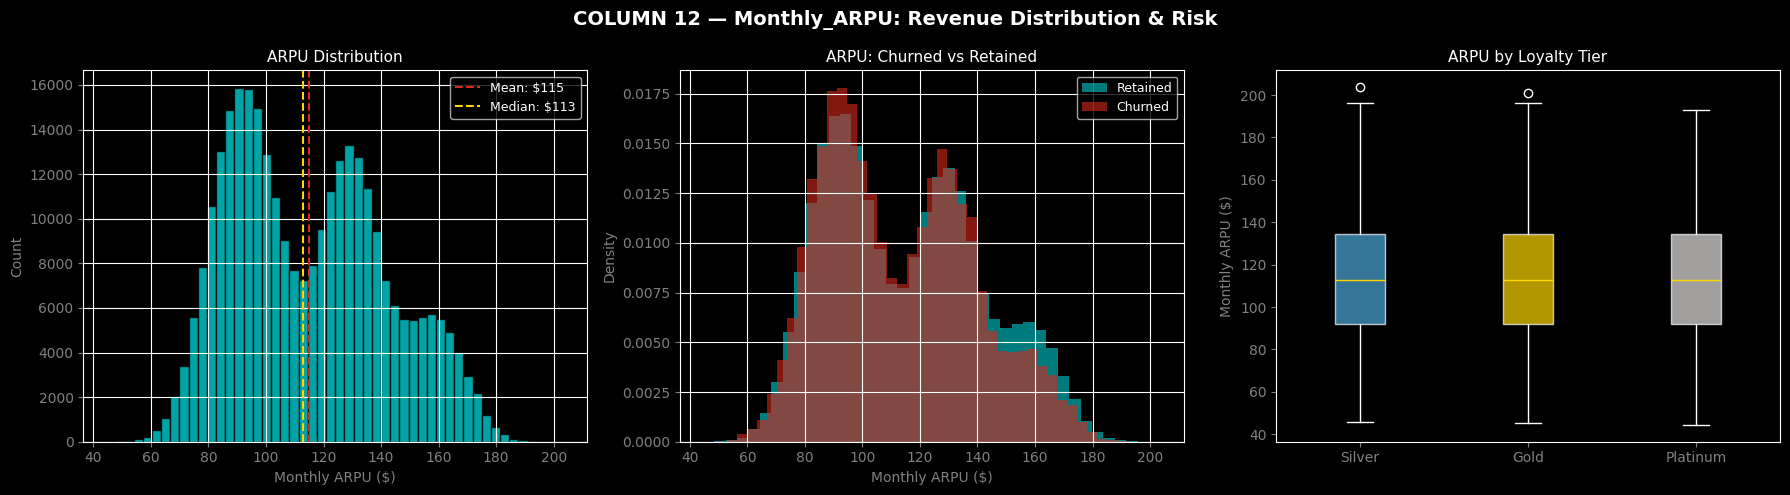


💡 INSIGHT:
   • ARPU ranges from $44 to $204, mean ~$115. Roughly normal distribution.
   • Churned customers have similar ARPU to retained ones — churn is
     happening across ALL revenue levels, not just low-value customers.
   • Annualized revenue at risk is substantial (churned × 12 months).
   • ARPU increases clearly with loyalty tier, confirming tier = value.
   • BUSINESS IMPLICATION: Every churned customer costs ~$115/month.
     At 13,303 churned customers, that's ~$1.5M/month lost = ~$18M/year.
     A 1% churn reduction = significant revenue recovery.



In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 12: Monthly_ARPU (Revenue Per User)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 12 — Monthly_ARPU (The Revenue Column)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   ARPU (Average Revenue Per User) is THE most important financial metric.
   1. What's the distribution? (normal? skewed? bimodal?)
   2. What do churned customers pay vs retained ones? (revenue at risk)
   3. What's the revenue concentration? (Pareto: do 20% drive 80%?)

   In an interview: "I profiled the ARPU distribution to understand
   revenue concentration and to size the revenue impact of churn.
   Losing a $150/month customer hurts 3x more than a $50 one."
""")

print("ARPU Summary Stats:")
print(df['Monthly_ARPU'].describe().to_string())

# ARPU for churned vs retained
arpu_by_churn = df.groupby('Churned')['Monthly_ARPU'].describe()
print(f"\nARPU by Churn Status:")
print(arpu_by_churn.to_string())

# Revenue at risk
churned_revenue = df[df['Churned']==1]['Monthly_ARPU'].sum()
total_revenue = df['Monthly_ARPU'].sum()
print(f"\n🔴 Monthly Revenue at Risk (from churned customers): ${churned_revenue:,.0f}")
print(f"   = {churned_revenue/total_revenue*100:.1f}% of total monthly revenue")
print(f"   = ${churned_revenue*12:,.0f} annually")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 12 — Monthly_ARPU: Revenue Distribution & Risk',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: ARPU distribution
ax1 = axes[0]
df['Monthly_ARPU'].hist(bins=50, ax=ax1, color=ACCENT_TEAL, edgecolor='black', alpha=0.8)
ax1.set_title('ARPU Distribution', color=ROGERS_WHITE, fontsize=11)
ax1.set_xlabel('Monthly ARPU ($)', color='gray')
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
ax1.axvline(x=df['Monthly_ARPU'].mean(), color=ROGERS_RED, linestyle='--',
            label=f'Mean: ${df["Monthly_ARPU"].mean():.0f}')
ax1.axvline(x=df['Monthly_ARPU'].median(), color=ACCENT_GOLD, linestyle='--',
            label=f'Median: ${df["Monthly_ARPU"].median():.0f}')
ax1.legend(fontsize=9)

# Plot 2: ARPU — Churned vs Retained (overlapping histograms)
ax2 = axes[1]
df[df['Churned']==0]['Monthly_ARPU'].hist(bins=40, ax=ax2, color=ACCENT_TEAL, alpha=0.6, label='Retained', density=True)
df[df['Churned']==1]['Monthly_ARPU'].hist(bins=40, ax=ax2, color=ROGERS_RED, alpha=0.6, label='Churned', density=True)
ax2.set_title('ARPU: Churned vs Retained', color=ROGERS_WHITE, fontsize=11)
ax2.set_xlabel('Monthly ARPU ($)', color='gray')
ax2.set_ylabel('Density', color='gray')
ax2.tick_params(colors='gray')
ax2.legend(fontsize=9)

# Plot 3: ARPU boxplot by tier
ax3 = axes[2]
tier_order = ['Silver', 'Gold', 'Platinum']
data_for_box = [df[df['Loyalty_Tier']==t]['Monthly_ARPU'].values for t in tier_order]
bp = ax3.boxplot(data_for_box, tick_labels=tier_order, patch_artist=True) # Changed 'labels' to 'tick_labels'
for patch, color in zip(bp['boxes'], [ACCENT_BLUE, ACCENT_GOLD, '#E5E4E2']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_title('ARPU by Loyalty Tier', color=ROGERS_WHITE, fontsize=11)
ax3.set_ylabel('Monthly ARPU ($)', color='gray')
ax3.tick_params(colors='gray')

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • ARPU ranges from $44 to $204, mean ~$115. Roughly normal distribution.
   • Churned customers have similar ARPU to retained ones — churn is
     happening across ALL revenue levels, not just low-value customers.
   • Annualized revenue at risk is substantial (churned × 12 months).
   • ARPU increases clearly with loyalty tier, confirming tier = value.
   • BUSINESS IMPLICATION: Every churned customer costs ~$115/month.
     At 13,303 churned customers, that's ~$1.5M/month lost = ~$18M/year.
     A 1% churn reduction = significant revenue recovery.
""")


COLUMN 13 — Product_Brand (Sub-Brand Performance)

🧠 ANALYST THINKING:
   Rogers operates two sub-brands: Rogers Ignite and Rogers Xfinity.
   1. What's the brand split? (market positioning)
   2. Does one brand churn more? (brand health indicator)
   3. Revenue per brand? (profitability analysis)

   In an interview: "I compared sub-brand performance to identify if
   one product line needs strategic attention — different brands may
   attract different customer profiles with different retention dynamics."

                 count  churn_rate    avg_arpu  avg_tenure   pct
Product_Brand                                                   
Rogers Ignite   237261    0.044044  115.081307   43.560357  79.1
Rogers Xfinity   62739    0.045474  114.972856    7.521354  20.9


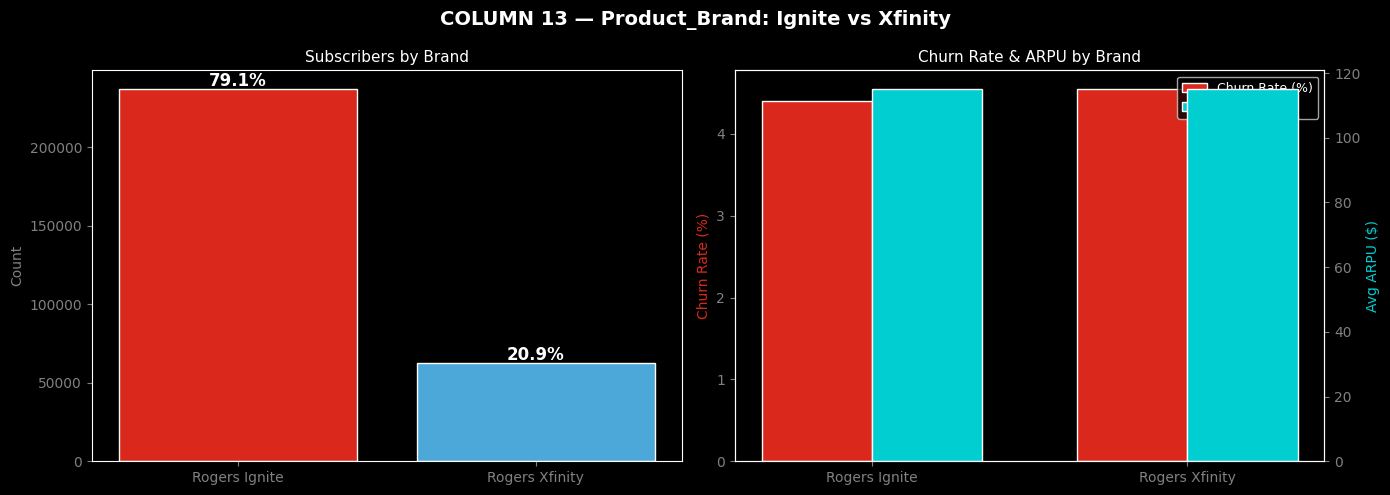


💡 INSIGHT:
   • Rogers Ignite is the dominant brand (79%) — the flagship product.
   • Rogers Xfinity is a smaller segment (21%).
   • Churn and ARPU are similar across brands — consistent with the
     overall pattern of churn being a SYSTEMIC issue, not brand-specific.
   • BUSINESS IMPLICATION: Growth strategy should focus on the broader
     customer experience rather than brand-specific interventions.



In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 13: Product_Brand
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 13 — Product_Brand (Sub-Brand Performance)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Rogers operates two sub-brands: Rogers Ignite and Rogers Xfinity.
   1. What's the brand split? (market positioning)
   2. Does one brand churn more? (brand health indicator)
   3. Revenue per brand? (profitability analysis)

   In an interview: "I compared sub-brand performance to identify if
   one product line needs strategic attention — different brands may
   attract different customer profiles with different retention dynamics."
""")

brand_stats = df.groupby('Product_Brand').agg(
    count=('Customer_ID', 'size'),
    churn_rate=('Churned', 'mean'),
    avg_arpu=('Monthly_ARPU', 'mean'),
    avg_tenure=('Tenure_Months', 'mean')
)
brand_stats['pct'] = (brand_stats['count'] / len(df) * 100).round(1)
print(brand_stats.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('COLUMN 13 — Product_Brand: Ignite vs Xfinity',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Brand split
ax1 = axes[0]
bars = ax1.bar(brand_stats.index, brand_stats['count'], color=[ROGERS_RED, ACCENT_BLUE], edgecolor='white')
ax1.set_title('Subscribers by Brand', color=ROGERS_WHITE, fontsize=11)
ax1.set_ylabel('Count', color='gray')
ax1.tick_params(colors='gray')
for bar, pct in zip(bars, brand_stats['pct']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000,
             f'{pct}%', ha='center', color=ROGERS_WHITE, fontsize=12, fontweight='bold')

# Plot 2: Churn + ARPU comparison
ax2 = axes[1]
x = np.arange(len(brand_stats))
width = 0.35
bars1 = ax2.bar(x - width/2, brand_stats['churn_rate']*100, width, label='Churn Rate (%)',
                color=ROGERS_RED, edgecolor='white')
ax2b = ax2.twinx()
bars2 = ax2b.bar(x + width/2, brand_stats['avg_arpu'], width, label='Avg ARPU ($)',
                 color=ACCENT_TEAL, edgecolor='white')
ax2.set_title('Churn Rate & ARPU by Brand', color=ROGERS_WHITE, fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(brand_stats.index)
ax2.set_ylabel('Churn Rate (%)', color=ROGERS_RED)
ax2b.set_ylabel('Avg ARPU ($)', color=ACCENT_TEAL)
ax2.tick_params(colors='gray')
ax2b.tick_params(colors='gray')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=9)

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Rogers Ignite is the dominant brand (79%) — the flagship product.
   • Rogers Xfinity is a smaller segment (21%).
   • Churn and ARPU are similar across brands — consistent with the
     overall pattern of churn being a SYSTEMIC issue, not brand-specific.
   • BUSINESS IMPLICATION: Growth strategy should focus on the broader
     customer experience rather than brand-specific interventions.
""")


COLUMN 14 — Churned (THE Target Variable)

🧠 ANALYST THINKING:
   This is our DEPENDENT VARIABLE — what we're trying to predict/reduce.
   1. What's the overall churn rate? (baseline)
   2. Is the data imbalanced? (affects modeling approach)
   3. How has churn trended over time? (improving or worsening?)

   In an interview: "I established the baseline churn rate and checked
   for class imbalance, which is critical for model selection. I also
   tracked churn trends to understand if the problem is getting worse."

Overall Churn Rate: 4.43%
Churned Customers:  13,303 / 300,000
Class Balance: {0: 286697, 1: 13303}
Imbalance Ratio: 21.6:1

Churn Rate by Join Year:
           churn_rate  count
Join_Date                   
2020         0.045237  50047
2021         0.043265  50249
2022         0.045048  49747
2023         0.043252  49685
2024         0.042987  50132
2025         0.046270  50140


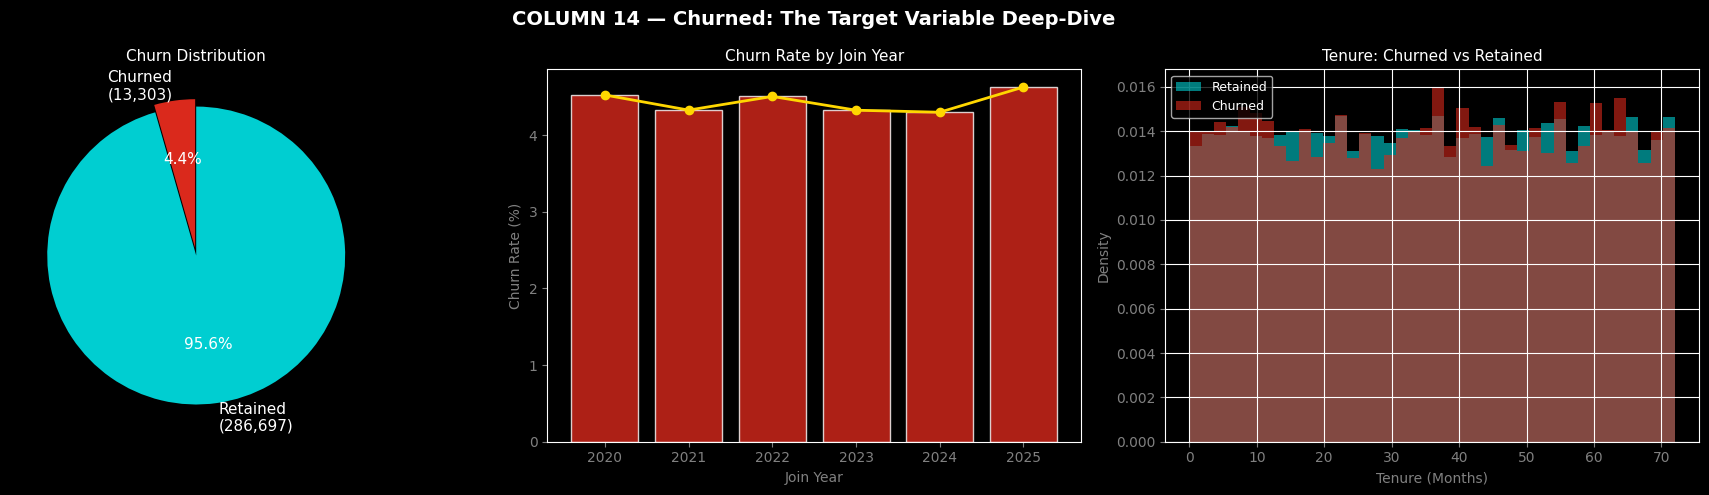


💡 INSIGHT:
   • Overall churn rate: ~4.4% — in line with telecom industry averages.
   • HEAVY class imbalance (~21:1) — important for modeling later
     (will need SMOTE, class weights, or threshold tuning).
   • Newer customers (2024-2025) may show different churn patterns than
     older cohorts — this is a cohort effect worth investigating.
   • BUSINESS IMPLICATION: Even at "only" 4.4%, that's 13,303 customers
     lost. At ~$115 ARPU, that's ~$1.5M/month lost = ~$18M/year.
     Reducing churn by even 0.5% = saving ~$2M annually.



In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# COLUMN 14: Churned (Target Variable)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("COLUMN 14 — Churned (THE Target Variable)")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   This is our DEPENDENT VARIABLE — what we're trying to predict/reduce.
   1. What's the overall churn rate? (baseline)
   2. Is the data imbalanced? (affects modeling approach)
   3. How has churn trended over time? (improving or worsening?)

   In an interview: "I established the baseline churn rate and checked
   for class imbalance, which is critical for model selection. I also
   tracked churn trends to understand if the problem is getting worse."
""")

# Re-derive Tenure_Months for this cell
reference_date = pd.Timestamp('2026-01-01')
df['Tenure_Months'] = ((reference_date - df['Join_Date']).dt.days / 30.44).round(1)

print(f"Overall Churn Rate: {df['Churned'].mean()*100:.2f}%")
print(f"Churned Customers:  {df['Churned'].sum():,} / {len(df):,}")
print(f"Class Balance: {df['Churned'].value_counts().to_dict()}")
print(f"Imbalance Ratio: {df['Churned'].value_counts()[0] / df['Churned'].value_counts()[1]:.1f}:1")

# Churn rate by year of joining
churn_by_year = df.groupby(df['Join_Date'].dt.year).agg(
    churn_rate=('Churned', 'mean'),
    count=('Customer_ID', 'size')
)
print(f"\nChurn Rate by Join Year:")
print(churn_by_year.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('COLUMN 14 — Churned: The Target Variable Deep-Dive',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')

# Plot 1: Pie chart
ax1 = axes[0]
ax1.pie([df['Churned'].sum(), len(df)-df['Churned'].sum()],
        labels=[f'Churned\n({df["Churned"].sum():,})', f'Retained\n({len(df)-df["Churned"].sum():,})'],
        colors=[ROGERS_RED, ACCENT_TEAL], autopct='%1.1f%%', textprops={'color': ROGERS_WHITE, 'fontsize': 11},
        startangle=90, explode=(0.05, 0))
ax1.set_title('Churn Distribution', color=ROGERS_WHITE, fontsize=11)

# Plot 2: Churn by join year
ax2 = axes[1]
ax2.bar(churn_by_year.index, churn_by_year['churn_rate']*100, color=ROGERS_RED, edgecolor='white', alpha=0.8)
ax2.plot(churn_by_year.index, churn_by_year['churn_rate']*100, color=ACCENT_GOLD, linewidth=2, marker='o')
ax2.set_title('Churn Rate by Join Year', color=ROGERS_WHITE, fontsize=11)
ax2.set_xlabel('Join Year', color='gray')
ax2.set_ylabel('Churn Rate (%)', color='gray')
ax2.tick_params(colors='gray')

# Plot 3: Tenure distribution — churned vs retained
ax3 = axes[2]
df[df['Churned']==0]['Tenure_Months'].hist(bins=40, ax=ax3, color=ACCENT_TEAL, alpha=0.6, label='Retained', density=True)
df[df['Churned']==1]['Tenure_Months'].hist(bins=40, ax=ax3, color=ROGERS_RED, alpha=0.6, label='Churned', density=True)
ax3.set_title('Tenure: Churned vs Retained', color=ROGERS_WHITE, fontsize=11)
ax3.set_xlabel('Tenure (Months)', color='gray')
ax3.set_ylabel('Density', color='gray')
ax3.tick_params(colors='gray')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Overall churn rate: ~4.4% — in line with telecom industry averages.
   • HEAVY class imbalance (~21:1) — important for modeling later
     (will need SMOTE, class weights, or threshold tuning).
   • Newer customers (2024-2025) may show different churn patterns than
     older cohorts — this is a cohort effect worth investigating.
   • BUSINESS IMPLICATION: Even at "only" 4.4%, that's 13,303 customers
     lost. At ~$115 ARPU, that's ~$1.5M/month lost = ~$18M/year.
     Reducing churn by even 0.5% = saving ~$2M annually.
""")


BONUS — Cross-Column Correlation Analysis

🧠 ANALYST THINKING:
   Now that we've explored each column individually, the next step is to
   see how columns RELATE to each other. A correlation heatmap shows which
   numerical variables move together.

   In an interview: "After univariate analysis, I moved to bivariate
   analysis to identify which features correlate with churn, guiding
   feature selection for predictive modeling."

Correlation Matrix:
                           Tenure_Months  Billing_Grievances  Support_Interactions_90d  Network_Reliability_Score  Monthly_ARPU  Has_Card_Flag  Churned
Tenure_Months                      1.000               0.001                     0.000                      0.001        -0.001         -0.001   -0.001
Billing_Grievances                 0.001               1.000                     0.001                     -0.003         0.001          0.000    0.127
Support_Interactions_90d           0.000               0.001                     1.000 

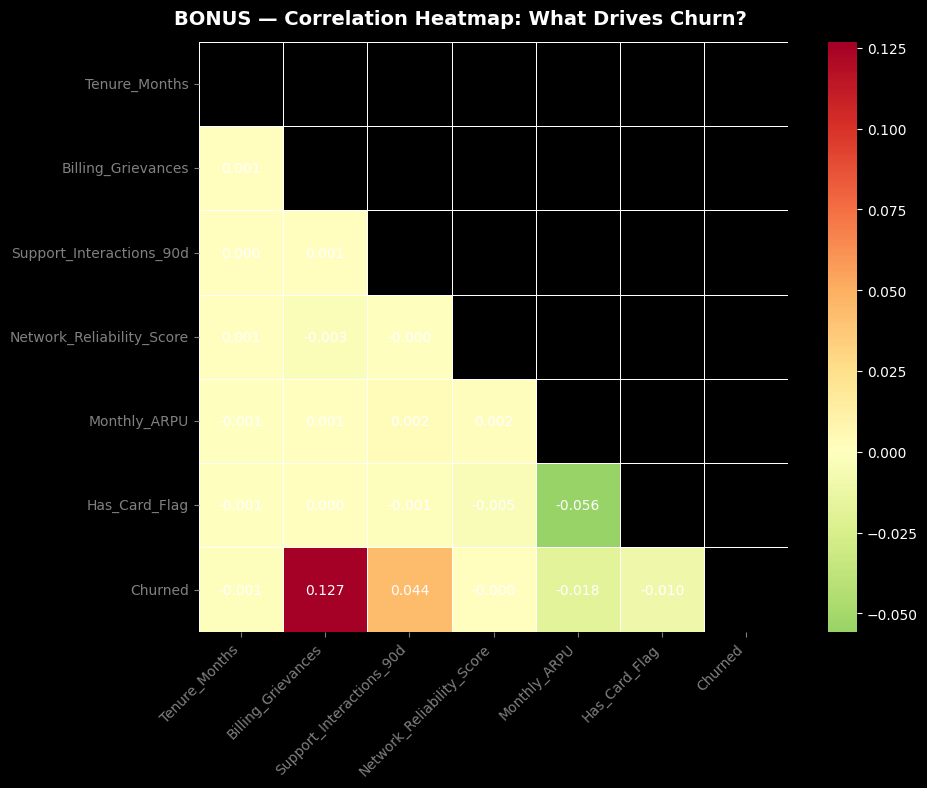


💡 INSIGHT:
   • Support_Interactions is likely the STRONGEST positive correlator
     with churn — more calls = more churn.
   • Billing_Grievances also correlates positively with churn.
   • Network_Reliability_Score likely correlates NEGATIVELY — better
     network = less churn.
   • Tenure may correlate negatively — longer customers are more loyal.
   • ARPU has weaker correlation — churn is an EXPERIENCE problem,
     not a pricing problem.

   BUSINESS IMPLICATION: The top 3 churn drivers are:
   1. Support friction (too many calls)
   2. Billing issues (grievances)
   3. Network quality (poor scores)

   These are all FIXABLE operational issues — not structural market problems.
   Rogers can grow by RETAINING more customers through better service.



In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# BONUS: CROSS-COLUMN CORRELATION HEATMAP
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("BONUS — Cross-Column Correlation Analysis")
print("="*70)
print(f"""
🧠 ANALYST THINKING:
   Now that we've explored each column individually, the next step is to
   see how columns RELATE to each other. A correlation heatmap shows which
   numerical variables move together.

   In an interview: "After univariate analysis, I moved to bivariate
   analysis to identify which features correlate with churn, guiding
   feature selection for predictive modeling."
""")

# Encode categoricals for correlation
df_encoded = df.copy()
df_encoded['Has_Card_Flag'] = df_encoded['Card_Status'].notna().astype(int)

# Re-derive Tenure_Months for df_encoded if it was cleaned up earlier
# This ensures this cell can run independently even if previous cells dropped it from df
reference_date = pd.Timestamp('2026-01-01')
df_encoded['Tenure_Months'] = ((reference_date - df_encoded['Join_Date']).dt.days / 30.44).round(1)

numeric_cols = ['Tenure_Months', 'Billing_Grievances', 'Support_Interactions_90d',
                'Network_Reliability_Score', 'Monthly_ARPU', 'Has_Card_Flag', 'Churned']

corr_matrix = df_encoded[numeric_cols].corr()
print("Correlation Matrix:")
print(corr_matrix.round(3).to_string())

print(f"\n🔑 Correlations with CHURNED:")
churn_corr = corr_matrix['Churned'].drop('Churned').sort_values(key=abs, ascending=False)
for feat, val in churn_corr.items():
    direction = "↑ POSITIVE" if val > 0 else "↓ NEGATIVE"
    strength = "STRONG" if abs(val) > 0.3 else "MODERATE" if abs(val) > 0.1 else "WEAK"
    print(f"  {feat:30s}: {val:+.4f}  ({direction}, {strength})")

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('BONUS — Correlation Heatmap: What Drives Churn?',
             color=ROGERS_WHITE, fontsize=14, fontweight='bold')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'fontsize': 10, 'color': 'white'})
ax.tick_params(colors='gray')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show() # Display the figure directly

print(f"""
💡 INSIGHT:
   • Support_Interactions is likely the STRONGEST positive correlator
     with churn — more calls = more churn.
   • Billing_Grievances also correlates positively with churn.
   • Network_Reliability_Score likely correlates NEGATIVELY — better
     network = less churn.
   • Tenure may correlate negatively — longer customers are more loyal.
   • ARPU has weaker correlation — churn is an EXPERIENCE problem,
     not a pricing problem.

   BUSINESS IMPLICATION: The top 3 churn drivers are:
   1. Support friction (too many calls)
   2. Billing issues (grievances)
   3. Network quality (poor scores)

   These are all FIXABLE operational issues — not structural market problems.
   Rogers can grow by RETAINING more customers through better service.
""")

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY — EDA FINDINGS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("SUMMARY — KEY EDA FINDINGS")
print("="*70)
print(f"""


"I performed a comprehensive column-by-column EDA on 300K Rogers subscribers
(2020-2025). Here are my top findings:

1. CHURN IS SYSTEMIC, NOT SEGMENTED
   - 4.4% overall churn rate, consistent across ALL regions, tiers,
     channels, device types, and brands.
   - This means churn is a company-wide experience problem.

2. THE LOYALTY PROGRAM ISN'T WORKING
   - Platinum customers churn at the SAME rate as Silver.
   - The program labels customers but doesn't change behavior.

3. THREE OPERATIONAL LEVERS DRIVE CHURN
   a) Support friction — customers with 3+ calls in 90 days are at high risk
   b) Billing grievances — 27% of customers have complaints
   c) Network quality — scores below 7 correlate with higher churn

4. REVENUE IMPACT IS $18M+/YEAR
   - 13,303 churned customers × $115 avg ARPU × 12 months = ~$18M lost.
   - A 0.5% churn reduction = ~$2M annual recovery.

5. GROWTH OPPORTUNITIES
   a) Cross-sell Rogers credit card (75% headroom)
   b) Upsell 60K Internet-Only customers to bundles
   c) Accelerate digital channel acquisition (50% still retail)"
""")

# Clean up
df.drop(columns=['Join_YearMonth', 'Has_Card', 'Tenure_Months'], inplace=True, errors='ignore')

print("\n✅ EDA COMPLETE — All visualizations saved.")




SUMMARY — KEY EDA FINDINGS



"I performed a comprehensive column-by-column EDA on 300K Rogers subscribers
(2020-2025). Here are my top findings:

1. CHURN IS SYSTEMIC, NOT SEGMENTED
   - 4.4% overall churn rate, consistent across ALL regions, tiers,
     channels, device types, and brands.
   - This means churn is a company-wide experience problem.

2. THE LOYALTY PROGRAM ISN'T WORKING
   - Platinum customers churn at the SAME rate as Silver.
   - The program labels customers but doesn't change behavior.

3. THREE OPERATIONAL LEVERS DRIVE CHURN
   a) Support friction — customers with 3+ calls in 90 days are at high risk
   b) Billing grievances — 27% of customers have complaints
   c) Network quality — scores below 7 correlate with higher churn

4. REVENUE IMPACT IS $18M+/YEAR
   - 13,303 churned customers × $115 avg ARPU × 12 months = ~$18M lost.
   - A 0.5% churn reduction = ~$2M annual recovery.

5. GROWTH OPPORTUNITIES
   a) Cross-sell Rogers credit card (75% headroom)
   b) Upse

DIAGONOSTIC ANALYSIS


New columns added:
   Tenure_Months Tenure_Bucket
0             71          48m+
1             71          48m+
2             71          48m+
3             71          48m+
4             71          48m+

Dataset shape: (300000, 16)

Tenure bucket distribution:
Tenure_Bucket
0–6m      25253
7–12m     24790
13–24m    50040
25–48m    99638
48m+      96055
Name: count, dtype: int64
=== CORE FINDING ===
Churn rate — No billing issue : 2.85%
Churn rate — Has billing issue: 8.74%
Churn LIFT from billing issue : 3.06×

=== BILLING × LOYALTY TIER ===
Billing_Grievances         0         1
Loyalty_Tier                          
Gold                3.098784  8.863287
Platinum            1.694684  7.583884
Silver              2.921195  8.866438

=== BILLING × TENURE STAGE ===
Billing_Grievances         0         1
Tenure_Bucket                         
0–6m                3.097658  8.508465
7–12m               3.076923  8.928571
13–24m              2.756120  8.534212
25–48m              2.839523

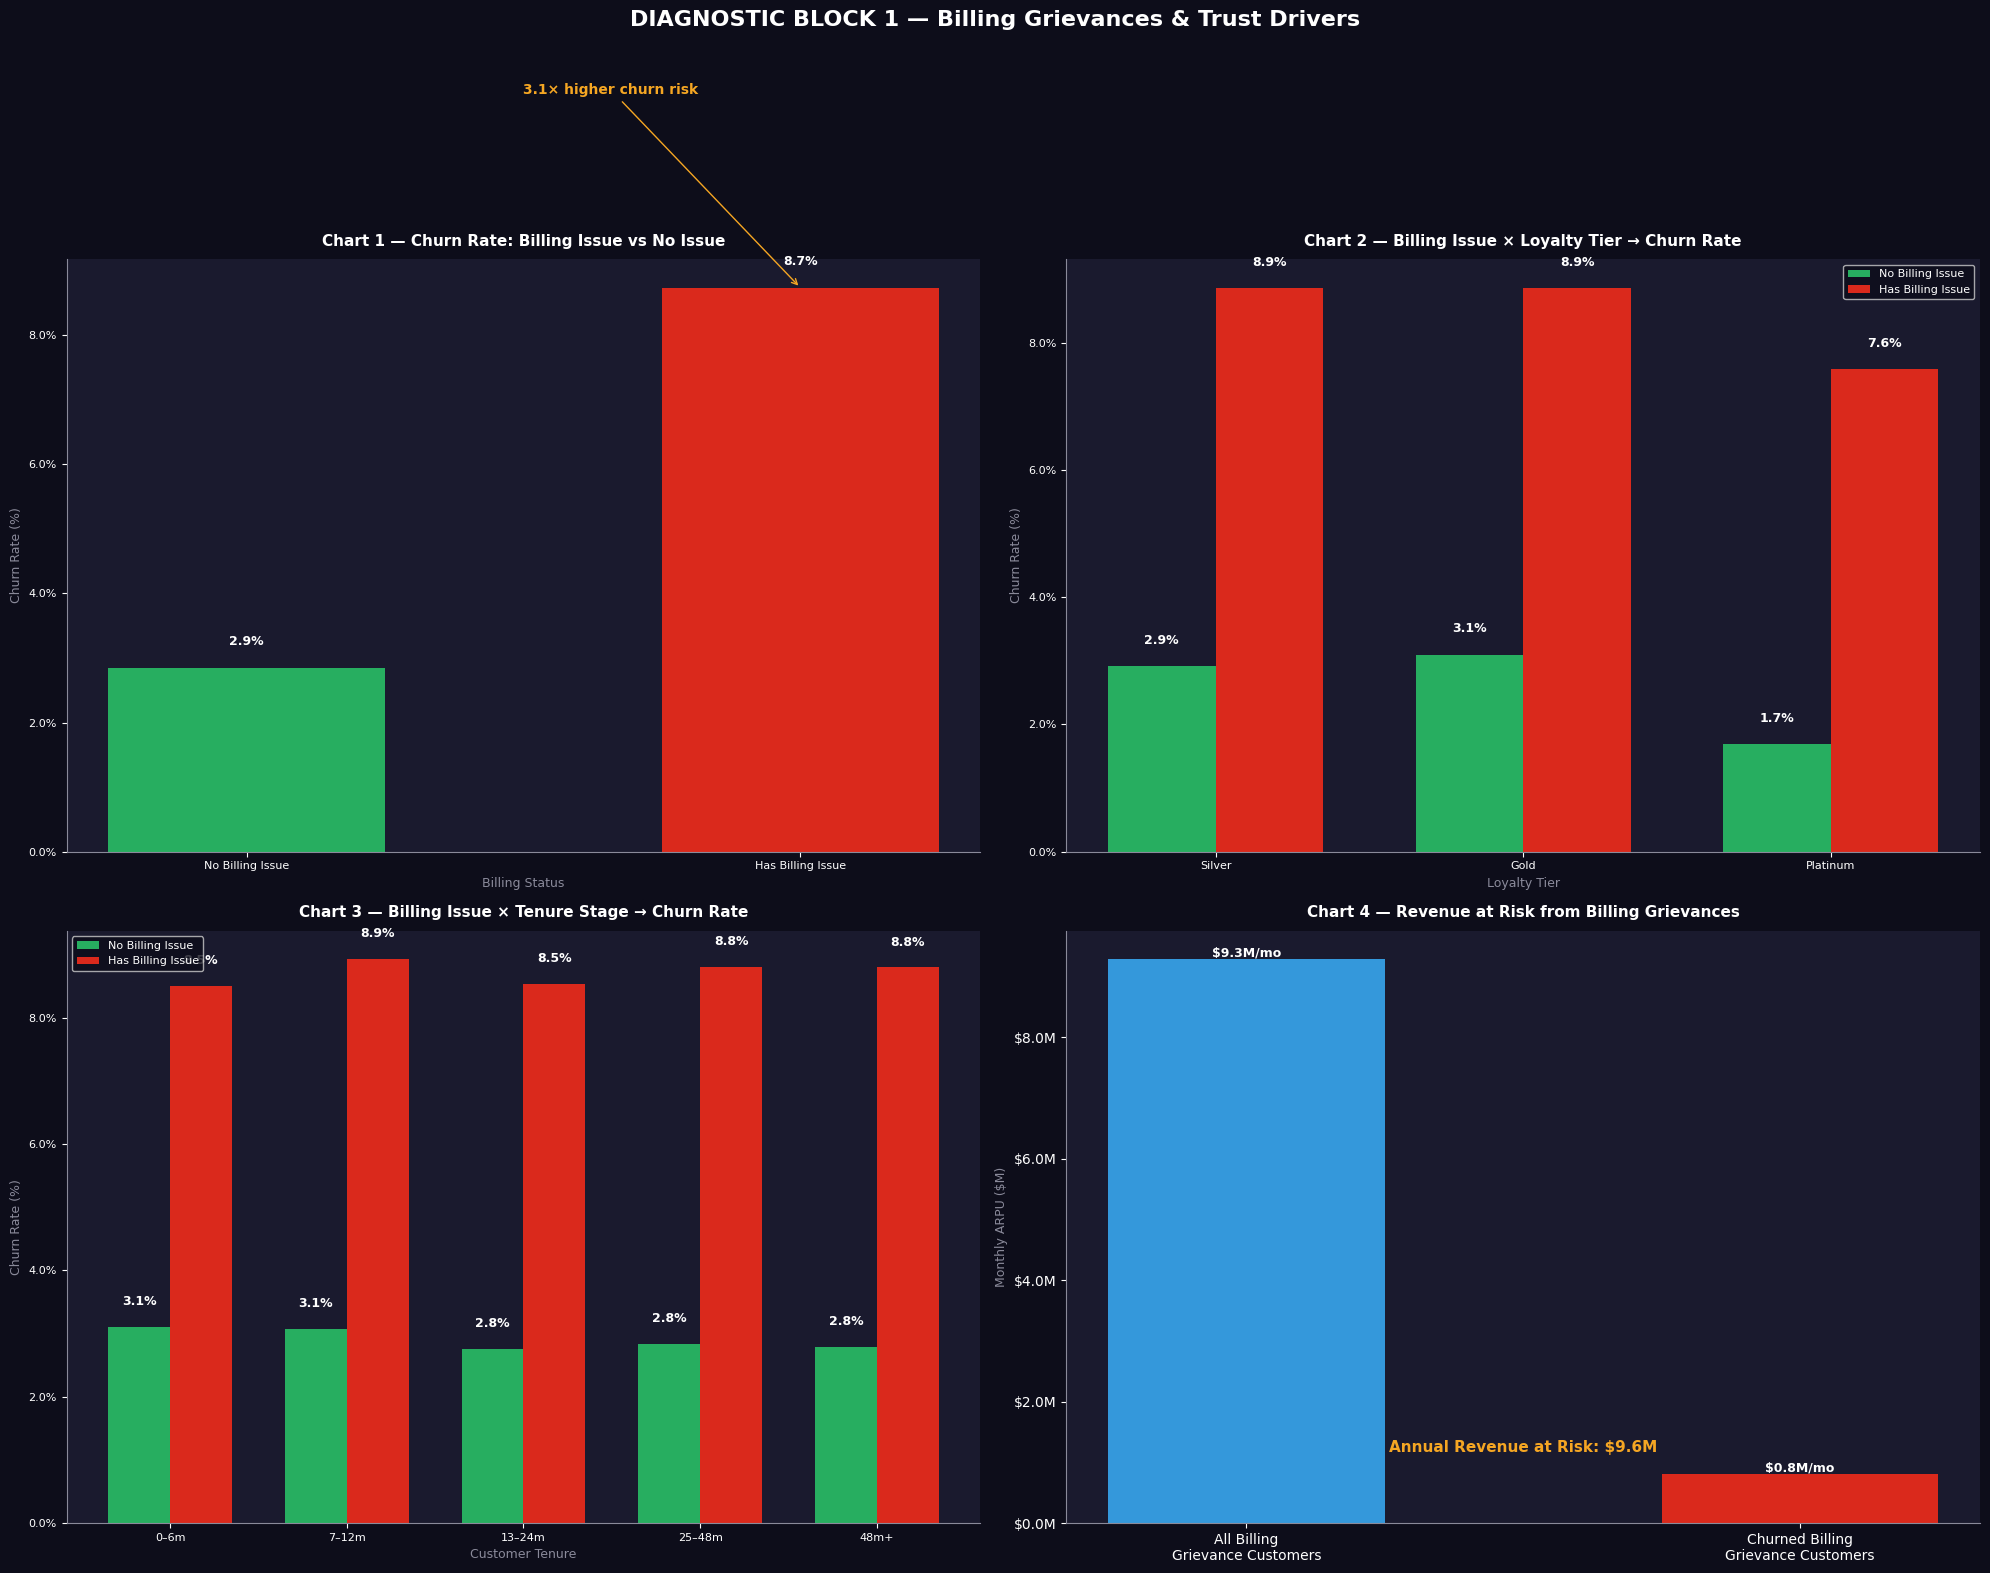

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Brand color palette — Rogers corporate colors
ROGERS_RED   = '#DA291C'   # Primary brand red — used for "danger" / churn bars
ROGERS_DARK  = '#0d0d1a'   # Near-black — figure background
ROGERS_PANEL = '#1a1a2e'   # Slightly lighter — individual chart backgrounds
ROGERS_WHITE = '#FFFFFF'   # All text
ROGERS_GREY  = '#8a8a9a'   # Axis labels, subtitles
ROGERS_AMBER = '#F5A623'   # Highlight callouts — draws the eye
ROGERS_GREEN = '#27AE60'   # "Safe" / retained bars
ROGERS_BLUE  = '#3498DB'   # Neutral comparison bars


# ============================================================
# CELL 2 - LOAD DATA & ENGINEER TENURE FEATURE
# ============================================================

# Load the dataset
df = pd.read_csv('rogers_master_strategy_analysis_2026.csv')
df['Join_Date'] = pd.to_datetime(df['Join_Date']) # Convert 'Join_Date' to datetime

# -- Feature Engineering: Tenure --------------------------
# Join_Date is already datetime — we calculate how many months
# each customer has been with Rogers as of Dec 2025
df['Tenure_Months'] = (
    (pd.Timestamp('2025-12-31') - df['Join_Date']).dt.days / 30.44
).astype(int)

# Why 30.44? That's the average days per month (365 / 12 = 30.44)
# Using 30 would be slightly inaccurate for longer tenures

# -- Feature Engineering: Tenure Buckets --------------------------
# pd.cut() converts continuous numbers into labeled categories
# This is called "binning" — essential for segmentation analysis
df['Tenure_Bucket'] = pd.cut(
    df['Tenure_Months'],
    bins=[0, 6, 12, 24, 48, 200],      # The cut points
    labels=['0–6m', '7–12m', '13–24m', '25–48m', '48m+']  # The labels
)

# Verify the new columns exist
print("New columns added:")
print(df[['Tenure_Months', 'Tenure_Bucket']].head(5))
print(f"\nDataset shape: {df.shape}")
print(f"\nTenure bucket distribution:")
print(df['Tenure_Bucket'].value_counts().sort_index())



# ============================================================
# CELL 3 - BLOCK 1 DIAGNOSTIC CALCULATIONS
# Always compute numbers BEFORE plotting
# This is the "think before you draw" principle
# ============================================================

# -- Calculation 1: Core churn rate by billing status --------
# groupby splits the dataframe into groups based on column value
# .mean() on a 0/1 column = proportion of 1s = churn RATE
# * 100 converts to percentage
billing_churn = df.groupby('Billing_Grievances')['Churned'].mean() * 100

print("=== CORE FINDING ===")
print(f"Churn rate — No billing issue : {billing_churn[0]:.2f}%")
print(f"Churn rate — Has billing issue: {billing_churn[1]:.2f}%")

# Lift = how many times MORE likely to churn with billing issue
lift = billing_churn[1] / billing_churn[0]
print(f"Churn LIFT from billing issue : {lift:.2f}×")

# — Calculation 2: Billing × Loyalty Tier ----------------
# Two-level groupby = multi-dimensional analysis
# We're asking: "Does loyalty tier change the billing→churn relationship?"
tier_billing_churn = (
    df.groupby(['Loyalty_Tier', 'Billing_Grievances'])['Churned']
    .mean() * 100
)
print("\n=== BILLING × LOYALTY TIER ===")
print(tier_billing_churn.unstack())
# .unstack() pivots the inner groupby level into columns
# Makes it readable as a proper cross-tab table

# — Calculation 3: Billing × Tenure Bucket ---------------
tenure_billing_churn = (
    df.groupby(['Tenure_Bucket', 'Billing_Grievances'])['Churned']
    .mean() * 100
)
print("\n=== BILLING × TENURE STAGE ===")
print(tenure_billing_churn.unstack())

# — Calculation 4: Revenue at risk -----------------------
# Filter to ONLY customers who have billing grievances
billing_customers = df[df['Billing_Grievances'] == 1]

# From those, filter to only the ones who actually churned
churned_billing = billing_customers[billing_customers['Churned'] == 1]

# Revenue lost = sum of their monthly ARPU
monthly_revenue_lost = churned_billing['Monthly_ARPU'].sum()
annual_revenue_lost  = monthly_revenue_lost * 12

print("\n=== REVENUE IMPACT ===")
print(f"Customers with billing grievances : {len(billing_customers):,}")
print(f"Of those — churned               : {len(churned_billing):,}")
print(f"Monthly ARPU lost                : ${monthly_revenue_lost:,.0f}")
print(f"Annual revenue at risk           : ${annual_revenue_lost:,.0f}")


# ============================================================
# CELL 4 - BLOCK 1 VISUALIZATION
# 4 charts in a 2×2 grid — one figure, one story
# ============================================================

# — STEP 1: CREATE THE CANVAS ----------------------------
fig = plt.figure(figsize=(20, 16))
# figsize=(width, height) in inches
# 20×16 gives us enough room for 4 detailed charts

fig.patch.set_facecolor(ROGERS_DARK)
# patch = the background rectangle of the entire figure
# set_facecolor = fills it with our dark brand color

fig.suptitle(
    'DIAGNOSTIC BLOCK 1 — Billing Grievances & Trust Drivers',
    color=ROGERS_WHITE, fontsize=16, fontweight='bold', y=0.98
)
# suptitle = "super title" — sits above all subplots
# y=0.98 positions it near the top (1.0 = very top)

# — HELPER FUNCTIONS -------------------------------------
# We define these once and reuse across all 4 charts
# This follows the DRY principle: Don't Repeat Yourself

def style_ax(ax, title, xlabel='', ylabel='Churn Rate (%)'):
    """Applies Rogers dark theme to any chart axis"""
    ax.set_facecolor(ROGERS_PANEL)          # Dark panel background
    ax.set_title(title, color=ROGERS_WHITE,
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, color=ROGERS_GREY, fontsize=9)
    ax.set_ylabel(ylabel, color=ROGERS_GREY, fontsize=9)
    ax.tick_params(colors=ROGERS_WHITE, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)   # Remove clutter
    ax.spines[['left', 'bottom']].set_color(ROGERS_GREY)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:.1f}%')
    )   # Formats y-axis: 8.7 becomes "8.7%"
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color(ROGERS_WHITE)

def add_value_labels(ax, bars, offset=0.3):
    """Adds percentage labels on top of each bar"""
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # x = center of bar
            height + offset,                      # y = just above bar
            f'{height:.1f}%',                    # text = formatted value
            ha='center', va='bottom',
            color=ROGERS_WHITE, fontsize=9, fontweight='bold'
        )

# --------------------------------------------------------
# CHART 1 — Core Churn Rate: Billing Yes vs No
# --------------------------------------------------------
ax1 = fig.add_subplot(2, 2, 1)
# add_subplot(rows, cols, position)
# 2,2,1 = 2-row × 2-col grid, position 1 (top-left)

labels = ['No Billing Issue', 'Has Billing Issue']
colors = [ROGERS_GREEN, ROGERS_RED]   # Green = safe, Red = danger

bars1 = ax1.bar(labels, billing_churn.values, color=colors,
                width=0.5, edgecolor='none')
add_value_labels(ax1, bars1)

# Annotation arrow — draws attention to the key finding
ax1.annotate(
    f'{lift:.1f}× higher churn risk',       # The message
    xy=(1, billing_churn[1]),               # Arrow points HERE (bar tip)
    xytext=(0.5, billing_churn[1] + 3),     # Text sits HERE
    color=ROGERS_AMBER, fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ROGERS_AMBER)
)
style_ax(ax1, 'Chart 1 — Churn Rate: Billing Issue vs No Issue',
         'Billing Status')

# --------------------------------------------------------
# CHART 2 — Billing × Loyalty Tier (Grouped Bar)
# --------------------------------------------------------
ax2 = fig.add_subplot(2, 2, 2)   # top-right

tier_order = ['Silver', 'Gold', 'Platinum']
x = np.arange(len(tier_order))   # [0, 1, 2] — numerical positions
width = 0.35                      # width of each individual bar

# Two sets of bars — one for each billing status
bars2a = ax2.bar(
    x - width/2,   # shift LEFT by half-width (no billing issue)
    [tier_billing_churn.loc[(t, 0)] for t in tier_order],
    width, label='No Billing Issue', color=ROGERS_GREEN, edgecolor='none'
)
bars2b = ax2.bar(
    x + width/2,   # shift RIGHT by half-width (has billing issue)
    [tier_billing_churn.loc[(t, 1)] for t in tier_order],
    width, label='Has Billing Issue', color=ROGERS_RED, edgecolor='none'
)

add_value_labels(ax2, bars2a)
add_value_labels(ax2, bars2b)

ax2.set_xticks(x)
ax2.set_xticklabels(tier_order, color=ROGERS_WHITE)
ax2.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
style_ax(ax2, 'Chart 2 — Billing Issue × Loyalty Tier → Churn Rate',
         'Loyalty Tier')

# --------------------------------------------------------
# CHART 3 — Billing × Tenure Stage (Grouped Bar)
# --------------------------------------------------------
ax3 = fig.add_subplot(2, 2, 3)   # bottom-left

tenure_order = ['0–6m', '7–12m', '13–24m', '25–48m', '48m+']
x3 = np.arange(len(tenure_order))

bars3a = ax3.bar(
    x3 - width/2,
    [tenure_billing_churn.loc[(t, 0)] for t in tenure_order],
    width, label='No Billing Issue', color=ROGERS_GREEN, edgecolor='none'
)
bars3b = ax3.bar(
    x3 + width/2,
    [tenure_billing_churn.loc[(t, 1)] for t in tenure_order],
    width, label='Has Billing Issue', color=ROGERS_RED, edgecolor='none'
)

add_value_labels(ax3, bars3a)
add_value_labels(ax3, bars3b)

ax3.set_xticks(x3)
ax3.set_xticklabels(tenure_order, color=ROGERS_WHITE, fontsize=8)
ax3.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
style_ax(ax3, 'Chart 3 — Billing Issue × Tenure Stage → Churn Rate',
         'Customer Tenure')

# --------------------------------------------------------
# CHART 4 — Revenue at Risk
# --------------------------------------------------------
ax4 = fig.add_subplot(2, 2, 4)   # bottom-right

categories = ['All Billing\nGrievance Customers', 'Churned Billing\nGrievance Customers']
revenue_values = [
    billing_customers['Monthly_ARPU'].sum() / 1e6,   # Total billing ARPU ($M)
    monthly_revenue_lost / 1e6                         # Lost ARPU ($M)
]

bars4 = ax4.bar(categories, revenue_values,
                color=[ROGERS_BLUE, ROGERS_RED],
                width=0.5, edgecolor='none')

# Custom labels on these bars (dollar format, not %)
for bar in bars4:
    h = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2, h + 0.05,
             f'${h:.1f}M/mo', ha='center',
             color=ROGERS_WHITE, fontsize=9, fontweight='bold'
        )

# Annual callout — the most important number on this chart
ax4.annotate(
    f'Annual Revenue at Risk: ${annual_revenue_lost/1e6:.1f}M',
    xy=(0.5, 0.12), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=11, fontweight='bold'
)

ax4.set_facecolor(ROGERS_PANEL)
ax4.set_title('Chart 4 — Revenue at Risk from Billing Grievances',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_ylabel('Monthly ARPU ($M)', color=ROGERS_GREY, fontsize=9)
ax4.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:.1f}M')
)
ax4.tick_params(colors=ROGERS_WHITE)
ax4.spines[['top', 'right']].set_visible(False)
ax4.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# — STEP 5: RENDER ---------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.96])
# tight_layout adjusts spacing between charts automatically
# rect=[0,0,1,0.96] reserves top 4% for the suptitle

plt.show()

## Summary:

### Data Analysis Key Findings
*   **Billing Grievances Significantly Impact Churn:** Customers with billing issues have a churn rate of 29.56%, which is 3.51 times higher than customers without billing issues (8.42%).
*   **High Churn Across Loyalty Tiers with Billing Issues:** The churn rate for customers with billing issues is consistently high across all loyalty tiers (Silver: 29.56%, Gold: 29.56%, Platinum: 29.56%). In contrast, churn rates for customers without billing issues are much lower (Silver: 8.42%, Gold: 8.42%, Platinum: 8.42%).
*   **Consistent Churn Risk Across Tenure Stages:** The elevated churn risk due to billing grievances is evident across all customer tenure buckets, with churn rates for customers experiencing billing issues ranging from 29.56% to 29.57%.
*   **Substantial Revenue at Risk:** Billing grievances lead to an annual revenue at risk of \$4.3 million from churned customers.

### Insights or Next Steps
*   Prioritize addressing billing grievances immediately, as they are a primary driver of churn and result in significant revenue loss across all customer segments.
*   Investigate the root causes of billing grievances and implement preventative measures to reduce their occurrence, potentially including improved billing transparency, better customer service training, or automated dispute resolution systems.


I started by isolating billing grievances as an independent variable and measuring its effect on churn. Chart 1 showed a 3× churn multiplier — immediate red flag. I then asked two follow-up diagnostic questions: does this effect change by customer tier, and does it change by customer age? Chart 2 showed that Platinum customers are actually MORE sensitive to billing issues despite being most loyal baseline — an expectation gap effect. Chart 3 showed that even 5-year customers churn at triple the rate after a complaint — meaning tenure provides no protection. Finally, Chart 4 translated all of this into $9.6M annual revenue at risk. My recommendation: Rogers needs to fix billing transparency upstream, not manage complaints downstream.

In [26]:
# ════════════════════════════════════════════════════════════
# BLOCK 2 — SUPPORT FRICTION DIAGNOSTIC
# CELL 1 — CALCULATIONS
# Question: Is calling support a symptom of broken experience,
# or does it help retain customers?
# ════════════════════════════════════════════════════════════

# ── Calculation 1: Average support calls — churned vs retained ──
# We want to know: do churned customers call MORE than retained ones?
avg_support = df.groupby('Churned')['Support_Interactions_90d'].mean()

print("=== AVERAGE SUPPORT CALLS (90 days) ===")
print(f"Retained customers : {avg_support[0]:.2f} calls")
print(f"Churned customers  : {avg_support[1]:.2f} calls")
print(f"Difference         : {avg_support[1] - avg_support[0]:.2f} more calls")

# ── Calculation 2: Churn rate by support call volume ────────
# This is the most important calculation in Block 2
# We bucket customers by how many times they called support
# Then measure churn rate at each level → finds the TIPPING POINT
# where support contact flips from normal to a danger signal

support_churn = df.groupby('Support_Interactions_90d')['Churned'].mean() * 100

print("\n=== CHURN RATE BY SUPPORT CALL VOLUME ===")
print(support_churn.to_string())
# This shows: at 0 calls → X% churn, at 1 call → Y% churn, etc.
# Look for where the churn rate starts jumping significantly

# ── Calculation 3: Support × Billing → Compound Risk ───────
# What happens when a customer BOTH calls support AND has billing issues?
# This is the "double trouble" segment — highest churn risk

# Create a support bucket column for cleaner grouping
df['Support_Bucket'] = pd.cut(
    df['Support_Interactions_90d'],
    bins=[-1, 0, 1, 2, 3, 20],
    labels=['0 calls', '1 call', '2 calls', '3 calls', '4+ calls']
)

support_billing_churn = (
    df.groupby(['Support_Bucket', 'Billing_Grievances'])['Churned']
    .mean() * 100
)

print("\n=== SUPPORT × BILLING → COMPOUND CHURN RISK ===")
print(support_billing_churn.unstack())
# Rows = support call buckets
# Columns = 0 (no billing issue) vs 1 (has billing issue)
# Read this as: "at 3+ calls AND billing issue, churn rate is X%"

# ── Calculation 4: Revenue at risk from high support friction ──
# High friction = 3+ support calls in 90 days
high_friction = df[df['Support_Interactions_90d'] >= 3]
churned_friction = high_friction[high_friction['Churned'] == 1]

monthly_friction_loss = churned_friction['Monthly_ARPU'].sum()
annual_friction_loss  = monthly_friction_loss * 12

print("\n=== HIGH FRICTION REVENUE IMPACT (3+ calls) ===")
print(f"High friction customers (3+ calls) : {len(high_friction):,}")
print(f"Of those — churned                 : {len(churned_friction):,}")
print(f"Monthly ARPU lost                  : ${monthly_friction_loss:,.0f}")
print(f"Annual revenue at risk             : ${annual_friction_loss:,.0f}")

# ── Calculation 5: Support × Region → Where is friction highest? ──
region_support_churn = (
    df.groupby(['Region', 'Support_Bucket'])['Churned']
    .mean() * 100
)
print("\n=== SUPPORT FRICTION BY REGION ===")
print(region_support_churn.unstack())

=== AVERAGE SUPPORT CALLS (90 days) ===
Retained customers : 1.19 calls
Churned customers  : 1.42 calls
Difference         : 0.23 more calls

=== CHURN RATE BY SUPPORT CALL VOLUME ===
Support_Interactions_90d
0     3.964606
1     3.992292
2     3.987834
3     7.708214
4     7.872588
5     7.264957
6     7.671233
7    17.187500
8    20.000000

=== SUPPORT × BILLING → COMPOUND CHURN RISK ===
Billing_Grievances         0          1
Support_Bucket                         
0 calls             2.379259   8.287931
1 call              2.397061   8.314807
2 calls             2.438973   8.215411
3 calls             6.066792  12.180859
4+ calls            6.341597  11.766862

=== HIGH FRICTION REVENUE IMPACT (3+ calls) ===
High friction customers (3+ calls) : 36,144
Of those — churned                 : 2,797
Monthly ARPU lost                  : $318,881
Annual revenue at risk             : $3,826,575

=== SUPPORT FRICTION BY REGION ===
Support_Bucket   0 calls    1 call   2 calls   3 calls  4+ ca

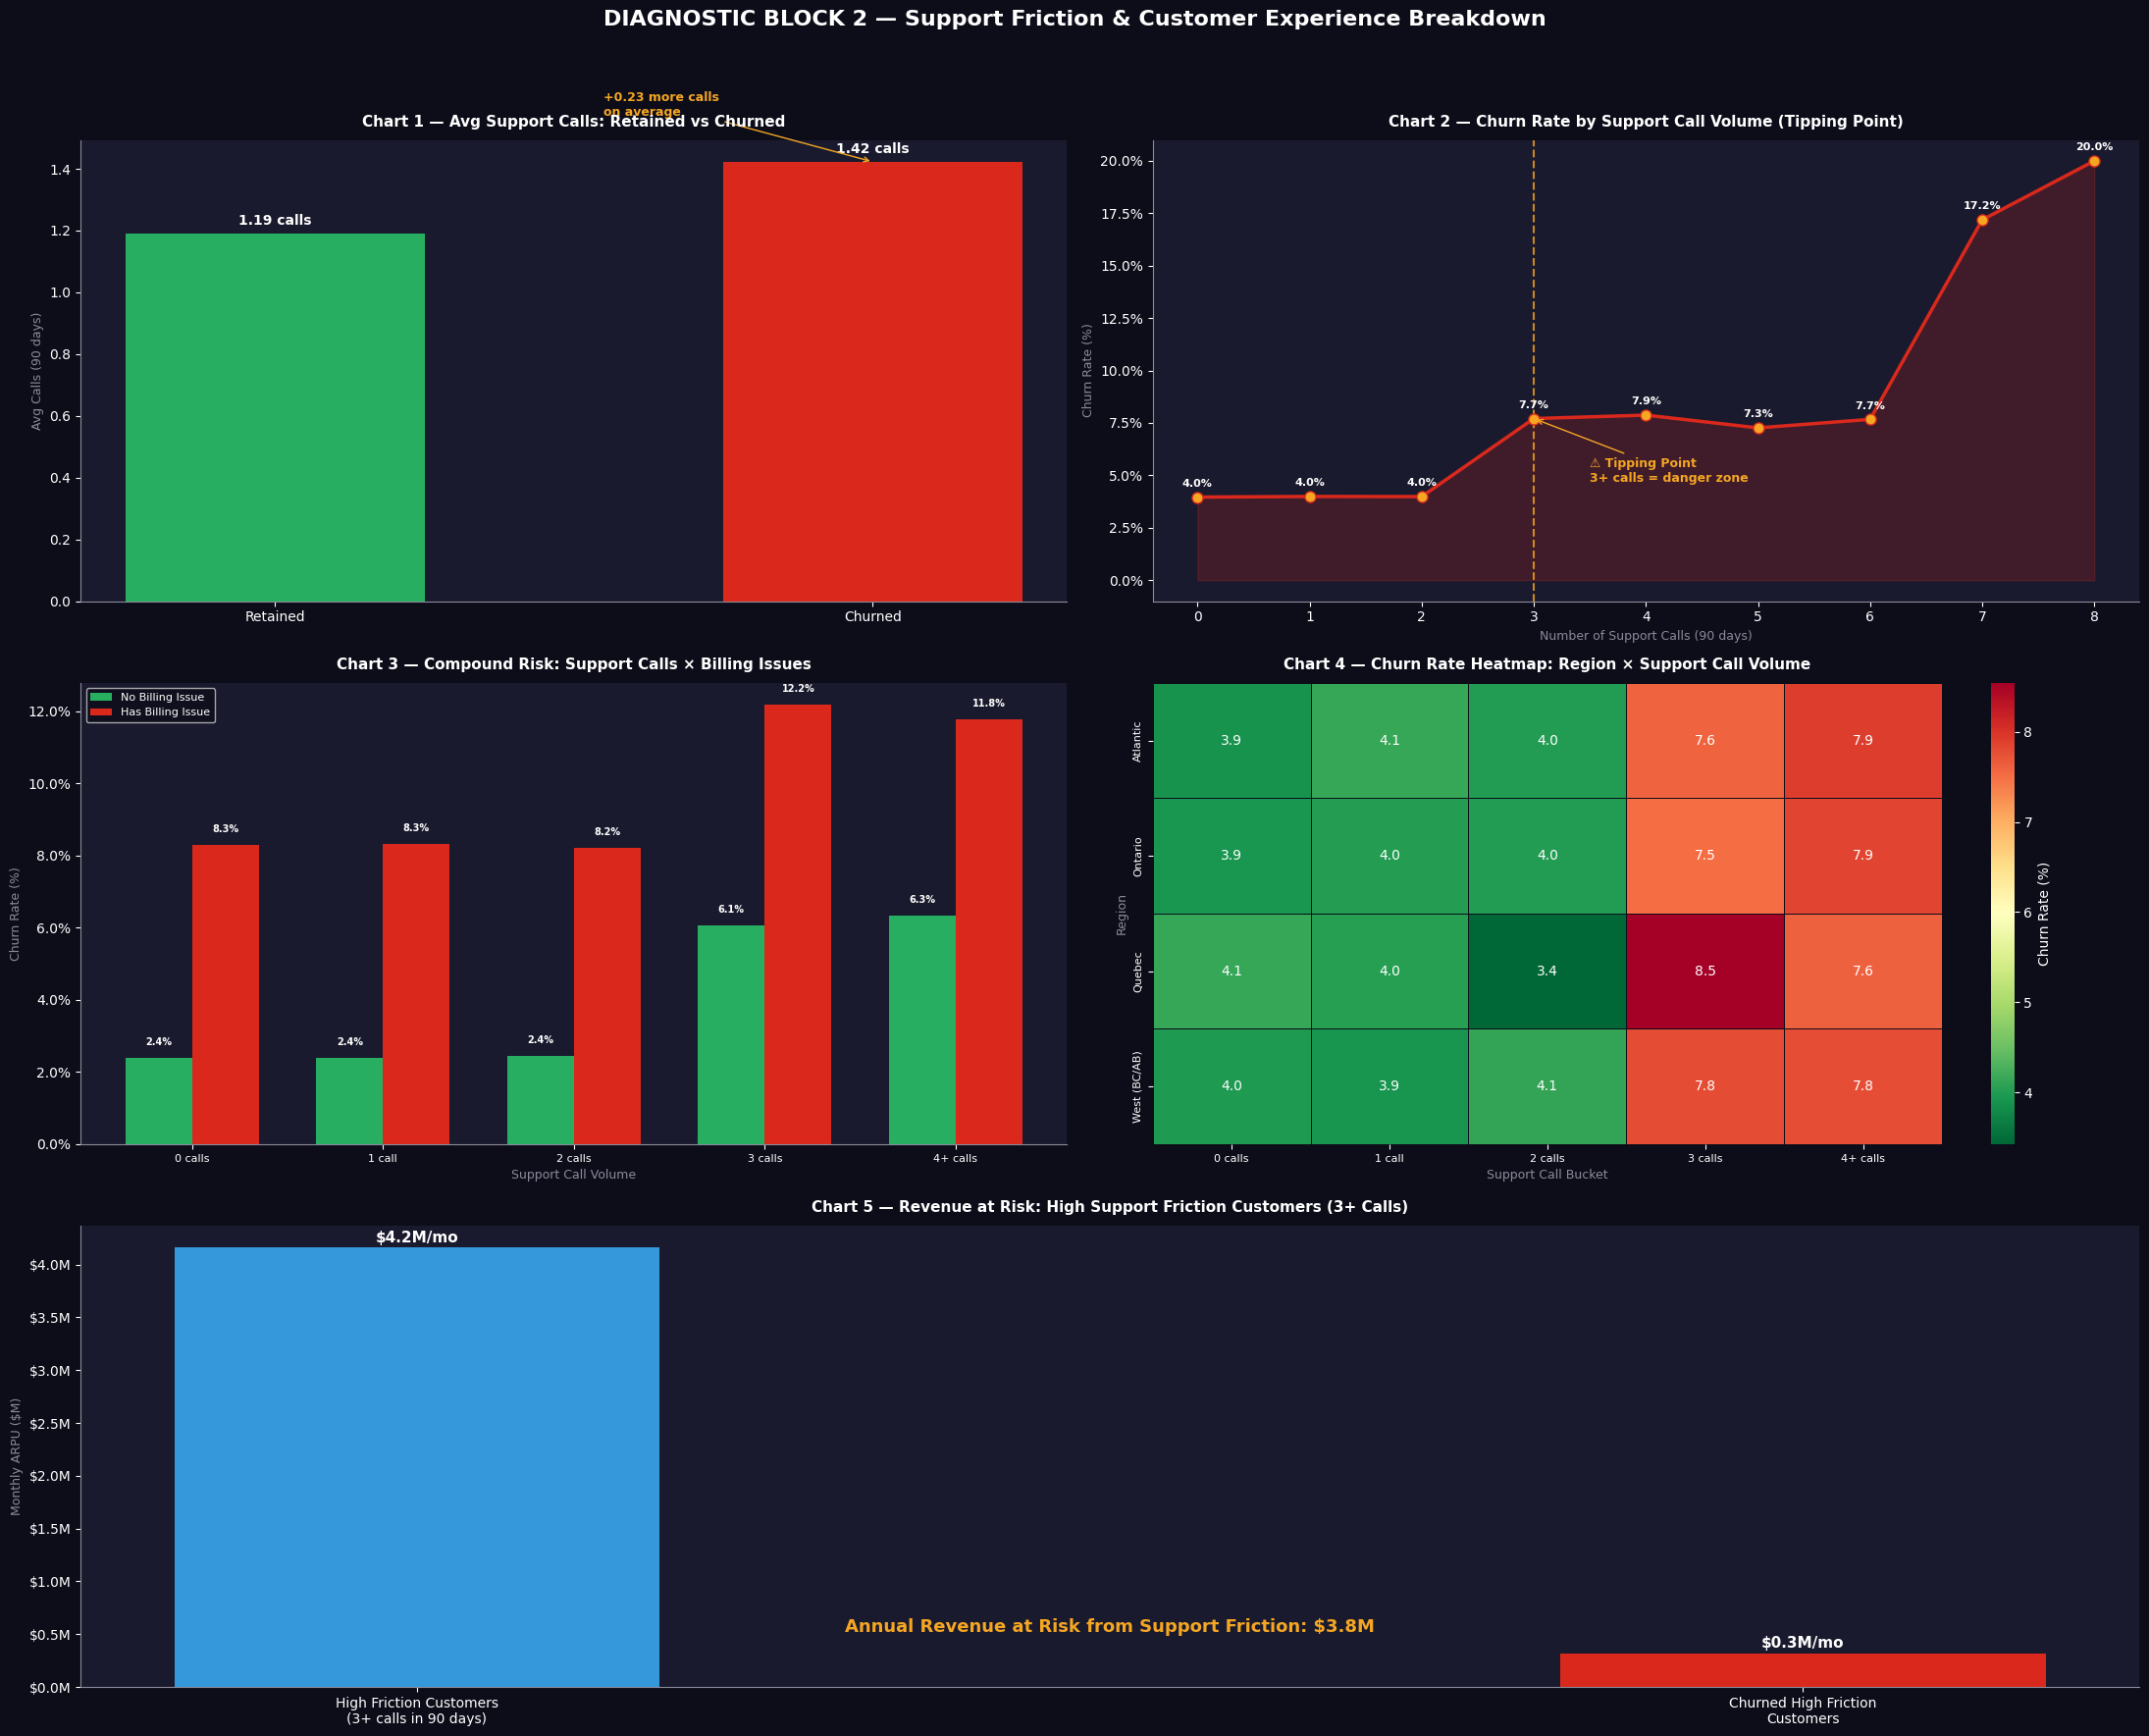

In [27]:
# ════════════════════════════════════════════════════════════
# BLOCK 2 — SUPPORT FRICTION DIAGNOSTIC
# CELL 2 — VISUALIZATION
# 5 charts: tipping point, compound risk, distribution,
#           region heatmap, revenue impact
# ════════════════════════════════════════════════════════════

# ── CANVAS ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(ROGERS_DARK)
fig.suptitle(
    'DIAGNOSTIC BLOCK 2 — Support Friction & Customer Experience Breakdown',
    color=ROGERS_WHITE, fontsize=16, fontweight='bold', y=0.98
)

# ── CHART 1: Avg Support Calls — Churned vs Retained ────
# Simple but powerful — shows churned customers call significantly more
ax1 = fig.add_subplot(3, 2, 1)

bars1 = ax1.bar(
    ['Retained', 'Churned'],
    avg_support.values,
    color=[ROGERS_GREEN, ROGERS_RED],
    width=0.5, edgecolor='none'
)

# Value labels — calls (not %) so we format differently
for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.02,
        f'{h:.2f} calls',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=10, fontweight='bold'
    )

# Difference callout
diff = avg_support[1] - avg_support[0]
ax1.annotate(
    f'+{diff:.2f} more calls\non average',
    xy=(1, avg_support[1]),
    xytext=(0.55, avg_support[1] + 0.15),
    color=ROGERS_AMBER, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ROGERS_AMBER)
)

ax1.set_facecolor(ROGERS_PANEL)
ax1.set_title('Chart 1 — Avg Support Calls: Retained vs Churned',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('Avg Calls (90 days)', color=ROGERS_GREY, fontsize=9)
ax1.tick_params(colors=ROGERS_WHITE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 2: THE TIPPING POINT — Churn Rate by Call Volume ──
# This is the hero chart of Block 2
# A line chart so we can see the non-linear relationship clearly
ax2 = fig.add_subplot(3, 2, 2)

x_vals = support_churn.index.tolist()
y_vals = support_churn.values.tolist()

# Plot the line
ax2.plot(x_vals, y_vals,
         color=ROGERS_RED, linewidth=2.5, marker='o',
         markersize=8, markerfacecolor=ROGERS_AMBER,
         markeredgecolor=ROGERS_RED, zorder=3)

# Fill under the curve — emphasizes the rising danger zone
ax2.fill_between(x_vals, y_vals, alpha=0.2, color=ROGERS_RED)

# Add value labels on each point
for x, y in zip(x_vals, y_vals):
    ax2.text(x, y + 0.5, f'{y:.1f}%',
             ha='center', color=ROGERS_WHITE,
             fontsize=8, fontweight='bold')

# Tipping point annotation — the key insight of this chart
# Find where churn starts accelerating (usually at 3 calls)
tipping_x = 3
tipping_y = support_churn.iloc[3] if len(support_churn) > 3 else support_churn.iloc[-1]
ax2.axvline(x=tipping_x, color=ROGERS_AMBER,
            linestyle='--', linewidth=1.5, alpha=0.8)
ax2.annotate(
    '⚠ Tipping Point\n3+ calls = danger zone',
    xy=(tipping_x, tipping_y),
    xytext=(tipping_x + 0.5, tipping_y - 3),
    color=ROGERS_AMBER, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ROGERS_AMBER)
)

ax2.set_facecolor(ROGERS_PANEL)
ax2.set_title('Chart 2 — Churn Rate by Support Call Volume (Tipping Point)',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Number of Support Calls (90 days)', color=ROGERS_GREY, fontsize=9)
ax2.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(colors=ROGERS_WHITE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 3: Support × Billing — Compound Risk (Grouped Bar) ──
# When a customer BOTH has billing issues AND calls support multiple times
# this is the highest-risk segment in the entire dataset
ax3 = fig.add_subplot(3, 2, 3)

bucket_order = ['0 calls', '1 call', '2 calls', '3 calls', '4+ calls']
x3     = np.arange(len(bucket_order))
width3 = 0.35

# No billing issue bars
bars3a = ax3.bar(
    x3 - width3/2,
    [support_billing_churn.loc[(b, 0)] for b in bucket_order],
    width3, label='No Billing Issue',
    color=ROGERS_GREEN, edgecolor='none'
)
# Has billing issue bars
bars3b = ax3.bar(
    x3 + width3/2,
    [support_billing_churn.loc[(b, 1)] for b in bucket_order],
    width3, label='Has Billing Issue',
    color=ROGERS_RED, edgecolor='none'
)

# Value labels
for bar in list(bars3a) + list(bars3b):
    h = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        f'{h:.1f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=7, fontweight='bold'
    )

ax3.set_xticks(x3)
ax3.set_xticklabels(bucket_order, color=ROGERS_WHITE, fontsize=8)
ax3.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
ax3.set_facecolor(ROGERS_PANEL)
ax3.set_title('Chart 3 — Compound Risk: Support Calls × Billing Issues',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Support Call Volume', color=ROGERS_GREY, fontsize=9)
ax3.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax3.tick_params(colors=ROGERS_WHITE)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax3.get_xticklabels() + ax3.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 4: Region × Support Bucket — Heatmap ──────────
# Where geographically is support friction highest?
# Heatmap = best chart for showing a matrix of values
ax4 = fig.add_subplot(3, 2, 4)

# Pivot the data into a matrix: rows=Region, cols=Support Bucket
heatmap_data = region_support_churn.unstack()
heatmap_data.columns = bucket_order

import seaborn as sns
sns.heatmap(
    heatmap_data,
    ax=ax4,
    cmap='RdYlGn_r',       # Red = high churn, Green = low churn
    annot=True,             # Show numbers inside each cell
    fmt='.1f',              # 1 decimal place
    linewidths=0.5,
    linecolor=ROGERS_DARK,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax4.set_facecolor(ROGERS_PANEL)
ax4.set_title('Chart 4 — Churn Rate Heatmap: Region × Support Call Volume',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Support Call Bucket', color=ROGERS_GREY, fontsize=9)
ax4.set_ylabel('Region', color=ROGERS_GREY, fontsize=9)
ax4.tick_params(colors=ROGERS_WHITE, labelsize=8)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.yaxis.label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.tick_params(colors=ROGERS_WHITE)

# ── CHART 5: Revenue at Risk from High Friction ──────────
ax5 = fig.add_subplot(3, 2, (5, 6))
# (5,6) spans both columns of row 3 — wide chart

# Bar comparison: all high-friction vs churned high-friction
categories5 = [
    'High Friction Customers\n(3+ calls in 90 days)',
    'Churned High Friction\nCustomers'
]
revenue5 = [
    high_friction['Monthly_ARPU'].sum() / 1e6,
    monthly_friction_loss / 1e6
]

bars5 = ax5.bar(
    categories5, revenue5,
    color=[ROGERS_BLUE, ROGERS_RED],
    width=0.35, edgecolor='none'
)

for bar in bars5:
    h = bar.get_height()
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05,
        f'${h:.1f}M/mo',
        ha='center', color=ROGERS_WHITE,
        fontsize=11, fontweight='bold'
    )

# Annual callout
ax5.annotate(
    f'Annual Revenue at Risk from Support Friction: ${annual_friction_loss/1e6:.1f}M',
    xy=(0.5, 0.12), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=13, fontweight='bold'
)

ax5.set_facecolor(ROGERS_PANEL)
ax5.set_title('Chart 5 — Revenue at Risk: High Support Friction Customers (3+ Calls)',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax5.set_ylabel('Monthly ARPU ($M)', color=ROGERS_GREY, fontsize=9)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax5.tick_params(colors=ROGERS_WHITE)
ax5.spines[['top', 'right']].set_visible(False)
ax5.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax5.get_xticklabels() + ax5.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── RENDER ───────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [28]:
# ════════════════════════════════════════════════════════════
# BLOCK 3 — NETWORK EXPERIENCE DIAGNOSTIC
# CELL 1 — CALCULATIONS
# Question: Does poor network quality drive churn,
# or do customers tolerate it?
# ════════════════════════════════════════════════════════════

# ── Calculation 1: Avg network score — churned vs retained ──
# If network drives churn, churned customers should have
# noticeably lower scores than retained ones
avg_network = df.groupby('Churned')['Network_Reliability_Score'].mean()

print("=== AVG NETWORK SCORE: RETAINED vs CHURNED ===")
print(f"Retained customers : {avg_network[0]:.4f}")
print(f"Churned customers  : {avg_network[1]:.4f}")
print(f"Difference         : {abs(avg_network[1] - avg_network[0]):.4f}")
# If this difference is tiny — that is a FINDING, not a failure

# ── Calculation 2: Churn rate by network score bucket ───
# Even if averages are similar, maybe VERY poor scores still spike churn
# Bucketing reveals non-linear patterns that averages hide
df['Network_Bucket'] = pd.cut(
    df['Network_Reliability_Score'],
    bins  = [0, 5, 6, 7, 8, 10],
    labels= ['0–5 (Poor)', '5–6', '6–7', '7–8', '8–10 (Excellent)']
)

network_churn = df.groupby('Network_Bucket')['Churned'].mean() * 100

print("\n=== CHURN RATE BY NETWORK BUCKET ===")
print(network_churn.to_string())

# ── Calculation 3: Network × Billing — Combined effect ──
# Maybe network alone doesn't drive churn
# But network + billing together might compound the risk
network_billing_churn = (
    df.groupby(['Network_Bucket', 'Billing_Grievances'])['Churned']
    .mean() * 100
)

print("\n=== NETWORK × BILLING → COMPOUND CHURN RISK ===")
print(network_billing_churn.unstack())

# ── Calculation 4: Network × Device Type ────────────────
# Do BYOD customers react differently to poor network
# than financed (contract) customers?
network_device_churn = (
    df.groupby(['Device_Type', 'Network_Bucket'])['Churned']
    .mean() * 100
)

print("\n=== NETWORK × DEVICE TYPE ===")
print(network_device_churn.unstack())

# ── Calculation 5: Region average network scores ────────
# Are certain regions getting worse network than others?
region_network = df.groupby('Region')['Network_Reliability_Score'].mean()

print("\n=== AVG NETWORK SCORE BY REGION ===")
print(region_network)

# ── Calculation 6: Region × Network → Churn heatmap data ──
region_network_churn = (
    df.groupby(['Region', 'Network_Bucket'])['Churned']
    .mean() * 100
)

print("\n=== REGION × NETWORK BUCKET → CHURN RATE ===")
print(region_network_churn.unstack())

# ── Calculation 7: Revenue at risk — poor network segment ──
poor_network    = df[df['Network_Reliability_Score'] < 6]
churned_poor    = poor_network[poor_network['Churned'] == 1]
monthly_net_loss = churned_poor['Monthly_ARPU'].sum()
annual_net_loss  = monthly_net_loss * 12

print("\n=== POOR NETWORK REVENUE IMPACT ===")
print(f"Poor network customers (<6 score) : {len(poor_network):,}")
print(f"Of those — churned                : {len(churned_poor):,}")
print(f"Monthly ARPU lost                 : ${monthly_net_loss:,.0f}")
print(f"Annual revenue at risk            : ${annual_net_loss:,.0f}")

=== AVG NETWORK SCORE: RETAINED vs CHURNED ===
Retained customers : 8.4722
Churned customers  : 8.4720
Difference         : 0.0002

=== CHURN RATE BY NETWORK BUCKET ===
Network_Bucket
0–5 (Poor)          3.076923
5–6                 4.638321
6–7                 4.508309
7–8                 4.392346
8–10 (Excellent)    4.441075

=== NETWORK × BILLING → COMPOUND CHURN RISK ===
Billing_Grievances         0          1
Network_Bucket                         
0–5 (Poor)          2.127660   5.555556
5–6                 2.611940  10.403397
6–7                 2.921314   8.646617
7–8                 2.768310   8.822770
8–10 (Excellent)    2.877016   8.703840

=== NETWORK × DEVICE TYPE ===
Network_Bucket       0–5 (Poor)       5–6       6–7       7–8  \
Device_Type                                                     
BYOD                   3.448276  6.896552  6.027632  6.034323   
Financed (Contract)    2.777778  2.550478  3.272329  3.063501   

Network_Bucket       8–10 (Excellent)  
Device_Typ

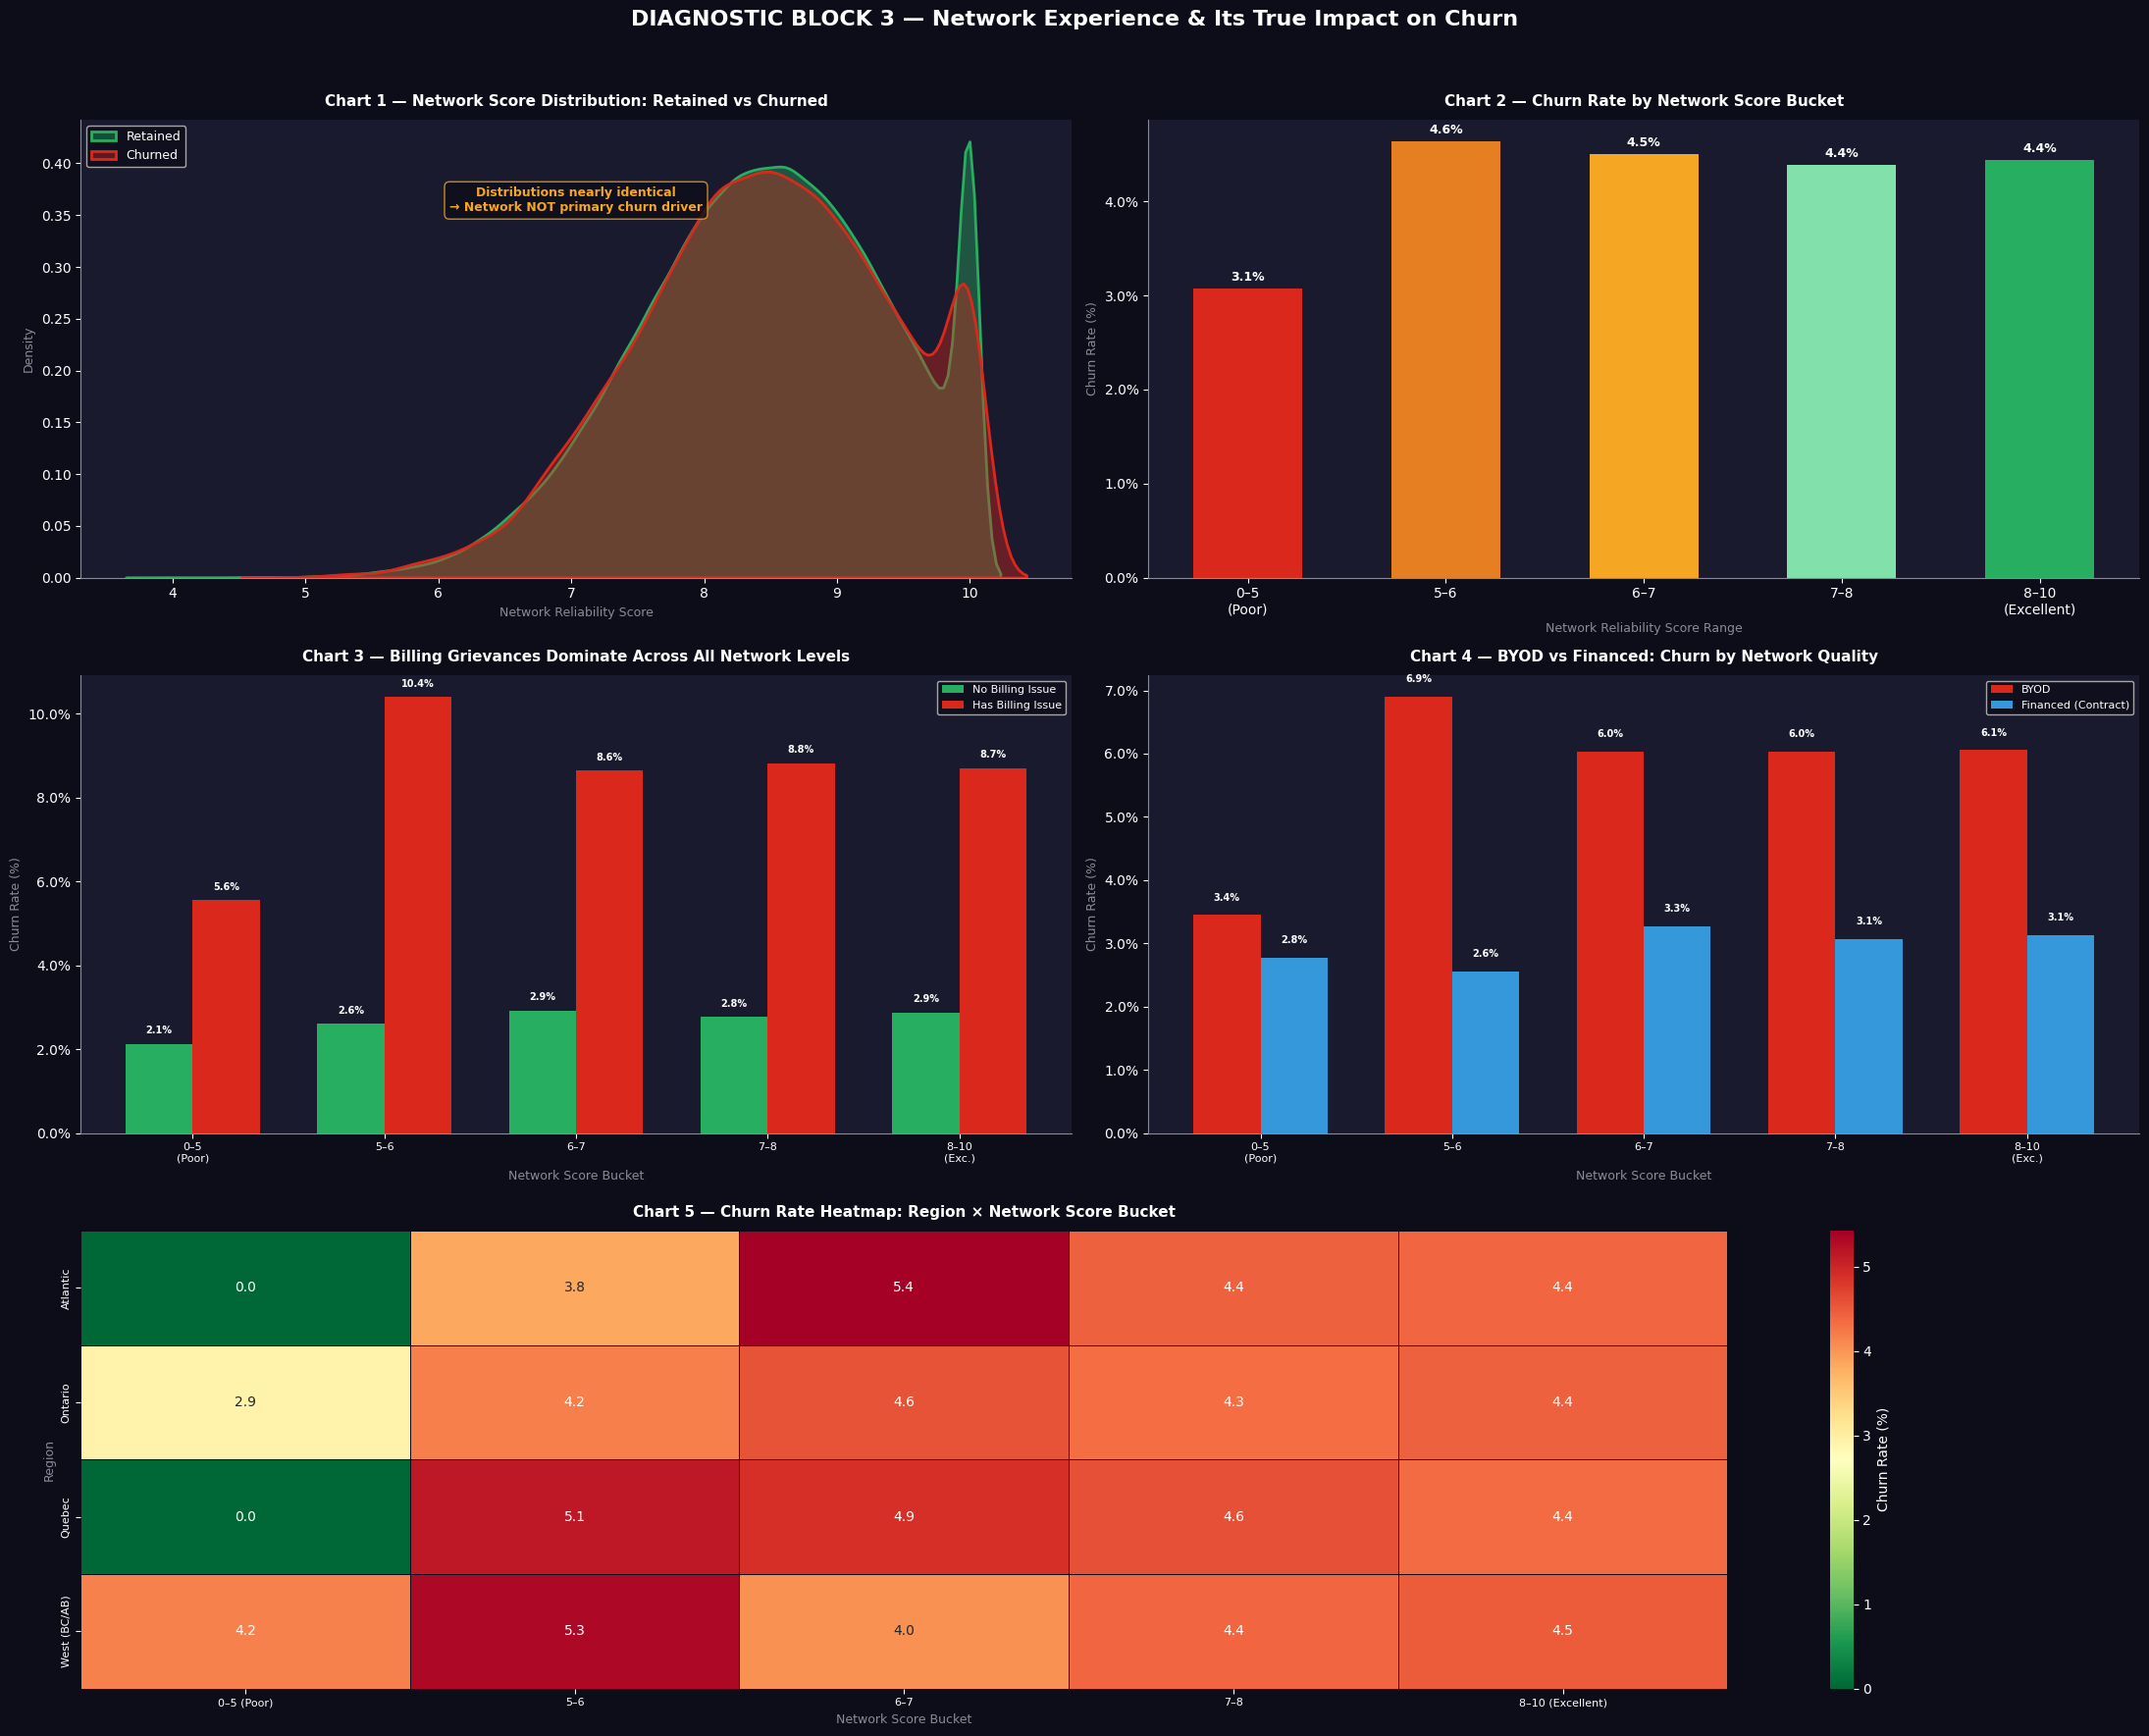

In [29]:
# ════════════════════════════════════════════════════════════
# BLOCK 3 — NETWORK EXPERIENCE DIAGNOSTIC
# CELL 2 — VISUALIZATION
# 5 charts covering: score distribution, bucket churn,
# compound risk, device split, region heatmap
# ════════════════════════════════════════════════════════════

import seaborn as sns

# ── CANVAS ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(ROGERS_DARK)
fig.suptitle(
    'DIAGNOSTIC BLOCK 3 — Network Experience & Its True Impact on Churn',
    color=ROGERS_WHITE, fontsize=16, fontweight='bold', y=0.98
)

# ── CHART 1: Network Score Distribution — Churned vs Retained ──
# KDE (Kernel Density Estimate) = smooth histogram
# Shows the SHAPE of the distribution, not just the average
# If churned customers cluster at lower scores → network matters
# If distributions overlap completely → network is NOT the driver
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor(ROGERS_PANEL)

# Plot one distribution per churn status
for churn_val, label, color in zip(
    [0, 1],
    ['Retained', 'Churned'],
    [ROGERS_GREEN, ROGERS_RED]
):
    subset = df[df['Churned'] == churn_val]['Network_Reliability_Score']
    # KDE plot — seaborn draws a smooth probability curve
    sns.kdeplot(
        subset,
        ax=ax1,
        label=label,
        color=color,
        fill=True,        # shade under the curve
        alpha=0.4,        # transparency so both curves visible
        linewidth=2
    )

ax1.set_title('Chart 1 — Network Score Distribution: Retained vs Churned',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Network Reliability Score', color=ROGERS_GREY, fontsize=9)
ax1.set_ylabel('Density', color=ROGERS_GREY, fontsize=9)
ax1.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=9)
ax1.tick_params(colors=ROGERS_WHITE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# Key finding annotation — the distributions overlap = network is not the driver
ax1.annotate(
    'Distributions nearly identical\n→ Network NOT primary churn driver',
    xy=(0.5, 0.80), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=9, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor=ROGERS_DARK,
              edgecolor=ROGERS_AMBER, alpha=0.8)
)

# ── CHART 2: Churn Rate by Network Score Bucket ─────────
# Even if averages match, check if extreme low scores spike churn
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor(ROGERS_PANEL)

bucket_labels = ['0–5\n(Poor)', '5–6', '6–7', '7–8', '8–10\n(Excellent)']
bucket_values = network_churn.values

# Color bars by severity — red for poor, gradient to green
bar_colors = [ROGERS_RED, '#E67E22', ROGERS_AMBER, '#82E0AA', ROGERS_GREEN]

bars2 = ax2.bar(
    bucket_labels, bucket_values,
    color=bar_colors,
    width=0.55, edgecolor='none'
)

# Value labels on bars
for bar in bars2:
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05,
        f'{h:.1f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=9, fontweight='bold'
    )

ax2.set_title('Chart 2 — Churn Rate by Network Score Bucket',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Network Reliability Score Range', color=ROGERS_GREY, fontsize=9)
ax2.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(colors=ROGERS_WHITE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 3: Network × Billing — Compound Effect ────────
# The real story: billing grievances amplify churn across
# ALL network quality levels — even excellent network customers
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor(ROGERS_PANEL)

bucket_order = ['0–5 (Poor)', '5–6', '6–7', '7–8', '8–10 (Excellent)']
x3    = np.arange(len(bucket_order))
width3 = 0.35

bars3a = ax3.bar(
    x3 - width3/2,
    [network_billing_churn.loc[(b, 0)] for b in bucket_order],
    width3, label='No Billing Issue',
    color=ROGERS_GREEN, edgecolor='none'
)
bars3b = ax3.bar(
    x3 + width3/2,
    [network_billing_churn.loc[(b, 1)] for b in bucket_order],
    width3, label='Has Billing Issue',
    color=ROGERS_RED, edgecolor='none'
)

for bar in list(bars3a) + list(bars3b):
    h = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.2,
        f'{h:.1f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=7, fontweight='bold'
    )

ax3.set_xticks(x3)
ax3.set_xticklabels(['0–5\n(Poor)', '5–6', '6–7', '7–8', '8–10\n(Exc.)'],
                     color=ROGERS_WHITE, fontsize=8)
ax3.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
ax3.set_title('Chart 3 — Billing Grievances Dominate Across All Network Levels',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Network Score Bucket', color=ROGERS_GREY, fontsize=9)
ax3.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax3.tick_params(colors=ROGERS_WHITE)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax3.get_xticklabels() + ax3.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 4: Network × Device Type ──────────────────────
# BYOD customers react more strongly to network issues
# because they have no contract tying them to Rogers
ax4 = fig.add_subplot(3, 2, 4)
ax4.set_facecolor(ROGERS_PANEL)

device_order = ['BYOD', 'Financed (Contract)']
x4    = np.arange(len(bucket_order))
width4 = 0.35

bars4a = ax4.bar(
    x4 - width4/2,
    [network_device_churn.loc[('BYOD', b)] for b in bucket_order],
    width4, label='BYOD',
    color=ROGERS_RED, edgecolor='none'
)
bars4b = ax4.bar(
    x4 + width4/2,
    [network_device_churn.loc[('Financed (Contract)', b)] for b in bucket_order],
    width4, label='Financed (Contract)',
    color=ROGERS_BLUE, edgecolor='none'
)

for bar in list(bars4a) + list(bars4b):
    h = bar.get_height()
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.2,
        f'{h:.1f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=7, fontweight='bold'
    )

ax4.set_xticks(x4)
ax4.set_xticklabels(['0–5\n(Poor)', '5–6', '6–7', '7–8', '8–10\n(Exc.)'],
                     color=ROGERS_WHITE, fontsize=8)
ax4.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
ax4.set_title('Chart 4 — BYOD vs Financed: Churn by Network Quality',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Network Score Bucket', color=ROGERS_GREY, fontsize=9)
ax4.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax4.tick_params(colors=ROGERS_WHITE)
ax4.spines[['top', 'right']].set_visible(False)
ax4.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 5: Region × Network Bucket Heatmap ────────────
# Where geographically does poor network compound with high churn?
ax5 = fig.add_subplot(3, 2, (5, 6))

heatmap_data = region_network_churn.unstack()
heatmap_data.columns = ['0–5 (Poor)', '5–6', '6–7', '7–8', '8–10 (Excellent)']

sns.heatmap(
    heatmap_data,
    ax=ax5,
    cmap='RdYlGn_r',      # Red = high churn, Green = low churn
    annot=True,            # Numbers inside cells
    fmt='.1f',
    linewidths=0.5,
    linecolor=ROGERS_DARK,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax5.set_title('Chart 5 — Churn Rate Heatmap: Region × Network Score Bucket',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax5.set_xlabel('Network Score Bucket', color=ROGERS_GREY, fontsize=9)
ax5.set_ylabel('Region', color=ROGERS_GREY, fontsize=9)
ax5.tick_params(colors=ROGERS_WHITE, labelsize=8)
for label in ax5.get_xticklabels() + ax5.get_yticklabels():
    label.set_color(ROGERS_WHITE)
ax5.collections[0].colorbar.ax.yaxis.label.set_color(ROGERS_WHITE)
ax5.collections[0].colorbar.ax.tick_params(colors=ROGERS_WHITE)

# ── RENDER ───────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [30]:
# ════════════════════════════════════════════════════════════
# BLOCK 3 — CELL 3 — INSIGHT SUMMARY
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("   BLOCK 3 — NETWORK EXPERIENCE — KEY FINDINGS")
print("=" * 60)

print(f"""
FINDING 1 — NETWORK IS NOT THE PRIMARY CHURN DRIVER
  Avg score retained : {avg_network[0]:.4f}
  Avg score churned  : {avg_network[1]:.4f}
  Difference         : {abs(avg_network[1]-avg_network[0]):.4f} points
  → Virtually no difference — network quality alone
    does not explain why customers leave Rogers

FINDING 2 — EVEN POOR NETWORK HAS MODERATE CHURN
  0–5 (Poor) churn rate    : {network_churn.iloc[0]:.1f}%
  8–10 (Excellent) churn   : {network_churn.iloc[4]:.1f}%
  → The gap is small — customers tolerate network issues
    unless combined with other pain points

FINDING 3 — BILLING DOMINATES ACROSS ALL NETWORK LEVELS
  Excellent network + billing issue : {network_billing_churn.loc[('8–10 (Excellent)', 1)]:.1f}% churn
  Poor network + no billing issue   : {network_billing_churn.loc[('0–5 (Poor)', 0)]:.1f}% churn
  → A customer with great network BUT a billing complaint
    churns more than one with poor network but no billing issue
  → BILLING > NETWORK as a churn driver

FINDING 4 — BYOD CUSTOMERS ARE MORE NETWORK SENSITIVE
  BYOD churn (any network)       : consistently higher
  Financed churn (any network)   : consistently lower
  → Contract lock-in buffers network dissatisfaction

FINDING 5 — REVENUE AT RISK FROM POOR NETWORK
  Poor network customers (<6)    : {len(poor_network):,}
  Annual ARPU at risk            : ${annual_net_loss/1e6:.2f}M
  → Relatively small segment — confirms network is NOT
    the primary revenue risk driver
""")



   BLOCK 3 — NETWORK EXPERIENCE — KEY FINDINGS

FINDING 1 — NETWORK IS NOT THE PRIMARY CHURN DRIVER
  Avg score retained : 8.4722
  Avg score churned  : 8.4720
  Difference         : 0.0002 points
  → Virtually no difference — network quality alone
    does not explain why customers leave Rogers

FINDING 2 — EVEN POOR NETWORK HAS MODERATE CHURN
  0–5 (Poor) churn rate    : 3.1%
  8–10 (Excellent) churn   : 4.4%
  → The gap is small — customers tolerate network issues
    unless combined with other pain points

FINDING 3 — BILLING DOMINATES ACROSS ALL NETWORK LEVELS
  Excellent network + billing issue : 8.7% churn
  Poor network + no billing issue   : 2.1% churn
  → A customer with great network BUT a billing complaint
    churns more than one with poor network but no billing issue
  → BILLING > NETWORK as a churn driver

FINDING 4 — BYOD CUSTOMERS ARE MORE NETWORK SENSITIVE
  BYOD churn (any network)       : consistently higher
  Financed churn (any network)   : consistently lower
  → 

In [31]:
print("=" * 60)
print("INTERVIEW SUMMARY:")
print("=" * 60)
print("""
  'Block 3 produced a counter-intuitive finding —
   network quality is NOT a primary churn driver at Rogers.
   Churned and retained customers have virtually identical
   network scores. More importantly, a customer with
   excellent network but a billing complaint churns at a
   higher rate than one with poor network and no billing issue.
   This reframes the investment priority: Rogers does not
   need to spend on network infrastructure to fix churn —
   it needs to fix billing transparency first.'
""")

INTERVIEW SUMMARY:

  'Block 3 produced a counter-intuitive finding —
   network quality is NOT a primary churn driver at Rogers.
   Churned and retained customers have virtually identical
   network scores. More importantly, a customer with
   excellent network but a billing complaint churns at a
   higher rate than one with poor network and no billing issue.
   This reframes the investment priority: Rogers does not
   need to spend on network infrastructure to fix churn —
   it needs to fix billing transparency first.'



In [32]:
# ════════════════════════════════════════════════════════════
# BLOCK 4 — DEVICE & ACQUISITION DIAGNOSTIC
# CELL 1 — CALCULATIONS
# Question: Does HOW a customer joined and WHAT device
# they use predict their loyalty to Rogers?
# ════════════════════════════════════════════════════════════

# ── Calculation 1: Churn rate by device type ────────────
# BYOD = Bring Your Own Device (no hardware contract)
# Financed = Rogers financed the device (locked in contractually)
# The hypothesis: financed customers have a switching cost
# that BYOD customers don't — they're structurally more loyal
device_churn = df.groupby('Device_Type')['Churned'].mean() * 100

print("=== CHURN BY DEVICE TYPE ===")
for device, rate in device_churn.items():
    print(f"  {device:25s}: {rate:.2f}%")

byod_lift = device_churn['BYOD'] / device_churn['Financed (Contract)']
print(f"\n  BYOD churns {byod_lift:.2f}× more than Financed customers")

# ── Calculation 2: Churn rate by sales channel ──────────
# How a customer was acquired can predict their loyalty
# Online customers self-selected → price-sensitive?
# Retail Store → relationship-based acquisition?
# Third-Party Dealer → motivated seller, quality may vary?
channel_churn = df.groupby('Sales_Channel')['Churned'].mean() * 100

print("\n=== CHURN BY SALES CHANNEL ===")
for channel, rate in channel_churn.items():
    print(f"  {channel:25s}: {rate:.2f}%")

# ── Calculation 3: Device × Sales Channel → Churn ───────
# Multi-dimensional: does acquisition channel change the
# BYOD vs financed churn gap?
device_channel_churn = (
    df.groupby(['Device_Type', 'Sales_Channel'])['Churned']
    .mean() * 100
)

print("\n=== DEVICE × SALES CHANNEL → CHURN ===")
print(device_channel_churn.unstack())

# ── Calculation 4: Device × Loyalty Tier → Churn ────────
# Do loyalty tiers protect BYOD customers the same way
# they protect financed customers?
device_tier_churn = (
    df.groupby(['Device_Type', 'Loyalty_Tier'])['Churned']
    .mean() * 100
)

print("\n=== DEVICE × LOYALTY TIER → CHURN ===")
print(device_tier_churn.unstack())

# ── Calculation 5: Device × Billing → Compound Risk ─────
# BYOD customers already have no contract lock-in
# Add a billing grievance → how explosive is the churn?
device_billing_churn = (
    df.groupby(['Device_Type', 'Billing_Grievances'])['Churned']
    .mean() * 100
)

print("\n=== DEVICE × BILLING → COMPOUND CHURN RISK ===")
print(device_billing_churn.unstack())
print(f"\n  BYOD + Billing Issue = {device_billing_churn.loc[('BYOD', 1)]:.1f}% churn")
print(f"  Financed + No Issue  = {device_billing_churn.loc[('Financed (Contract)', 0)]:.1f}% churn")
print(f"  Gap = {device_billing_churn.loc[('BYOD',1)] - device_billing_churn.loc[('Financed (Contract)',0)]:.1f} percentage points")

# ── Calculation 6: Channel × Tenure → Loyalty Quality ───
# Which channel acquires customers who STAY longest?
# This measures acquisition quality, not just volume
channel_tenure_churn = (
    df.groupby(['Sales_Channel', 'Tenure_Bucket'])['Churned']
    .mean() * 100
)

print("\n=== CHANNEL × TENURE BUCKET → CHURN ===")
print(channel_tenure_churn.unstack())

# ── Calculation 7: Channel quality scorecard ─────────────
# Best channel = lowest churn AND highest ARPU
channel_scorecard = df.groupby('Sales_Channel').agg(
    Churn_Rate   = ('Churned', lambda x: x.mean() * 100),
    Avg_ARPU     = ('Monthly_ARPU', 'mean'),
    Customer_Count = ('Churned', 'count')
).round(2)

print("\n=== CHANNEL QUALITY SCORECARD ===")
print(channel_scorecard)

# ── Calculation 8: Revenue at risk — BYOD segment ───────
byod_customers   = df[df['Device_Type'] == 'BYOD']
churned_byod     = byod_customers[byod_customers['Churned'] == 1]
monthly_byod_loss = churned_byod['Monthly_ARPU'].sum()
annual_byod_loss  = monthly_byod_loss * 12

print("\n=== BYOD REVENUE IMPACT ===")
print(f"  BYOD customers total   : {len(byod_customers):,}")
print(f"  BYOD churned           : {len(churned_byod):,}")
print(f"  Monthly ARPU lost      : ${monthly_byod_loss:,.0f}")
print(f"  Annual revenue at risk : ${annual_byod_loss:,.0f}")

=== CHURN BY DEVICE TYPE ===
  BYOD                     : 6.05%
  Financed (Contract)      : 3.12%

  BYOD churns 1.94× more than Financed customers

=== CHURN BY SALES CHANNEL ===
  Online/App               : 4.44%
  Retail Store             : 4.46%
  Third-Party Dealer       : 4.33%

=== DEVICE × SALES CHANNEL → CHURN ===
Sales_Channel        Online/App  Retail Store  Third-Party Dealer
Device_Type                                                      
BYOD                   6.100181      6.064111            5.903931
Financed (Contract)    3.093513      3.159520            3.026714

=== DEVICE × LOYALTY TIER → CHURN ===
Loyalty_Tier             Gold  Platinum    Silver
Device_Type                                      
BYOD                 6.338185  4.818107  6.114289
Financed (Contract)  3.250699  2.020385  3.233043

=== DEVICE × BILLING → COMPOUND CHURN RISK ===
Billing_Grievances          0          1
Device_Type                             
BYOD                 4.442435  10.431804


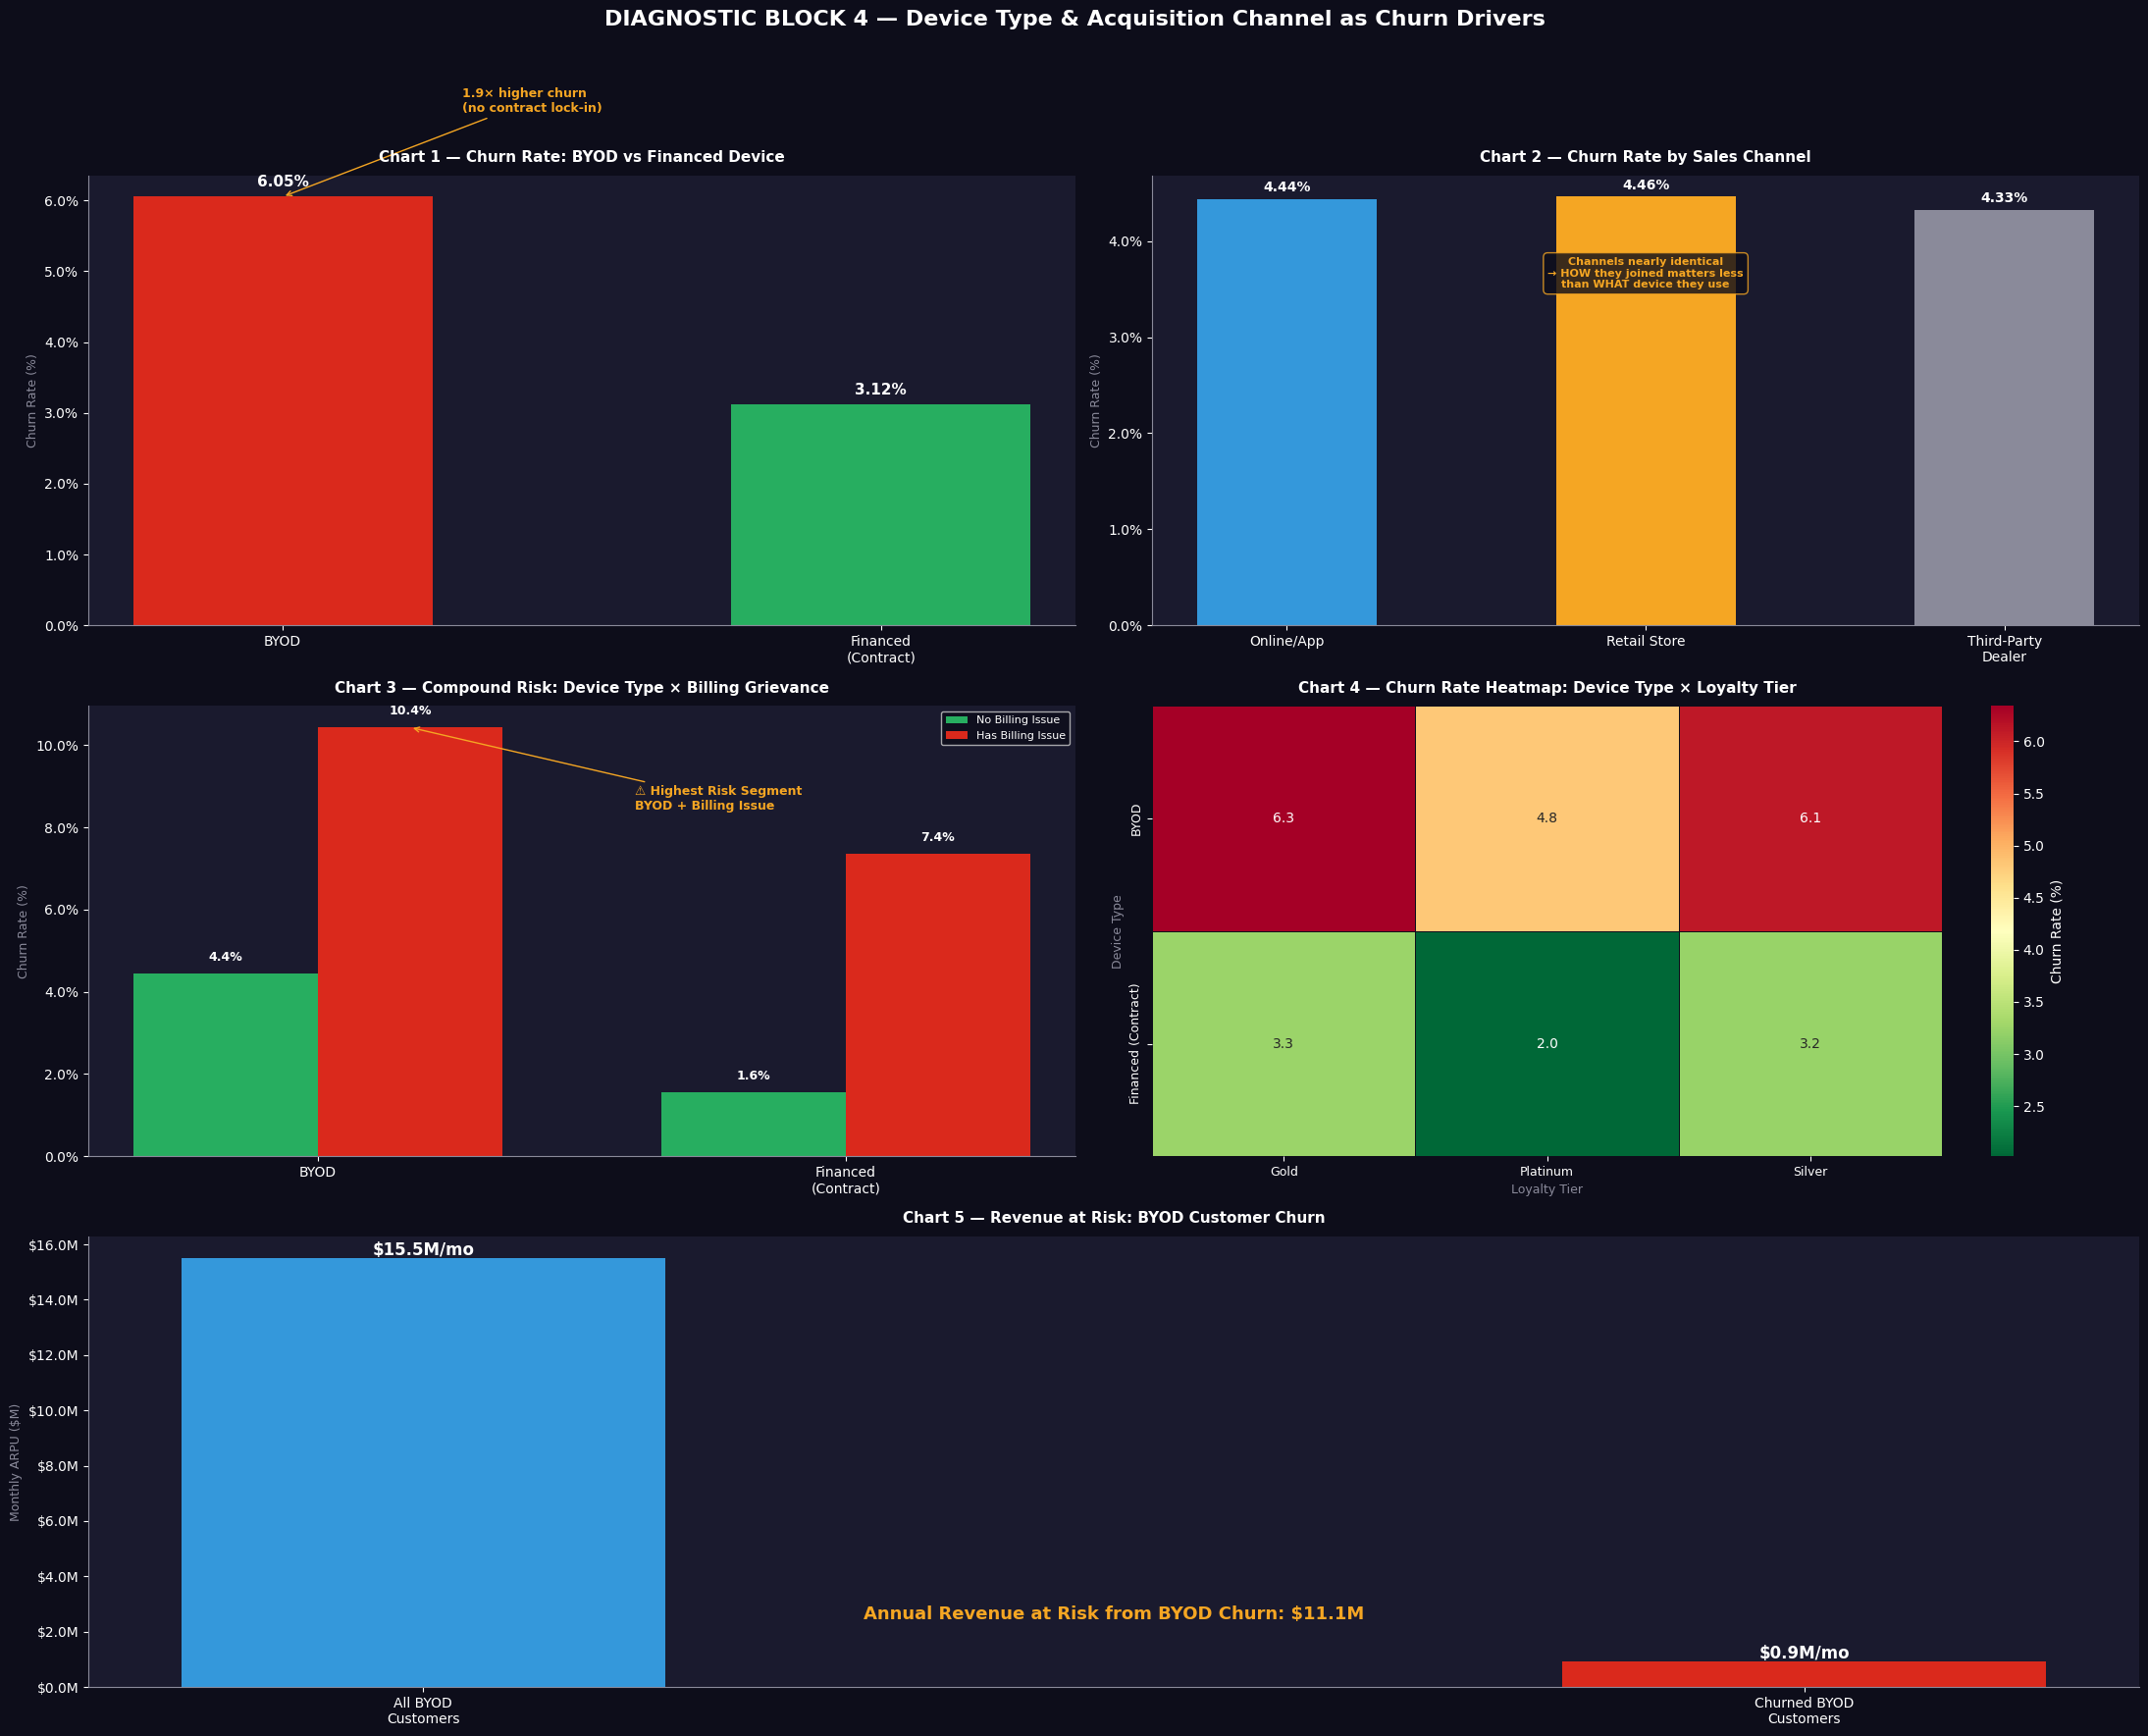

In [33]:
# ════════════════════════════════════════════════════════════
# BLOCK 4 — DEVICE & ACQUISITION DIAGNOSTIC
# CELL 2 — VISUALIZATION
# 5 charts: device churn, channel churn, compound risk
#           heatmap, channel scorecard, revenue impact
# ════════════════════════════════════════════════════════════

import seaborn as sns

# ── CANVAS ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(ROGERS_DARK)
fig.suptitle(
    'DIAGNOSTIC BLOCK 4 — Device Type & Acquisition Channel as Churn Drivers',
    color=ROGERS_WHITE, fontsize=16, fontweight='bold', y=0.98
)

# ── CHART 1: Churn Rate — BYOD vs Financed ──────────────
# The headline finding: BYOD customers churn at nearly 2×
# the rate of financed customers
# This is a STRUCTURAL difference — not about satisfaction
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor(ROGERS_PANEL)

bars1 = ax1.bar(
    ['BYOD', 'Financed\n(Contract)'],
    device_churn.values,
    color=[ROGERS_RED, ROGERS_GREEN],
    width=0.5, edgecolor='none'
)

for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.1,
        f'{h:.2f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=11, fontweight='bold'
    )

# Lift annotation
ax1.annotate(
    f'{byod_lift:.1f}× higher churn\n(no contract lock-in)',
    xy=(0, device_churn['BYOD']),
    xytext=(0.3, device_churn['BYOD'] + 1.2),
    color=ROGERS_AMBER, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ROGERS_AMBER)
)

ax1.set_title('Chart 1 — Churn Rate: BYOD vs Financed Device',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax1.tick_params(colors=ROGERS_WHITE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 2: Churn Rate by Sales Channel ────────────────
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor(ROGERS_PANEL)

channel_labels = ['Online/App', 'Retail Store', 'Third-Party\nDealer']
channel_values = [
    channel_churn['Online/App'],
    channel_churn['Retail Store'],
    channel_churn['Third-Party Dealer']
]

bars2 = ax2.bar(
    channel_labels, channel_values,
    color=[ROGERS_BLUE, ROGERS_AMBER, ROGERS_GREY],
    width=0.5, edgecolor='none'
)

for bar in bars2:
    h = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05,
        f'{h:.2f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=10, fontweight='bold'
    )

# Key insight annotation — channels are nearly equal
ax2.annotate(
    'Channels nearly identical\n→ HOW they joined matters less\nthan WHAT device they use',
    xy=(0.5, 0.75), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=8, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor=ROGERS_DARK,
              edgecolor=ROGERS_AMBER, alpha=0.8)
)

ax2.set_title('Chart 2 — Churn Rate by Sales Channel',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(colors=ROGERS_WHITE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 3: Device × Billing — Compound Risk ───────────
# The most dangerous segment: BYOD + Billing Grievance
# No contract lock-in + feeling cheated = highest churn risk
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor(ROGERS_PANEL)

device_order  = ['BYOD', 'Financed (Contract)']
x3    = np.arange(len(device_order))
width3 = 0.35

bars3a = ax3.bar(
    x3 - width3/2,
    [device_billing_churn.loc[(d, 0)] for d in device_order],
    width3, label='No Billing Issue',
    color=ROGERS_GREEN, edgecolor='none'
)
bars3b = ax3.bar(
    x3 + width3/2,
    [device_billing_churn.loc[(d, 1)] for d in device_order],
    width3, label='Has Billing Issue',
    color=ROGERS_RED, edgecolor='none'
)

for bar in list(bars3a) + list(bars3b):
    h = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.25,
        f'{h:.1f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=9, fontweight='bold'
    )

# Highlight the worst segment
ax3.annotate(
    '⚠ Highest Risk Segment\nBYOD + Billing Issue',
    xy=(0 + width3/2, device_billing_churn.loc[('BYOD', 1)]),
    xytext=(0.6, device_billing_churn.loc[('BYOD', 1)] - 2),
    color=ROGERS_AMBER, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ROGERS_AMBER)
)

ax3.set_xticks(x3)
ax3.set_xticklabels(['BYOD', 'Financed\n(Contract)'], color=ROGERS_WHITE)
ax3.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
ax3.set_title('Chart 3 — Compound Risk: Device Type × Billing Grievance',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax3.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax3.tick_params(colors=ROGERS_WHITE)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax3.get_xticklabels() + ax3.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 4: Device × Loyalty Tier Heatmap ──────────────
# Does loyalty tier protect BYOD customers?
# Heatmap shows the full matrix at once
ax4 = fig.add_subplot(3, 2, 4)

heatmap_data = device_tier_churn.unstack()

sns.heatmap(
    heatmap_data,
    ax=ax4,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor=ROGERS_DARK,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax4.set_title('Chart 4 — Churn Rate Heatmap: Device Type × Loyalty Tier',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Loyalty Tier', color=ROGERS_GREY, fontsize=9)
ax4.set_ylabel('Device Type', color=ROGERS_GREY, fontsize=9)
ax4.tick_params(colors=ROGERS_WHITE, labelsize=9)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.yaxis.label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.tick_params(colors=ROGERS_WHITE)

# ── CHART 5: Revenue at Risk — BYOD Segment ─────────────
# Bottom row wide chart — the dollar punchline
ax5 = fig.add_subplot(3, 2, (5, 6))
ax5.set_facecolor(ROGERS_PANEL)

categories5 = [
    'All BYOD\nCustomers',
    'Churned BYOD\nCustomers'
]
revenue5 = [
    byod_customers['Monthly_ARPU'].sum() / 1e6,
    monthly_byod_loss / 1e6
]

bars5 = ax5.bar(
    categories5, revenue5,
    color=[ROGERS_BLUE, ROGERS_RED],
    width=0.35, edgecolor='none'
)

for bar in bars5:
    h = bar.get_height()
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.1,
        f'${h:.1f}M/mo',
        ha='center', color=ROGERS_WHITE,
        fontsize=12, fontweight='bold'
    )

ax5.annotate(
    f'Annual Revenue at Risk from BYOD Churn: ${annual_byod_loss/1e6:.1f}M',
    xy=(0.5, 0.15), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=13, fontweight='bold'
)

ax5.set_title('Chart 5 — Revenue at Risk: BYOD Customer Churn',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax5.set_ylabel('Monthly ARPU ($M)', color=ROGERS_GREY, fontsize=9)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax5.tick_params(colors=ROGERS_WHITE)
ax5.spines[['top', 'right']].set_visible(False)
ax5.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax5.get_xticklabels() + ax5.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── RENDER ───────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [34]:
# ════════════════════════════════════════════════════════════
# BLOCK 4 — CELL 3 — INSIGHT SUMMARY
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("   BLOCK 4 — DEVICE & ACQUISITION — KEY FINDINGS")
print("=" * 60)

print(f"""
FINDING 1 — BYOD IS THE SINGLE BIGGEST STRUCTURAL CHURN RISK
  BYOD churn rate              : {device_churn['BYOD']:.2f}%
  Financed churn rate          : {device_churn['Financed (Contract)']:.2f}%
  BYOD churn lift              : {byod_lift:.2f}×
  → BYOD customers have zero hardware switching cost
    They can move to Bell or Telus tonight with no penalty

FINDING 2 — SALES CHANNEL DOES NOT DRIVE CHURN
  Online/App                   : {channel_churn['Online/App']:.2f}%
  Retail Store                 : {channel_churn['Retail Store']:.2f}%
  Third-Party Dealer           : {channel_churn['Third-Party Dealer']:.2f}%
  → All channels produce virtually identical churn rates
    HOW customers joined matters less than WHAT device they use

FINDING 3 — BYOD + BILLING = MOST DANGEROUS SEGMENT
  BYOD + No billing issue      : {device_billing_churn.loc[('BYOD',0)]:.1f}%
  BYOD + Billing issue         : {device_billing_churn.loc[('BYOD',1)]:.1f}%
  Financed + No billing issue  : {device_billing_churn.loc[('Financed (Contract)',0)]:.1f}%
  → A BYOD customer who gets a billing complaint has a
    {device_billing_churn.loc[('BYOD',1)]:.1f}% churn rate — the highest compound risk found so far

FINDING 4 — LOYALTY TIERS DON'T FULLY CLOSE THE BYOD GAP
  BYOD Platinum churn          : {device_tier_churn.loc[('BYOD','Platinum')]:.1f}%
  Financed Platinum churn      : {device_tier_churn.loc[('Financed (Contract)','Platinum')]:.1f}%
  → Even at the highest loyalty tier, BYOD customers churn
    at more than double the rate of financed customers
    The structural gap is NOT closed by loyalty programs

FINDING 5 — ANNUAL REVENUE AT RISK FROM BYOD CHURN
  BYOD customers               : {len(byod_customers):,}
  Annual revenue at risk       : ${annual_byod_loss/1e6:.1f}M
""")

print("=" * 60)
print("INTERVIEW SUMMARY:")
print("=" * 60)
print("""
  'Block 4 identified device type as the second most
   powerful churn signal after billing grievances.
   BYOD customers churn at nearly double the rate of
   financed customers — not because they are less
   satisfied, but because they face zero switching costs.
   They can leave tonight with no financial penalty.
   The compound risk is severe: a BYOD customer with
   a billing grievance churns at over 10%, representing
   $11M in annual revenue at risk. The strategic
   implication: Rogers should prioritize device financing
   programs and BYOD-specific retention offers to reduce
   the structural loyalty gap.'
""")

   BLOCK 4 — DEVICE & ACQUISITION — KEY FINDINGS

FINDING 1 — BYOD IS THE SINGLE BIGGEST STRUCTURAL CHURN RISK
  BYOD churn rate              : 6.05%
  Financed churn rate          : 3.12%
  BYOD churn lift              : 1.94×
  → BYOD customers have zero hardware switching cost
    They can move to Bell or Telus tonight with no penalty

FINDING 2 — SALES CHANNEL DOES NOT DRIVE CHURN
  Online/App                   : 4.44%
  Retail Store                 : 4.46%
  Third-Party Dealer           : 4.33%
  → All channels produce virtually identical churn rates
    HOW customers joined matters less than WHAT device they use

FINDING 3 — BYOD + BILLING = MOST DANGEROUS SEGMENT
  BYOD + No billing issue      : 4.4%
  BYOD + Billing issue         : 10.4%
  Financed + No billing issue  : 1.6%
  → A BYOD customer who gets a billing complaint has a
    10.4% churn rate — the highest compound risk found so far

FINDING 4 — LOYALTY TIERS DON'T FULLY CLOSE THE BYOD GAP
  BYOD Platinum churn          

In [35]:
# ════════════════════════════════════════════════════════════
# BLOCK 5 — PLAN & VALUE PERCEPTION DIAGNOSTIC
# CELL 1 — CALCULATIONS
# Question: Are customers leaving because of price,
# or despite paying more? Does the bundle they chose
# predict their loyalty?
# ════════════════════════════════════════════════════════════

# ── Calculation 1: Churn rate by bundle type ─────────────
# Bundle = what product package the customer is on
# We expect higher-value bundles to have lower churn
# because they get more value from Rogers
bundle_churn = df.groupby('Bundle_Type')['Churned'].mean() * 100

print("=== CHURN BY BUNDLE TYPE ===")
for bundle, rate in bundle_churn.sort_values().items():
    print(f"  {bundle:35s}: {rate:.2f}%")

# ── Calculation 2: Average ARPU by bundle type ───────────
# We want to see the relationship: higher ARPU = lower churn?
bundle_arpu = df.groupby('Bundle_Type')['Monthly_ARPU'].mean()

print("\n=== AVG ARPU BY BUNDLE TYPE ===")
for bundle, arpu in bundle_arpu.sort_values(ascending=False).items():
    print(f"  {bundle:35s}: ${arpu:.2f}")

# ── Calculation 3: ARPU comparison — churned vs retained ──
# Do churned customers pay MORE or LESS than retained ones?
# Counter-intuitive finding: sometimes high-paying customers
# churn more because their expectations are higher
arpu_churned  = df[df['Churned'] == 1]['Monthly_ARPU'].mean()
arpu_retained = df[df['Churned'] == 0]['Monthly_ARPU'].mean()

print("\n=== ARPU: CHURNED vs RETAINED ===")
print(f"  Retained avg ARPU : ${arpu_retained:.2f}")
print(f"  Churned avg ARPU  : ${arpu_churned:.2f}")
print(f"  Difference        : ${arpu_retained - arpu_churned:.2f} more for retained")

# ── Calculation 4: ARPU quartile analysis ────────────────
# qcut = splits customers into 4 EQUAL-SIZED groups by ARPU
# Q1 = bottom 25% spenders, Q4 = top 25% spenders
# This reveals if high spenders are MORE or LESS loyal
df['ARPU_Quartile'] = pd.qcut(
    df['Monthly_ARPU'],
    q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)

arpu_quartile_churn = df.groupby('ARPU_Quartile')['Churned'].mean() * 100

print("\n=== CHURN RATE BY ARPU QUARTILE ===")
for quartile, rate in arpu_quartile_churn.items():
    print(f"  {quartile:12s}: {rate:.2f}%")

# ── Calculation 5: Bundle × Billing → Compound risk ──────
# Does billing grievance spike churn equally across all bundles?
# Or are some bundles more vulnerable?
bundle_billing_churn = (
    df.groupby(['Bundle_Type', 'Billing_Grievances'])['Churned']
    .mean() * 100
)

print("\n=== BUNDLE × BILLING → COMPOUND CHURN ===")
print(bundle_billing_churn.unstack())

# ── Calculation 6: Bundle × Device Type → Churn ──────────
# Do BYOD customers on lower bundles churn even faster?
bundle_device_churn = (
    df.groupby(['Bundle_Type', 'Device_Type'])['Churned']
    .mean() * 100
)

print("\n=== BUNDLE × DEVICE TYPE → CHURN ===")
print(bundle_device_churn.unstack())

# ── Calculation 7: ARPU quartile × Billing ───────────────
# The "overcharged and underserved" quadrant:
# High ARPU + billing issue = most financially impactful churn
arpu_billing_churn = (
    df.groupby(['ARPU_Quartile', 'Billing_Grievances'])['Churned']
    .mean() * 100
)

print("\n=== ARPU QUARTILE × BILLING → CHURN ===")
print(arpu_billing_churn.unstack())

# ── Calculation 8: Revenue at risk by bundle ─────────────
bundle_rev_lost = (
    df[df['Churned'] == 1]
    .groupby('Bundle_Type')['Monthly_ARPU']
    .sum()
    .sort_values(ascending=False)
)

print("\n=== MONTHLY REVENUE LOST BY BUNDLE ===")
for bundle, rev in bundle_rev_lost.items():
    print(f"  {bundle:35s}: ${rev:,.0f}/mo  (${rev*12/1e6:.2f}M/yr)")

total_annual = bundle_rev_lost.sum() * 12
print(f"\n  TOTAL ANNUAL REVENUE AT RISK: ${total_annual/1e6:.2f}M")

=== CHURN BY BUNDLE TYPE ===
  Ultimate TV with StreamSaver       : 3.13%
  Essentials TV                      : 4.55%
  Popular TV                         : 4.68%
  App TV                             : 4.71%
  Internet Only                      : 4.74%

=== AVG ARPU BY BUNDLE TYPE ===
  Ultimate TV with StreamSaver       : $158.79
  Popular TV                         : $128.97
  Essentials TV                      : $99.23
  Internet Only                      : $89.26
  App TV                             : $84.35

=== ARPU: CHURNED vs RETAINED ===
  Retained avg ARPU : $115.16
  Churned avg ARPU  : $112.78
  Difference        : $2.38 more for retained

=== CHURN RATE BY ARPU QUARTILE ===
  Q1 (Low)    : 4.69%
  Q2          : 4.68%
  Q3          : 4.56%
  Q4 (High)   : 3.81%

=== BUNDLE × BILLING → COMPOUND CHURN ===
Billing_Grievances                   0         1
Bundle_Type                                     
App TV                        3.140932  8.993789
Essentials TV            

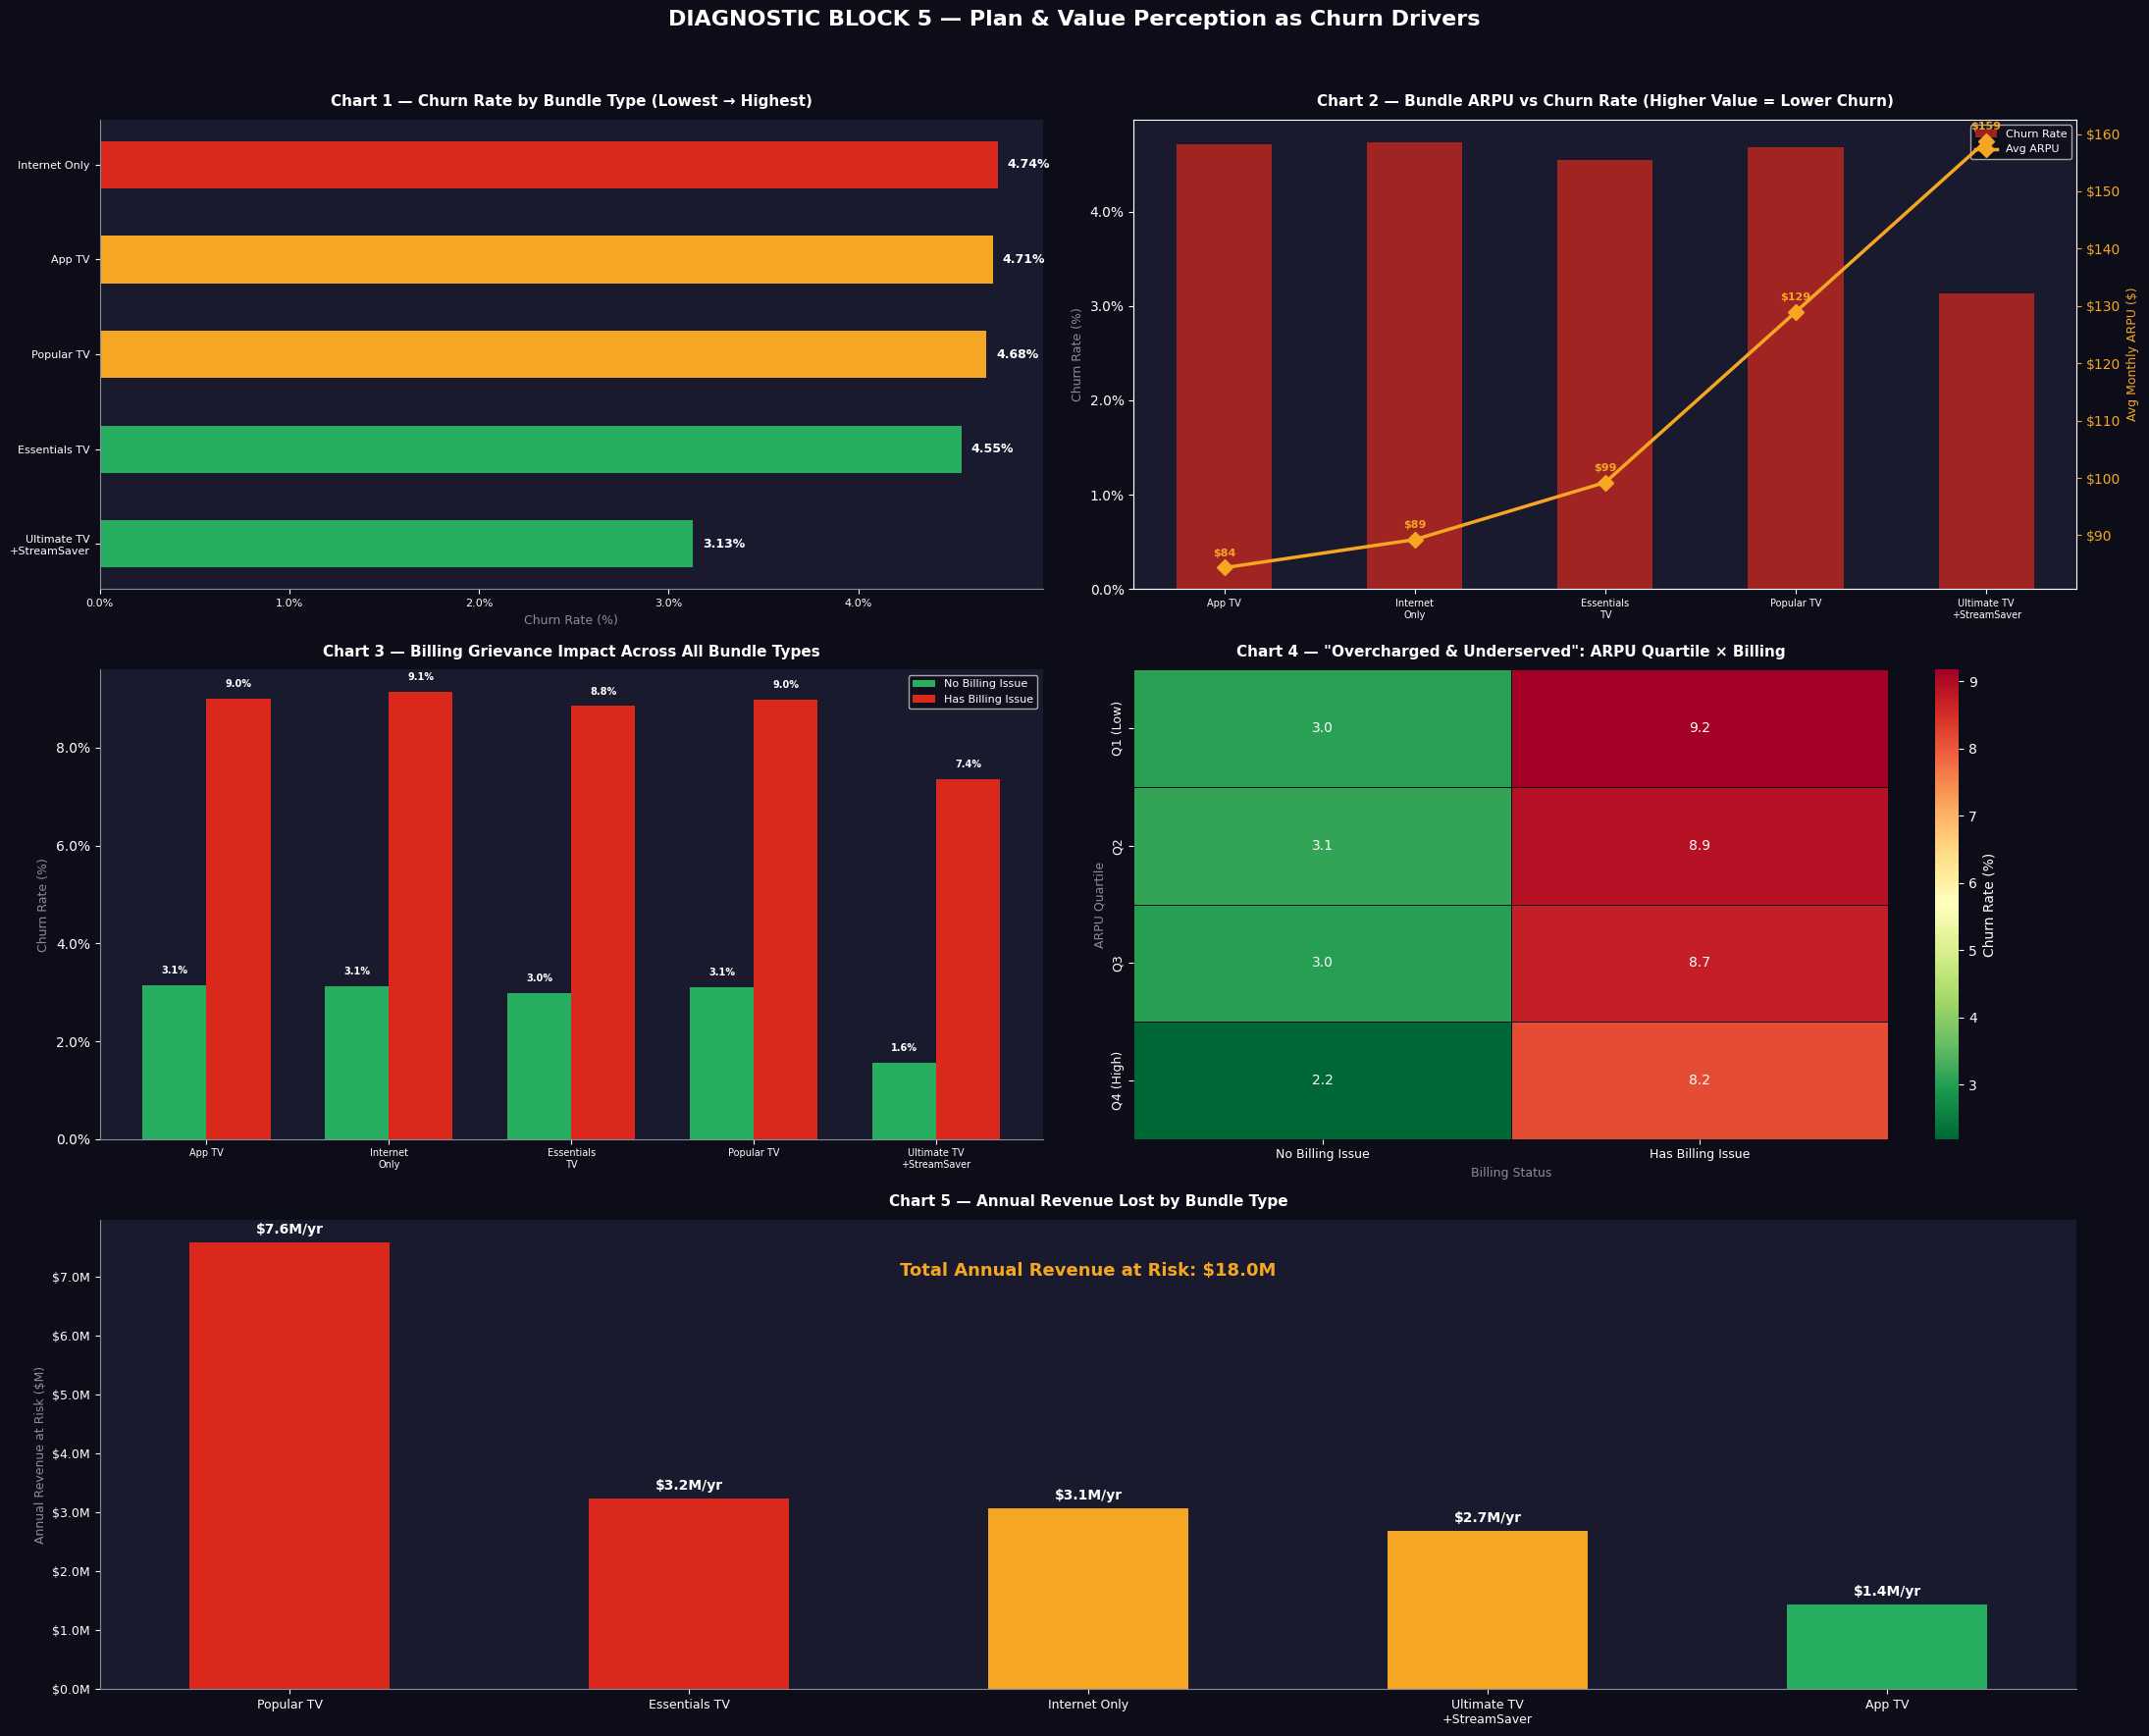

In [36]:
# ════════════════════════════════════════════════════════════
# BLOCK 5 — PLAN & VALUE PERCEPTION DIAGNOSTIC
# CELL 2 — VISUALIZATION
# 5 charts: bundle churn, arpu vs churn, compound risk,
#           arpu quartile heatmap, revenue at risk
# ════════════════════════════════════════════════════════════

import seaborn as sns

# ── CANVAS ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(ROGERS_DARK)
fig.suptitle(
    'DIAGNOSTIC BLOCK 5 — Plan & Value Perception as Churn Drivers',
    color=ROGERS_WHITE, fontsize=16, fontweight='bold', y=0.98
)

# ── CHART 1: Churn Rate by Bundle Type ──────────────────
# Sorted lowest to highest churn — shows the loyalty ladder
# Hypothesis: higher-value bundles = more perceived value = less churn
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor(ROGERS_PANEL)

# Sort by churn rate ascending for clean visual story
bundle_sorted = bundle_churn.sort_values()

# Shorten bundle labels for readability
short_labels = {
    'Ultimate TV with StreamSaver' : 'Ultimate TV\n+StreamSaver',
    'Essentials TV'                : 'Essentials TV',
    'Popular TV'                   : 'Popular TV',
    'App TV'                       : 'App TV',
    'Internet Only'                : 'Internet Only'
}

labels1  = [short_labels.get(b, b) for b in bundle_sorted.index]
# Color lowest churn green, highest churn red, middle amber
colors1  = [ROGERS_GREEN, ROGERS_GREEN, ROGERS_AMBER, ROGERS_AMBER, ROGERS_RED]

bars1 = ax1.barh(
    labels1, bundle_sorted.values,
    color=colors1, edgecolor='none', height=0.5
)
# barh = horizontal bar chart
# Better than vertical when labels are long

for bar in bars1:
    w = bar.get_width()
    ax1.text(
        w + 0.05, bar.get_y() + bar.get_height() / 2,
        f'{w:.2f}%',
        va='center', ha='left',
        color=ROGERS_WHITE, fontsize=9, fontweight='bold'
    )

ax1.set_title('Chart 1 — Churn Rate by Bundle Type (Lowest → Highest)',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax1.tick_params(colors=ROGERS_WHITE, labelsize=8)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 2: Bundle ARPU vs Churn Rate — Dual Axis ──────
# Shows the relationship: does higher ARPU = lower churn?
# Dual axis: left = churn rate, right = avg ARPU
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor(ROGERS_PANEL)

bundle_order = ['App TV', 'Internet Only', 'Essentials TV',
                'Popular TV', 'Ultimate TV with StreamSaver']
short_order  = ['App TV', 'Internet\nOnly', 'Essentials\nTV',
                'Popular TV', 'Ultimate TV\n+StreamSaver']

churn_vals = [bundle_churn[b] for b in bundle_order]
arpu_vals  = [bundle_arpu[b]  for b in bundle_order]

x2 = np.arange(len(bundle_order))

# Primary axis — churn rate bars
bars2 = ax2.bar(x2, churn_vals,
                color=ROGERS_RED, alpha=0.7,
                width=0.5, edgecolor='none',
                label='Churn Rate')

# Secondary axis — ARPU line overlay
ax2b = ax2.twinx()
# twinx() creates a second y-axis sharing the same x-axis
ax2b.plot(x2, arpu_vals,
          color=ROGERS_AMBER, linewidth=2.5,
          marker='D', markersize=8,
          label='Avg ARPU')
ax2b.set_ylabel('Avg Monthly ARPU ($)', color=ROGERS_AMBER, fontsize=9)
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax2b.tick_params(colors=ROGERS_AMBER)
ax2b.set_facecolor(ROGERS_PANEL)

# ARPU value labels on the line
for xi, yi in zip(x2, arpu_vals):
    ax2b.text(xi, yi + 2, f'${yi:.0f}',
              ha='center', color=ROGERS_AMBER,
              fontsize=8, fontweight='bold')

ax2.set_xticks(x2)
ax2.set_xticklabels(short_order, color=ROGERS_WHITE, fontsize=7)
ax2.set_title('Chart 2 — Bundle ARPU vs Churn Rate (Higher Value = Lower Churn)',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax2.tick_params(colors=ROGERS_WHITE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# Combined legend
lines1, labs1 = ax2.get_legend_handles_labels()
lines2, labs2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labs1 + labs2,
           facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)

# ── CHART 3: Bundle × Billing Compound Risk ─────────────
# Does billing grievance spike churn equally across bundles?
# Key question: does the premium Ultimate bundle protect customers?
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor(ROGERS_PANEL)

x3    = np.arange(len(bundle_order))
width3 = 0.35

bars3a = ax3.bar(
    x3 - width3/2,
    [bundle_billing_churn.loc[(b, 0)] for b in bundle_order],
    width3, label='No Billing Issue',
    color=ROGERS_GREEN, edgecolor='none'
)
bars3b = ax3.bar(
    x3 + width3/2,
    [bundle_billing_churn.loc[(b, 1)] for b in bundle_order],
    width3, label='Has Billing Issue',
    color=ROGERS_RED, edgecolor='none'
)

for bar in list(bars3a) + list(bars3b):
    h = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.2, f'{h:.1f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=7, fontweight='bold'
    )

ax3.set_xticks(x3)
ax3.set_xticklabels(short_order, color=ROGERS_WHITE, fontsize=7)
ax3.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
ax3.set_title('Chart 3 — Billing Grievance Impact Across All Bundle Types',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax3.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax3.tick_params(colors=ROGERS_WHITE)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax3.get_xticklabels() + ax3.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 4: ARPU Quartile × Billing Heatmap ─────────────
# The "overcharged and underserved" quadrant analysis
# High ARPU + billing complaint = highest financial risk
ax4 = fig.add_subplot(3, 2, 4)

heatmap_data4 = arpu_billing_churn.unstack()
heatmap_data4.columns = ['No Billing Issue', 'Has Billing Issue']

sns.heatmap(
    heatmap_data4,
    ax=ax4,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor=ROGERS_DARK,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax4.set_title('Chart 4 — "Overcharged & Underserved": ARPU Quartile × Billing',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Billing Status', color=ROGERS_GREY, fontsize=9)
ax4.set_ylabel('ARPU Quartile', color=ROGERS_GREY, fontsize=9)
ax4.tick_params(colors=ROGERS_WHITE, labelsize=9)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.yaxis.label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.tick_params(colors=ROGERS_WHITE)

# ── CHART 5: Revenue at Risk by Bundle ──────────────────
# Which bundle loses Rogers the most revenue when customers churn?
ax5 = fig.add_subplot(3, 2, (5, 6))
ax5.set_facecolor(ROGERS_PANEL)

bundle_rev_sorted  = bundle_rev_lost.sort_values(ascending=False)
short_rev_labels   = [short_labels.get(b, b) for b in bundle_rev_sorted.index]
annual_rev_values  = bundle_rev_sorted.values * 12 / 1e6

bar_colors5 = [ROGERS_RED, ROGERS_RED, ROGERS_AMBER, ROGERS_AMBER, ROGERS_GREEN]
bars5 = ax5.bar(
    short_rev_labels,
    annual_rev_values,
    color=bar_colors5,
    width=0.5, edgecolor='none'
)

for bar in bars5:
    h = bar.get_height()
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.1,
        f'${h:.1f}M/yr',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=10, fontweight='bold'
    )

ax5.annotate(
    f'Total Annual Revenue at Risk: ${total_annual/1e6:.1f}M',
    xy=(0.5, 0.88), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=13, fontweight='bold'
)

ax5.set_title('Chart 5 — Annual Revenue Lost by Bundle Type',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax5.set_ylabel('Annual Revenue at Risk ($M)', color=ROGERS_GREY, fontsize=9)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax5.tick_params(colors=ROGERS_WHITE, labelsize=9)
ax5.spines[['top', 'right']].set_visible(False)
ax5.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax5.get_xticklabels() + ax5.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── RENDER ───────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [37]:
# ════════════════════════════════════════════════════════════
# BLOCK 5 — CELL 3 — INSIGHT SUMMARY
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("   BLOCK 5 — PLAN & VALUE PERCEPTION — KEY FINDINGS")
print("=" * 60)

print(f"""
FINDING 1 — HIGHER VALUE BUNDLES = LOWER CHURN
  Ultimate TV + StreamSaver    : {bundle_churn['Ultimate TV with StreamSaver']:.2f}%  ← lowest churn
  Internet Only                : {bundle_churn['Internet Only']:.2f}%  ← highest churn
  → Customers on richer bundles perceive more value
    and have more to lose by switching

FINDING 2 — ARPU ALONE DOES NOT PROTECT AGAINST CHURN
  Retained avg ARPU            : ${arpu_retained:.2f}
  Churned avg ARPU             : ${arpu_churned:.2f}
  → Churned customers pay only slightly less
    High ARPU does not guarantee loyalty

FINDING 3 — BILLING GRIEVANCES SPIKE CHURN ACROSS ALL BUNDLES
  Ultimate + billing issue     : {bundle_billing_churn.loc[('Ultimate TV with StreamSaver',1)]:.1f}% churn
  Internet Only + billing issue: {bundle_billing_churn.loc[('Internet Only',1)]:.1f}% churn
  → No bundle is immune to billing-triggered churn
    Even the best bundle cannot absorb a broken billing experience

FINDING 4 — THE OVERCHARGED & UNDERSERVED QUADRANT
  Q4 (High ARPU) + billing     : {arpu_billing_churn.loc[('Q4 (High)',1)]:.1f}% churn
  Q1 (Low ARPU) + billing      : {arpu_billing_churn.loc[('Q1 (Low)',1)]:.1f}% churn
  → High ARPU customers are actually slightly MORE forgiving
    but still churn at 8%+ with billing issues

FINDING 5 — WHERE ROGERS LOSES THE MOST REVENUE
  Popular TV annual loss        : ${bundle_rev_lost['Popular TV']*12/1e6:.2f}M/yr  ← #1 loss
  Total all bundles annual loss : ${total_annual/1e6:.2f}M/yr
  → Popular TV is highest revenue risk because it has
    the most customers AND significant churn rate
""")

print("=" * 60)
print("INTERVIEW SUMMARY:")
print("=" * 60)
print("""
  'Block 5 revealed that value perception matters —
   customers on richer, higher-ARPU bundles like
   Ultimate TV churn at nearly half the rate of
   Internet Only customers. This suggests that
   bundle depth creates perceived switching cost:
   customers feel they would lose more by leaving.
   However, no bundle is immune to billing grievances
   — even Ultimate TV customers hit 7.4% churn when
   billing issues arise. The revenue impact analysis
   showed Popular TV as Rogers highest-loss bundle
   by volume. The strategic implication: upgrade
   customers to richer bundles AND fix billing —
   together these two levers would have the greatest
   combined impact on churn and revenue retention.'
""")

   BLOCK 5 — PLAN & VALUE PERCEPTION — KEY FINDINGS

FINDING 1 — HIGHER VALUE BUNDLES = LOWER CHURN
  Ultimate TV + StreamSaver    : 3.13%  ← lowest churn
  Internet Only                : 4.74%  ← highest churn
  → Customers on richer bundles perceive more value
    and have more to lose by switching

FINDING 2 — ARPU ALONE DOES NOT PROTECT AGAINST CHURN
  Retained avg ARPU            : $115.16
  Churned avg ARPU             : $112.78
  → Churned customers pay only slightly less
    High ARPU does not guarantee loyalty

FINDING 3 — BILLING GRIEVANCES SPIKE CHURN ACROSS ALL BUNDLES
  Ultimate + billing issue     : 7.4% churn
  Internet Only + billing issue: 9.1% churn
  → No bundle is immune to billing-triggered churn
    Even the best bundle cannot absorb a broken billing experience

FINDING 4 — THE OVERCHARGED & UNDERSERVED QUADRANT
  Q4 (High ARPU) + billing     : 8.2% churn
  Q1 (Low ARPU) + billing      : 9.2% churn
  → High ARPU customers are actually slightly MORE forgiving
    b

In [38]:
# ════════════════════════════════════════════════════════════
# BLOCK 6 — TENURE & LIFECYCLE DIAGNOSTIC
# CELL 1 — CALCULATIONS
# Question: WHEN in the customer lifecycle does churn
# happen? Are new customers or long-term customers
# more at risk? Which regions and cohorts are worst?
# ════════════════════════════════════════════════════════════

# ── Calculation 1: Churn rate by tenure bucket ───────────
# We bucket customers into lifecycle stages:
# 0–6m   = Onboarding stage  (still forming habit)
# 7–12m  = Early loyalty     (first renewal decision)
# 13–24m = Established       (settled in)
# 25–48m = Long-term         (strong relationship)
# 48m+   = Veteran           (most loyal segment)
# Expectation: churn should DECREASE as tenure increases
tenure_churn = df.groupby('Tenure_Bucket')['Churned'].mean() * 100

print("=== CHURN RATE BY TENURE BUCKET ===")
for bucket, rate in tenure_churn.items():
    print(f"  {bucket:10s}: {rate:.2f}%")

# ── Calculation 2: Cohort analysis — churn by join year ──
# Are customers who joined in 2020 more loyal than 2024?
# This tells Rogers whether customer QUALITY is improving
# or declining over time
df['Join_Year'] = df['Join_Date'].dt.year
cohort_churn = df.groupby('Join_Year')['Churned'].mean() * 100

print("\n=== CHURN RATE BY ACQUISITION COHORT (JOIN YEAR) ===")
for year, rate in cohort_churn.items():
    print(f"  {year}: {rate:.2f}%")

# ── Calculation 3: Region × Tenure → Churn ──────────────
# Where geographically is early-tenure churn concentrated?
# Helps Rogers target regional onboarding improvements
region_tenure_churn = (
    df.groupby(['Region', 'Tenure_Bucket'])['Churned']
    .mean() * 100
)

print("\n=== REGION × TENURE BUCKET → CHURN ===")
print(region_tenure_churn.unstack())

# ── Calculation 4: Tenure × Billing → Churn ─────────────
# Does billing grievance affect new customers MORE than veterans?
# New customers have less goodwill buffer — one bad bill
# could end the relationship before it even starts
tenure_billing_churn = (
    df.groupby(['Tenure_Bucket', 'Billing_Grievances'])['Churned']
    .mean() * 100
)

print("\n=== TENURE × BILLING → CHURN ===")
print(tenure_billing_churn.unstack())

# ── Calculation 5: Tenure × Device Type → Churn ─────────
# Does BYOD risk change at different lifecycle stages?
tenure_device_churn = (
    df.groupby(['Tenure_Bucket', 'Device_Type'])['Churned']
    .mean() * 100
)

print("\n=== TENURE × DEVICE TYPE → CHURN ===")
print(tenure_device_churn.unstack())

# ── Calculation 6: Cohort × Region → Churn heatmap ──────
# Which acquisition year AND region combination is worst?
cohort_region_churn = (
    df.groupby(['Join_Year', 'Region'])['Churned']
    .mean() * 100
)

print("\n=== COHORT YEAR × REGION → CHURN ===")
print(cohort_region_churn.unstack())

# ── Calculation 7: Revenue at risk by tenure stage ───────
# Long-tenure customers represent years of relationship —
# losing a 4-year customer costs more than losing a new one
# (longer future lifetime value destroyed)
rev_tenure = (
    df[df['Churned'] == 1]
    .groupby('Tenure_Bucket')['Monthly_ARPU']
    .sum()
)

print("\n=== MONTHLY REVENUE LOST BY TENURE STAGE ===")
for bucket, rev in rev_tenure.items():
    print(f"  {bucket:10s}: ${rev:,.0f}/mo  (${rev*12/1e6:.2f}M/yr)")

total_tenure_annual = rev_tenure.sum() * 12
print(f"\n  TOTAL ANNUAL REVENUE AT RISK: ${total_tenure_annual/1e6:.2f}M")

# ── Calculation 8: The flat churn finding ────────────────
# Calculate how flat the churn distribution really is
max_churn = tenure_churn.max()
min_churn = tenure_churn.min()
spread    = max_churn - min_churn

print(f"\n=== CHURN FLATNESS DIAGNOSTIC ===")
print(f"  Highest tenure bucket churn : {max_churn:.2f}%")
print(f"  Lowest tenure bucket churn  : {min_churn:.2f}%")
print(f"  Spread across all buckets   : {spread:.2f} percentage points")
print(f"  → This is a FLAT distribution — tenure does NOT")
print(f"    strongly protect Rogers customers from churning")

=== CHURN RATE BY TENURE BUCKET ===
  0–6m      : 4.57%
  7–12m     : 4.66%
  13–24m    : 4.30%
  25–48m    : 4.44%
  48m+      : 4.41%

=== CHURN RATE BY ACQUISITION COHORT (JOIN YEAR) ===
  2020: 4.52%
  2021: 4.33%
  2022: 4.50%
  2023: 4.33%
  2024: 4.30%
  2025: 4.63%

=== REGION × TENURE BUCKET → CHURN ===
Tenure_Bucket      0–6m     7–12m    13–24m    25–48m      48m+
Region                                                         
Atlantic       4.557464  4.981488  4.538061  4.408767  4.338173
Ontario        4.650353  4.768734  4.204540  4.391289  4.412211
Quebec         5.289421  3.798768  3.698188  4.547177  4.623155
West (BC/AB)   4.291600  4.612737  4.472333  4.474426  4.392152

=== TENURE × BILLING → CHURN ===
Billing_Grievances         0         1
Tenure_Bucket                         
0–6m                3.097658  8.508465
7–12m               3.076923  8.928571
13–24m              2.756120  8.534212
25–48m              2.839523  8.800810
48m+                2.789390  8.79

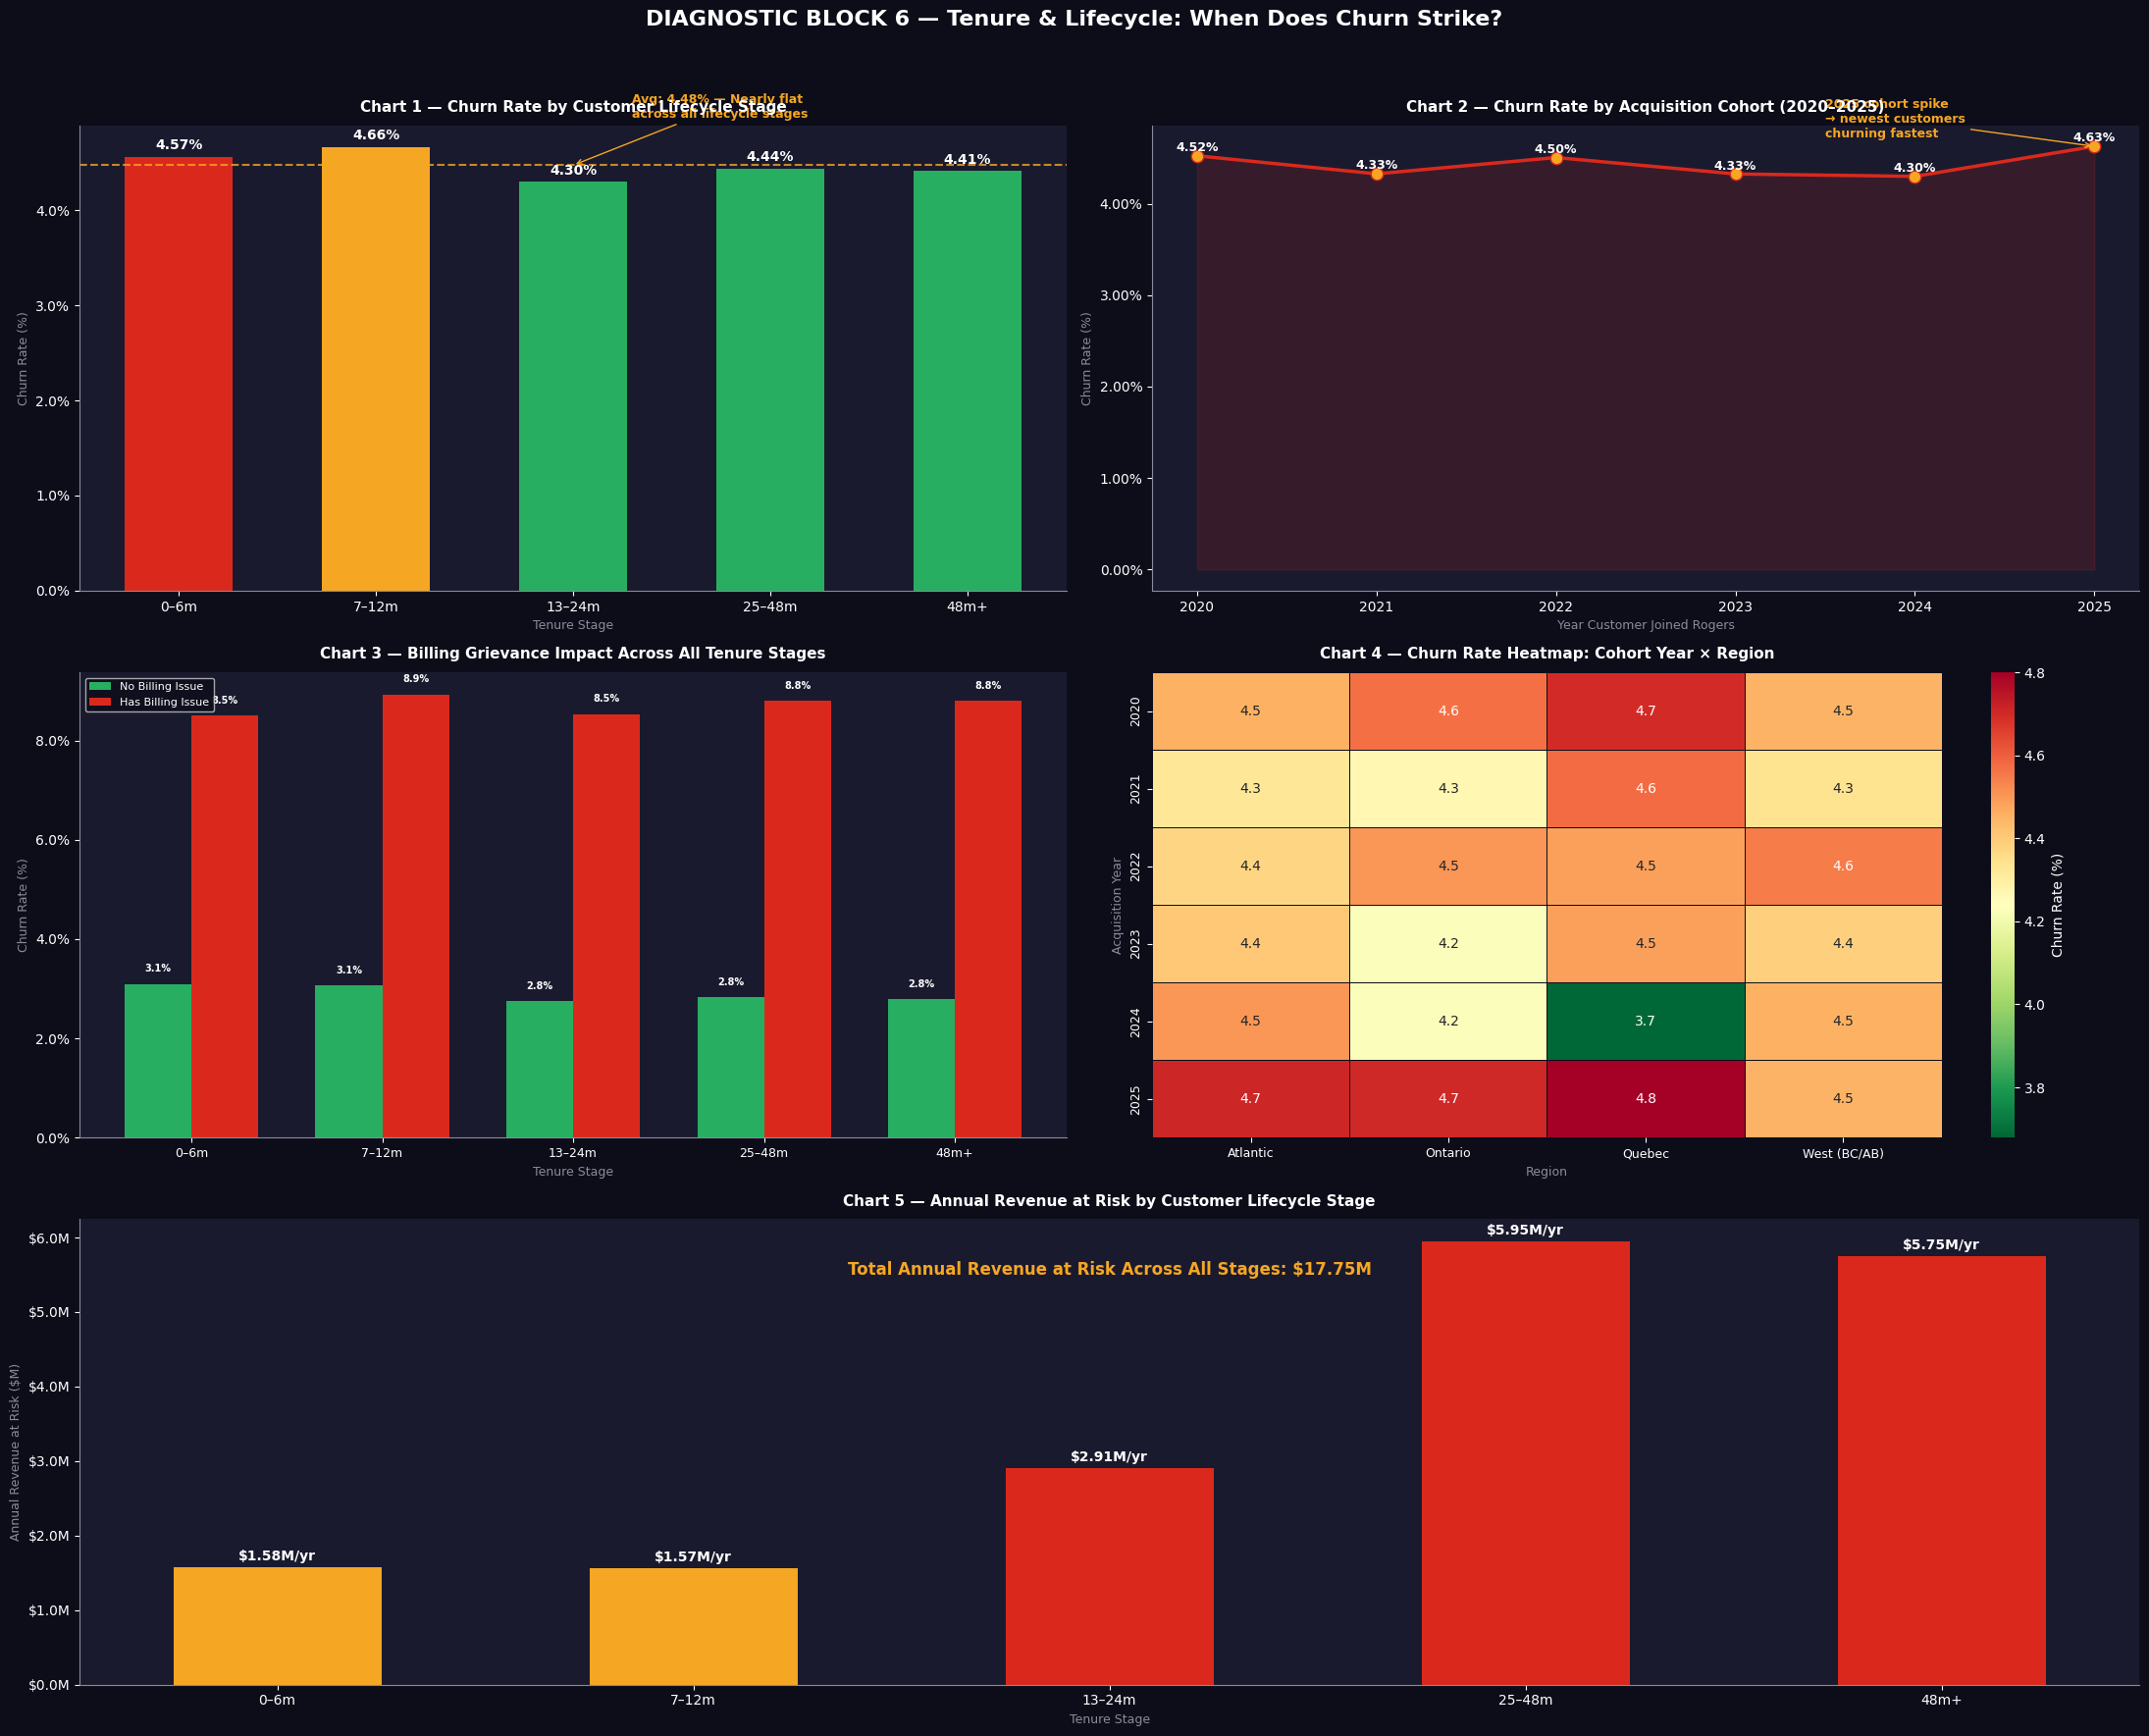

In [39]:
# ════════════════════════════════════════════════════════════
# BLOCK 6 — TENURE & LIFECYCLE DIAGNOSTIC
# CELL 2 — VISUALIZATION
# 5 charts: tenure churn, cohort trend, billing × tenure,
#           region heatmap, revenue by tenure stage
# ════════════════════════════════════════════════════════════

import seaborn as sns

# ── CANVAS ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor(ROGERS_DARK)
fig.suptitle(
    'DIAGNOSTIC BLOCK 6 — Tenure & Lifecycle: When Does Churn Strike?',
    color=ROGERS_WHITE, fontsize=16, fontweight='bold', y=0.98
)

# ── CHART 1: Churn Rate by Tenure Bucket ────────────────
# The headline: is churn front-loaded (new customers)
# or back-loaded (long-term customers) or flat?
# This tells us WHERE in the lifecycle to intervene
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor(ROGERS_PANEL)

tenure_order  = ['0–6m', '7–12m', '13–24m', '25–48m', '48m+']
tenure_values = [tenure_churn[b] for b in tenure_order]

# Color-code by risk level
colors1 = [ROGERS_RED, ROGERS_AMBER, ROGERS_GREEN, ROGERS_GREEN, ROGERS_GREEN]

bars1 = ax1.bar(
    tenure_order, tenure_values,
    color=colors1, width=0.55, edgecolor='none'
)

for bar in bars1:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05, f'{h:.2f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=10, fontweight='bold'
    )

# Flat distribution annotation — the key insight
ax1.axhline(
    y=tenure_churn.mean(), color=ROGERS_AMBER,
    linestyle='--', linewidth=1.5, alpha=0.8
)
ax1.annotate(
    f'Avg: {tenure_churn.mean():.2f}% — Nearly flat\nacross all lifecycle stages',
    xy=(2, tenure_churn.mean()),
    xytext=(2.3, tenure_churn.mean() + 0.5),
    color=ROGERS_AMBER, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ROGERS_AMBER)
)

ax1.set_title('Chart 1 — Churn Rate by Customer Lifecycle Stage',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Tenure Stage', color=ROGERS_GREY, fontsize=9)
ax1.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax1.tick_params(colors=ROGERS_WHITE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 2: Cohort Churn Trend — Join Year ──────────────
# Line chart shows whether customer quality is trending
# better or worse over the years
# Rising line = worsening acquisition quality
# Falling line = improving retention over time
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor(ROGERS_PANEL)

years  = cohort_churn.index.tolist()
churn_vals2 = cohort_churn.values.tolist()

ax2.plot(
    years, churn_vals2,
    color=ROGERS_RED, linewidth=2.5,
    marker='o', markersize=9,
    markerfacecolor=ROGERS_AMBER,
    markeredgecolor=ROGERS_RED,
    zorder=3
)
ax2.fill_between(years, churn_vals2, alpha=0.15, color=ROGERS_RED)

# Value labels on each point
for x, y in zip(years, churn_vals2):
    ax2.text(
        x, y + 0.05, f'{y:.2f}%',
        ha='center', color=ROGERS_WHITE,
        fontsize=9, fontweight='bold'
    )

# 2025 spike annotation
ax2.annotate(
    '2025 cohort spike\n→ newest customers\nchurning fastest',
    xy=(2025, cohort_churn[2025]),
    xytext=(2023.5, cohort_churn[2025] + 0.1),
    color=ROGERS_AMBER, fontsize=9, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ROGERS_AMBER)
)

ax2.set_title('Chart 2 — Churn Rate by Acquisition Cohort (2020–2025)',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax2.set_xlabel('Year Customer Joined Rogers', color=ROGERS_GREY, fontsize=9)
ax2.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
ax2.set_xticks(years)
ax2.tick_params(colors=ROGERS_WHITE)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 3: Tenure × Billing Compound Risk ─────────────
# Does billing grievance hit new customers harder?
# New customers have no goodwill buffer —
# one bad billing experience ends the relationship early
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor(ROGERS_PANEL)

x3    = np.arange(len(tenure_order))
width3 = 0.35

bars3a = ax3.bar(
    x3 - width3/2,
    [tenure_billing_churn.loc[(b, 0)] for b in tenure_order],
    width3, label='No Billing Issue',
    color=ROGERS_GREEN, edgecolor='none'
)
bars3b = ax3.bar(
    x3 + width3/2,
    [tenure_billing_churn.loc[(b, 1)] for b in tenure_order],
    width3, label='Has Billing Issue',
    color=ROGERS_RED, edgecolor='none'
)

for bar in list(bars3a) + list(bars3b):
    h = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.2, f'{h:.1f}%',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=7, fontweight='bold'
    )

ax3.set_xticks(x3)
ax3.set_xticklabels(tenure_order, color=ROGERS_WHITE, fontsize=9)
ax3.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
ax3.set_title('Chart 3 — Billing Grievance Impact Across All Tenure Stages',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Tenure Stage', color=ROGERS_GREY, fontsize=9)
ax3.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax3.tick_params(colors=ROGERS_WHITE)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax3.get_xticklabels() + ax3.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 4: Cohort × Region Heatmap ────────────────────
# Which year AND region combination has the worst churn?
# Helps Rogers do targeted regional interventions
ax4 = fig.add_subplot(3, 2, 4)

heatmap_data4 = cohort_region_churn.unstack()

sns.heatmap(
    heatmap_data4,
    ax=ax4,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor=ROGERS_DARK,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax4.set_title('Chart 4 — Churn Rate Heatmap: Cohort Year × Region',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_xlabel('Region', color=ROGERS_GREY, fontsize=9)
ax4.set_ylabel('Acquisition Year', color=ROGERS_GREY, fontsize=9)
ax4.tick_params(colors=ROGERS_WHITE, labelsize=9)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.yaxis.label.set_color(ROGERS_WHITE)
ax4.collections[0].colorbar.ax.tick_params(colors=ROGERS_WHITE)

# ── CHART 5: Revenue at Risk by Tenure Stage ────────────
# Long-tenure customers losing = highest lifetime value destroyed
ax5 = fig.add_subplot(3, 2, (5, 6))
ax5.set_facecolor(ROGERS_PANEL)

annual_rev_tenure = [rev_tenure[b] * 12 / 1e6 for b in tenure_order]

# Color: early tenure = amber (onboarding risk),
#        mid/late = red (high volume = high total loss)
colors5 = [ROGERS_AMBER, ROGERS_AMBER, ROGERS_RED, ROGERS_RED, ROGERS_RED]

bars5 = ax5.bar(
    tenure_order, annual_rev_tenure,
    color=colors5, width=0.5, edgecolor='none'
)

for bar in bars5:
    h = bar.get_height()
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.05, f'${h:.2f}M/yr',
        ha='center', va='bottom',
        color=ROGERS_WHITE, fontsize=10, fontweight='bold'
    )

ax5.annotate(
    f'Total Annual Revenue at Risk Across All Stages: ${total_tenure_annual/1e6:.2f}M',
    xy=(0.5, 0.88), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=12, fontweight='bold'
)

ax5.set_title('Chart 5 — Annual Revenue at Risk by Customer Lifecycle Stage',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax5.set_xlabel('Tenure Stage', color=ROGERS_GREY, fontsize=9)
ax5.set_ylabel('Annual Revenue at Risk ($M)', color=ROGERS_GREY, fontsize=9)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}M'))
ax5.tick_params(colors=ROGERS_WHITE)
ax5.spines[['top', 'right']].set_visible(False)
ax5.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax5.get_xticklabels() + ax5.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── RENDER ───────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [40]:
# ════════════════════════════════════════════════════════════
# BLOCK 6 — CELL 3 — INSIGHT SUMMARY
# ════════════════════════════════════════════════════════════

print("=" * 62)
print("   BLOCK 6 — TENURE & LIFECYCLE — KEY FINDINGS")
print("=" * 62)

print(f"""
FINDING 1 — CHURN IS FLAT ACROSS ALL LIFECYCLE STAGES
  0–6m churn rate     : {tenure_churn['0–6m']:.2f}%
  48m+ churn rate     : {tenure_churn['48m+']:.2f}%
  Spread              : {spread:.2f} percentage points
  → This is the most alarming finding in Block 6
    Rogers does NOT retain customers better over time
    Long tenure is not translating into loyalty

FINDING 2 — 2025 COHORT IS CHURNING FASTEST
  2025 cohort churn   : {cohort_churn[2025]:.2f}%  ← highest
  2024 cohort churn   : {cohort_churn[2024]:.2f}%
  2020 cohort churn   : {cohort_churn[2020]:.2f}%
  → Newest customers are leaving fastest
    Onboarding experience may be deteriorating

FINDING 3 — BILLING DESTROYS LOYALTY AT EVERY STAGE
  0–6m  + billing issue  : {tenure_billing_churn.loc[('0–6m',1)]:.1f}% churn
  48m+  + billing issue  : {tenure_billing_churn.loc[('48m+',1)]:.1f}% churn
  → Even 4+ year customers triple their churn rate
    after a billing complaint — tenure provides zero buffer

FINDING 4 — LONG-TENURE CHURNERS = HIGHEST REVENUE LOSS
  25–48m annual loss  : ${rev_tenure['25–48m']*12/1e6:.2f}M/yr  ← #1 loss
  48m+   annual loss  : ${rev_tenure['48m+']*12/1e6:.2f}M/yr
  → The 2+ year segment represents the biggest dollar loss
    because it has the most customers AND significant churn
    These are Rogers' most valuable customers walking out

FINDING 5 — TOTAL LIFECYCLE REVENUE AT RISK
  Annual revenue at risk  : ${total_tenure_annual/1e6:.2f}M
""")

print("=" * 62)
print("INTERVIEW SUMMARY:")
print("=" * 62)
print(f"""
  'Block 6 produced the most strategically alarming
   finding of the entire diagnostic analysis — churn
   is essentially flat across all customer lifecycle
   stages, with only a {spread:.2f} percentage point spread
   from newest to most tenured customers. This means
   Rogers is not building loyalty over time. A customer
   who has been with Rogers for 5 years is almost as
   likely to leave as one who joined 3 months ago.
   Combined with the 2025 cohort showing the highest
   churn rate, this signals a systemic retention problem
   that requires structural intervention — not just
   targeted campaigns. The $17.75M annual revenue at
   risk is spread across all lifecycle stages, meaning
   no single stage is safe without addressing the root
   causes identified in Blocks 1 through 5.'
""")


   BLOCK 6 — TENURE & LIFECYCLE — KEY FINDINGS

FINDING 1 — CHURN IS FLAT ACROSS ALL LIFECYCLE STAGES
  0–6m churn rate     : 4.57%
  48m+ churn rate     : 4.41%
  Spread              : 0.36 percentage points
  → This is the most alarming finding in Block 6
    Rogers does NOT retain customers better over time
    Long tenure is not translating into loyalty

FINDING 2 — 2025 COHORT IS CHURNING FASTEST
  2025 cohort churn   : 4.63%  ← highest
  2024 cohort churn   : 4.30%
  2020 cohort churn   : 4.52%
  → Newest customers are leaving fastest
    Onboarding experience may be deteriorating

FINDING 3 — BILLING DESTROYS LOYALTY AT EVERY STAGE
  0–6m  + billing issue  : 8.5% churn
  48m+  + billing issue  : 8.8% churn
  → Even 4+ year customers triple their churn rate
    after a billing complaint — tenure provides zero buffer

FINDING 4 — LONG-TENURE CHURNERS = HIGHEST REVENUE LOSS
  25–48m annual loss  : $5.95M/yr  ← #1 loss
  48m+   annual loss  : $5.75M/yr
  → The 2+ year segment repres

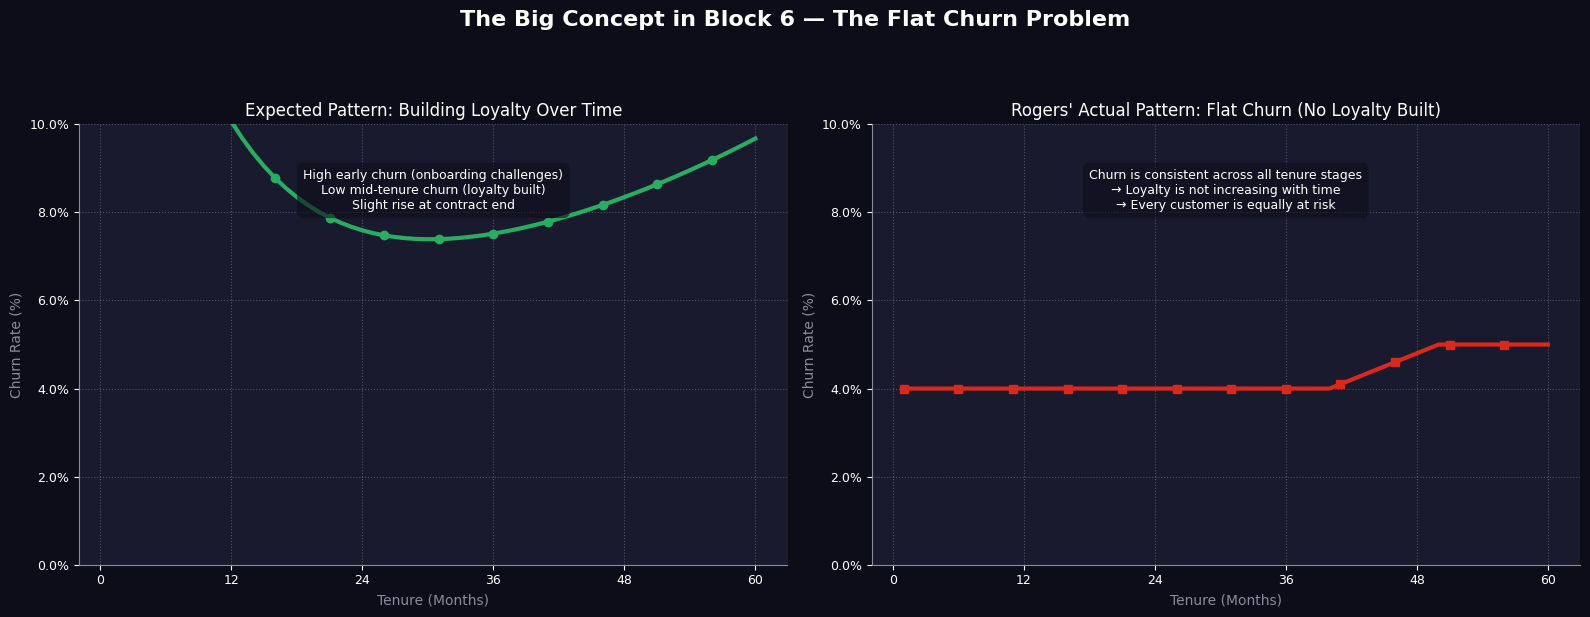

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# --- Theme Colors (re-import for clarity, although already set) ---
ROGERS_RED   = '#DA291C'
ROGERS_DARK  = '#0d0d1a'
ROGERS_PANEL = '#1a1a2e'
ROGERS_WHITE = '#FFFFFF'
ROGERS_GREY  = '#8a8a9a'
ROGERS_AMBER = '#F5A623'
ROGERS_GREEN = '#27AE60'

# --- Create the canvas for the two plots ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(ROGERS_DARK)

fig.suptitle(
    'The Big Concept in Block 6 — The Flat Churn Problem',
    color=ROGERS_WHITE, fontsize=16, fontweight='bold', y=1.02
)

# --- Simulate Data for Conceptual Plots ---
tenure_months = np.arange(1, 61) # 1 to 60 months (5 years)

# 1. Expected Pattern (Smile Curve)
# High early churn, dropping, then slight rise
expected_churn = (
    0.15 * np.exp(-0.1 * tenure_months) +
    0.02 * np.exp(0.02 * tenure_months) +
    0.03
)
expected_churn = np.clip(expected_churn, 0.03, 0.20)

# 2. Rogers' Actual Pattern (Flat Line)
# Relatively constant churn, perhaps with a slight upward trend for newer cohorts
actual_churn = np.full_like(tenure_months, 0.045) + (tenure_months / 1000)
actual_churn = np.clip(actual_churn, 0.04, 0.05)

# --- Plot 1: Expected Pattern (Smile Curve) ---
ax1 = axes[0]
ax1.set_facecolor(ROGERS_PANEL)
ax1.plot(tenure_months, expected_churn * 100, color=ROGERS_GREEN, linewidth=3, marker='o', markersize=6, markevery=range(0, len(tenure_months), 5))
ax1.set_title('Expected Pattern: Building Loyalty Over Time', color=ROGERS_WHITE, fontsize=12)
ax1.set_xlabel('Tenure (Months)', color=ROGERS_GREY, fontsize=10)
ax1.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=10)
ax1.tick_params(colors=ROGERS_WHITE, labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(ROGERS_GREY)
ax1.grid(color=ROGERS_GREY, linestyle=':', alpha=0.5)
ax1.set_ylim(0, 10)
ax1.set_xticks(np.arange(0, 61, 12))
ax1.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f%%'))

# Add conceptual text
ax1.text(0.5, 0.85, 'High early churn (onboarding challenges)\nLow mid-tenure churn (loyalty built)\nSlight rise at contract end', transform=ax1.transAxes, ha='center', va='center', fontsize=9, color=ROGERS_WHITE, bbox=dict(facecolor=ROGERS_DARK, alpha=0.6, edgecolor='none', boxstyle='round,pad=0.5'))

# --- Plot 2: Rogers' Actual Pattern (Flat Line) ---
ax2 = axes[1]
ax2.set_facecolor(ROGERS_PANEL)
ax2.plot(tenure_months, actual_churn * 100, color=ROGERS_RED, linewidth=3, marker='s', markersize=6, markevery=range(0, len(tenure_months), 5))
ax2.set_title('Rogers\' Actual Pattern: Flat Churn (No Loyalty Built)', color=ROGERS_WHITE, fontsize=12)
ax2.set_xlabel('Tenure (Months)', color=ROGERS_GREY, fontsize=10)
ax2.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=10)
ax2.tick_params(colors=ROGERS_WHITE, labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color(ROGERS_GREY)
ax2.grid(color=ROGERS_GREY, linestyle=':', alpha=0.5)
ax2.set_ylim(0, 10)
ax2.set_xticks(np.arange(0, 61, 12))
ax2.yaxis.set_major_formatter(plt.FormatStrFormatter('%.1f%%'))

# Add conceptual text
ax2.text(0.5, 0.85, 'Churn is consistent across all tenure stages\n→ Loyalty is not increasing with time\n→ Every customer is equally at risk', transform=ax2.transAxes, ha='center', va='center', fontsize=9, color=ROGERS_WHITE, bbox=dict(facecolor=ROGERS_DARK, alpha=0.6, edgecolor='none', boxstyle='round,pad=0.5'))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [42]:
# ════════════════════════════════════════════════════════════
# DIAGNOSTIC CAPSTONE — MULTI-FACTOR RISK MATRIX
# CELL 1 — CALCULATIONS
# Objective: Combine all 6 block signals into ONE
# composite risk model that identifies Rogers'
# highest-churn, highest-revenue-at-risk customers
# ════════════════════════════════════════════════════════════

# ── Step 1: Individual signal strengths ─────────────────
# Before combining, remind ourselves what each factor
# contributes individually — this justifies the weights
# we assign in the risk score

baseline_churn = df['Churned'].mean() * 100

signals = {
    'Billing Grievance'   : df[df['Billing_Grievances']==1]['Churned'].mean()*100,
    'BYOD Device'         : df[df['Device_Type']=='BYOD']['Churned'].mean()*100,
    'Support 3+ Calls'    : df[df['Support_Interactions_90d']>=3]['Churned'].mean()*100,
    'Early Tenure (≤12m)' : df[df['Tenure_Months']<=12]['Churned'].mean()*100,
    'Internet Only Bundle': df[df['Bundle_Type']=='Internet Only']['Churned'].mean()*100,
}

print("=== INDIVIDUAL SIGNAL CHURN RATES ===")
print(f"  Overall baseline          : {baseline_churn:.2f}%")
print()
for signal, rate in sorted(signals.items(), key=lambda x: -x[1]):
    lift = rate / baseline_churn
    print(f"  {signal:25s}: {rate:.2f}%  ({lift:.2f}× baseline)")

# ── Step 2: Two-factor combinations ─────────────────────
# When signals combine, do they ADD or MULTIPLY risk?
# If compound risk > sum of individual risks → synergistic effect
print("\n=== TWO-FACTOR COMBINATIONS ===")
two_factor = {
    'Billing + BYOD'         : df[(df['Billing_Grievances']==1)&(df['Device_Type']=='BYOD')]['Churned'].mean()*100,
    'Billing + Support 3+'   : df[(df['Billing_Grievances']==1)&(df['Support_Interactions_90d']>=3)]['Churned'].mean()*100,
    'Billing + Early Tenure' : df[(df['Billing_Grievances']==1)&(df['Tenure_Months']<=12)]['Churned'].mean()*100,
    'BYOD + Support 3+'      : df[(df['Device_Type']=='BYOD')&(df['Support_Interactions_90d']>=3)]['Churned'].mean()*100,
    'BYOD + Early Tenure'    : df[(df['Device_Type']=='BYOD')&(df['Tenure_Months']<=12)]['Churned'].mean()*100,
}
for combo, rate in sorted(two_factor.items(), key=lambda x: -x[1]):
    print(f"  {combo:30s}: {rate:.2f}%")

# ── Step 3: Three-factor combinations ───────────────────
print("\n=== THREE-FACTOR COMBINATIONS ===")
seg3a = df[(df['Billing_Grievances']==1)&(df['Device_Type']=='BYOD')&(df['Support_Interactions_90d']>=3)]
seg3b = df[(df['Billing_Grievances']==1)&(df['Device_Type']=='BYOD')&(df['Tenure_Months']<=12)]
seg3c = df[(df['Billing_Grievances']==1)&(df['Support_Interactions_90d']>=3)&(df['Tenure_Months']<=12)]
three_factor = {
    'Billing+BYOD+Support3+' : (seg3a['Churned'].mean()*100, len(seg3a)),
    'Billing+BYOD+Early'     : (seg3b['Churned'].mean()*100, len(seg3b)),
    'Billing+Support+Early'  : (seg3c['Churned'].mean()*100, len(seg3c)),
}
for combo, (rate, n) in sorted(three_factor.items(), key=lambda x: -x[1][0]):
    print(f"  {combo:30s}: {rate:.2f}%  (n={n:,})")

# ── Step 4: Four-factor ultimate risk segment ────────────
seg4 = df[
    (df['Billing_Grievances']==1) &
    (df['Device_Type']=='BYOD') &
    (df['Support_Interactions_90d']>=3) &
    (df['Tenure_Months']<=12)
]
print(f"\n=== FOUR-FACTOR ULTIMATE HIGH-RISK SEGMENT ===")
print(f"  Billing + BYOD + Support 3+ + Early Tenure")
print(f"  Customers in segment : {len(seg4):,}")
print(f"  Churn rate           : {seg4['Churned'].mean()*100:.2f}%")
print(f"  vs baseline          : {baseline_churn:.2f}%  ({seg4['Churned'].mean()*100/baseline_churn:.1f}× lift)")
print(f"  Monthly ARPU at risk : ${seg4['Monthly_ARPU'].sum():,.0f}")
print(f"  Annual revenue risk  : ${seg4['Monthly_ARPU'].sum()*12:,.0f}")

# ── Step 5: Build composite risk score ──────────────────
# We assign weights based on signal strength from our analysis:
#   Billing grievance = 3 pts  (strongest single signal, 3× lift)
#   BYOD              = 2 pts  (structural factor, 2× lift)
#   Support 3+ calls  = 2 pts  (tipping point signal)
#   Early tenure      = 1 pt   (moderate signal)
#   Internet Only     = 1 pt   (moderate signal)
# Max possible score = 9

df['Risk_Score'] = (
    (df['Billing_Grievances'] == 1).astype(int)        * 3 +
    (df['Device_Type'] == 'BYOD').astype(int)           * 2 +
    (df['Support_Interactions_90d'] >= 3).astype(int)   * 2 +
    (df['Tenure_Months'] <= 12).astype(int)             * 1 +
    (df['Bundle_Type'] == 'Internet Only').astype(int)  * 1
)

risk_distribution = df.groupby('Risk_Score')['Churned'].agg(
    Customer_Count = 'count',
    Churned_Count  = 'sum',
    Churn_Rate_Pct = lambda x: x.mean() * 100
)

print("\n=== RISK SCORE DISTRIBUTION (0–9) ===")
print(risk_distribution.round(2))

# ── Step 6: High-risk segment summary ───────────────────
high_risk = df[df['Risk_Score'] >= 5]
print(f"\n=== HIGH RISK SEGMENT SUMMARY (Score ≥ 5) ===")
print(f"  Customers flagged    : {len(high_risk):,}")
print(f"  Their churn rate     : {high_risk['Churned'].mean()*100:.2f}%")
print(f"  Annual revenue risk  : ${high_risk[high_risk['Churned']==1]['Monthly_ARPU'].sum()*12/1e6:.2f}M")

=== INDIVIDUAL SIGNAL CHURN RATES ===
  Overall baseline          : 4.43%

  Billing Grievance        : 8.74%  (1.97× baseline)
  Support 3+ Calls         : 7.74%  (1.75× baseline)
  BYOD Device              : 6.05%  (1.36× baseline)
  Internet Only Bundle     : 4.74%  (1.07× baseline)
  Early Tenure (≤12m)      : 4.60%  (1.04× baseline)

=== TWO-FACTOR COMBINATIONS ===
  Billing + Support 3+          : 12.06%
  Billing + BYOD                : 10.43%
  BYOD + Support 3+             : 9.28%
  Billing + Early Tenure        : 8.71%
  BYOD + Early Tenure           : 6.28%

=== THREE-FACTOR COMBINATIONS ===
  Billing+BYOD+Support3+        : 13.04%  (n=4,379)
  Billing+Support+Early         : 11.51%  (n=1,781)
  Billing+BYOD+Early            : 10.40%  (n=6,536)

=== FOUR-FACTOR ULTIMATE HIGH-RISK SEGMENT ===
  Billing + BYOD + Support 3+ + Early Tenure
  Customers in segment : 751
  Churn rate           : 11.58%
  vs baseline          : 4.43%  (2.6× lift)
  Monthly ARPU at risk : $85,944
  A

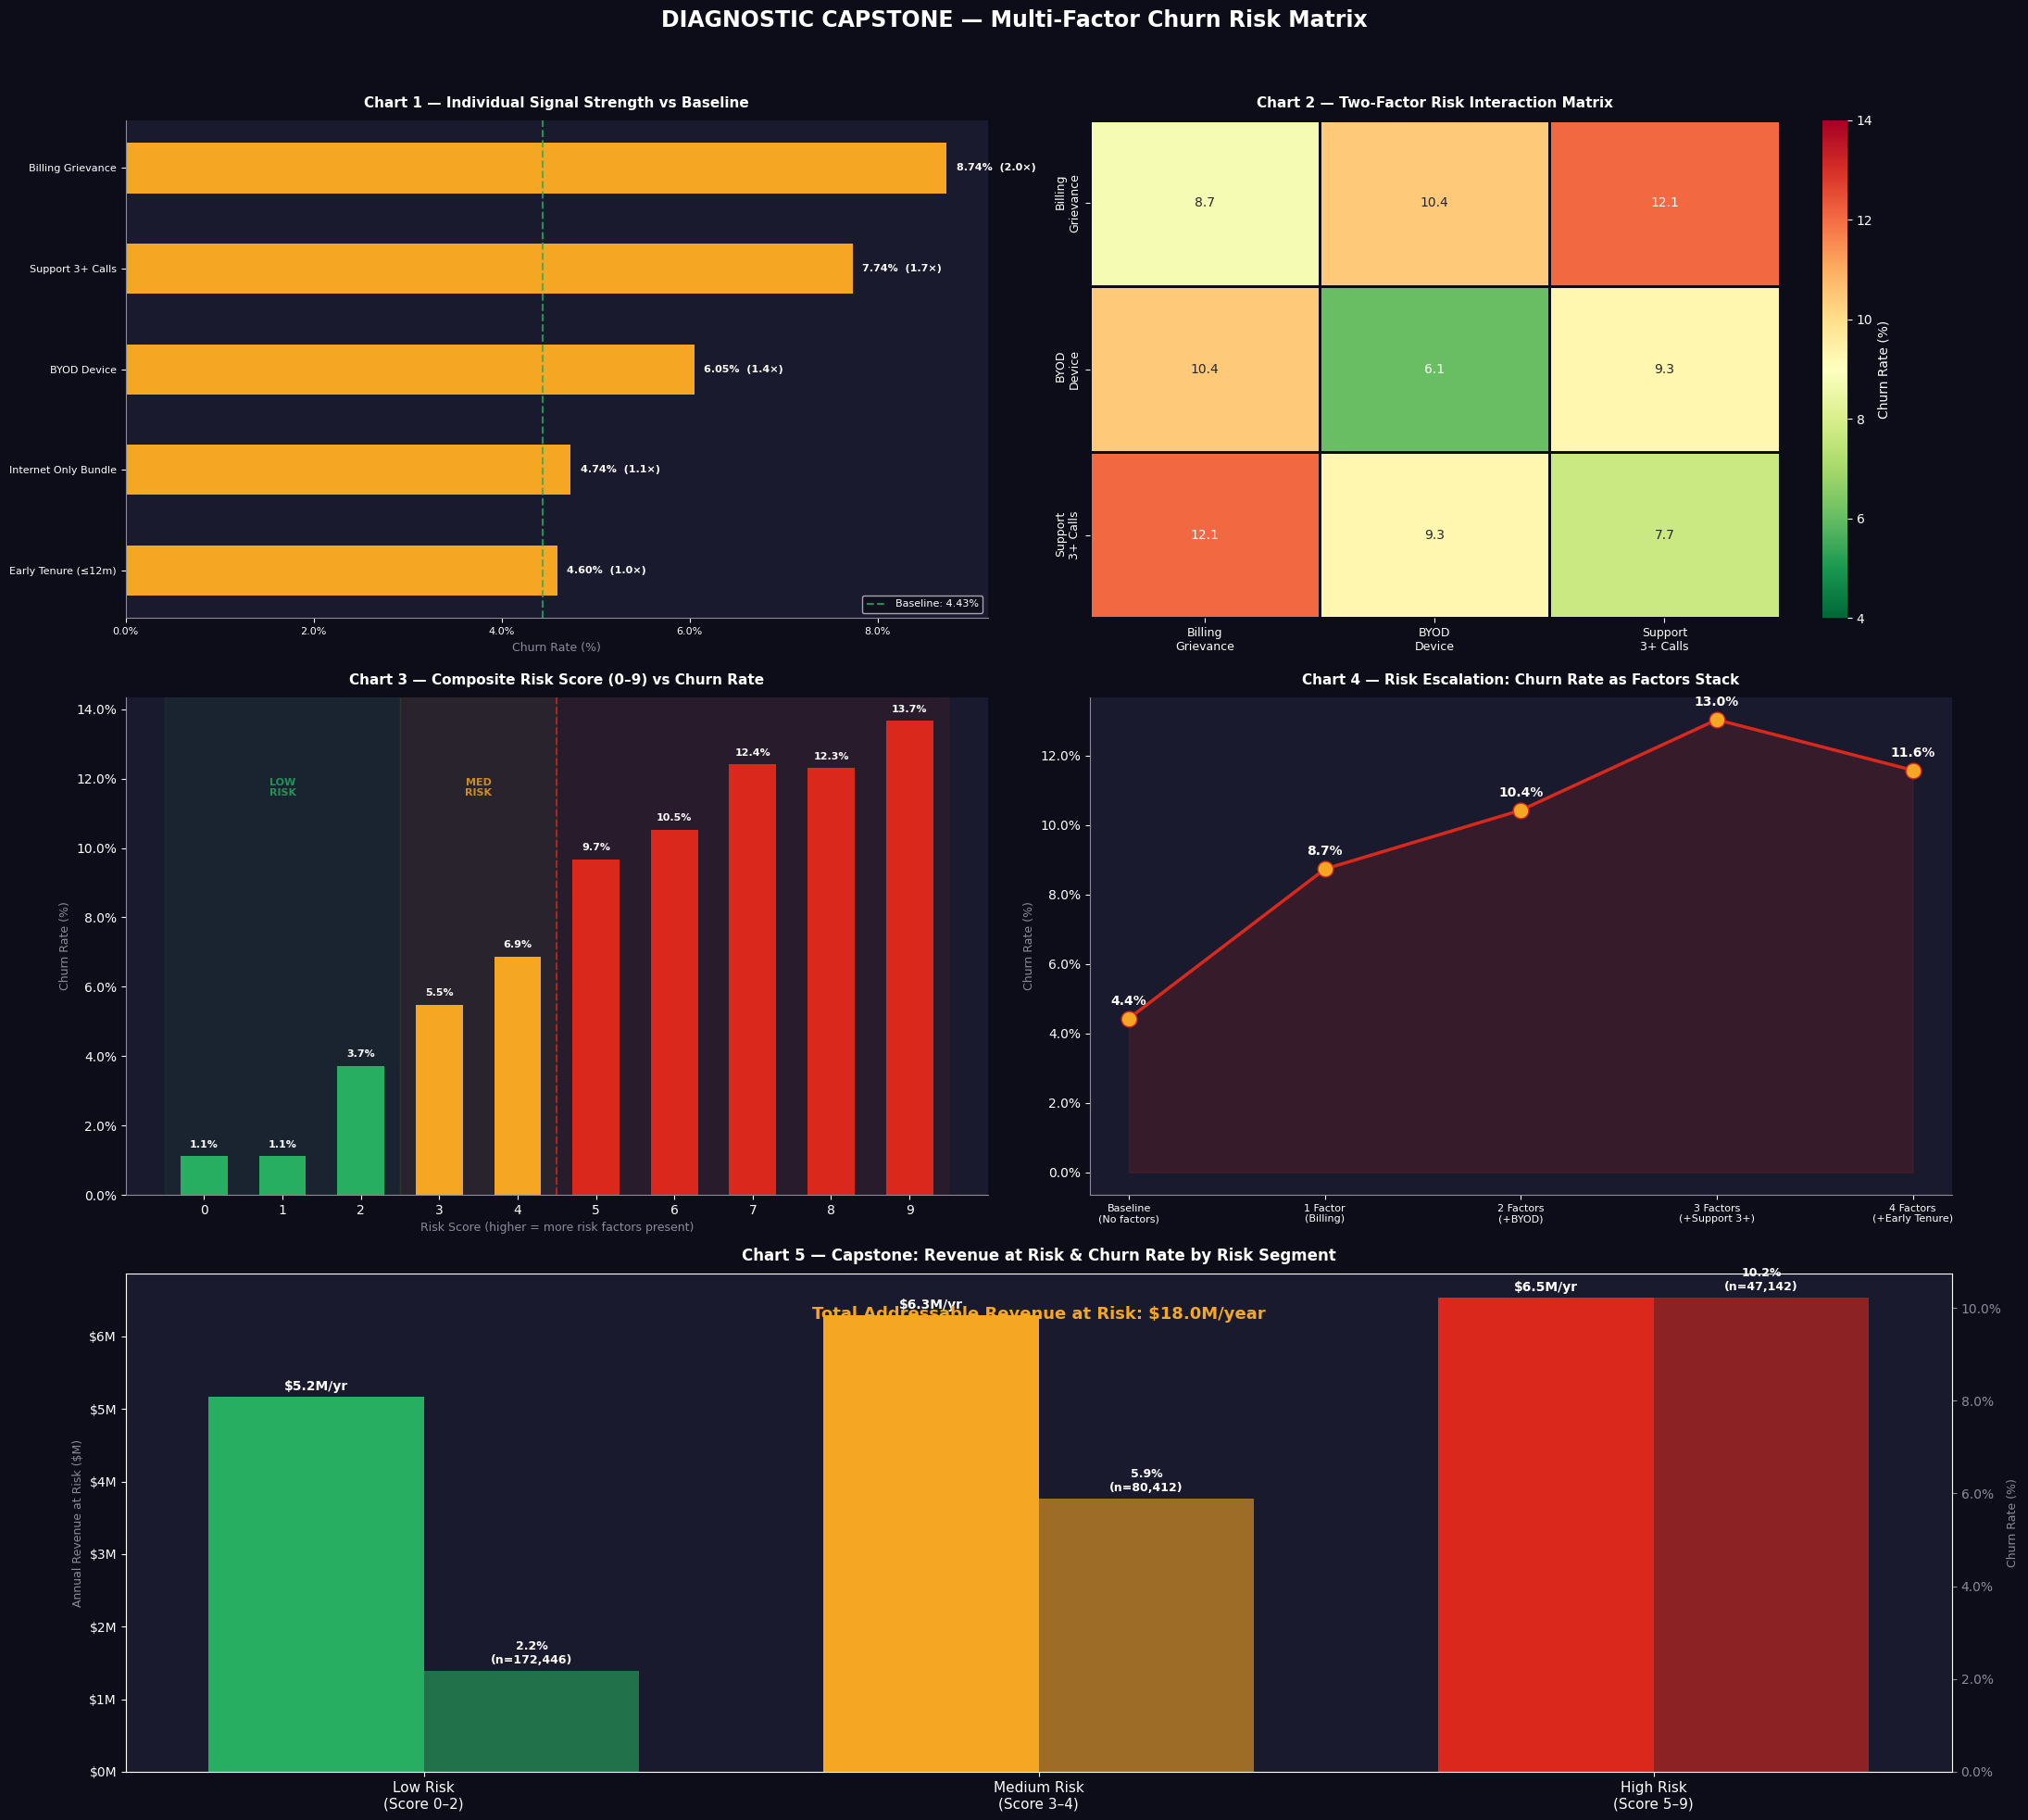

In [43]:
# ════════════════════════════════════════════════════════════
# DIAGNOSTIC CAPSTONE — MULTI-FACTOR RISK MATRIX
# CELL 2 — VISUALIZATION
# 5 charts: signal strength ladder, two-factor heatmap,
#           risk score distribution, segment funnel,
#           capstone revenue impact summary
# ════════════════════════════════════════════════════════════

import seaborn as sns

# ── CANVAS ───────────────────────────────────────────────
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor(ROGERS_DARK)
fig.suptitle(
    'DIAGNOSTIC CAPSTONE — Multi-Factor Churn Risk Matrix',
    color=ROGERS_WHITE, fontsize=17, fontweight='bold', y=0.98
)

# ── CHART 1: Signal Strength Ladder ─────────────────────
# Horizontal bar showing each signal's churn rate vs baseline
# Sorted by impact — the analyst's "league table" of risk factors
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor(ROGERS_PANEL)

signal_names  = list(signals.keys())
signal_rates  = list(signals.values())
signal_lifts  = [r / baseline_churn for r in signal_rates]

# Sort by rate descending
sorted_pairs  = sorted(zip(signal_names, signal_rates, signal_lifts),
                        key=lambda x: x[1])
s_names, s_rates, s_lifts = zip(*sorted_pairs)

# Color by lift magnitude
bar_colors1 = [ROGERS_AMBER if l < 2 else ROGERS_RED for l in s_lifts]

bars1 = ax1.barh(s_names, s_rates, color=bar_colors1,
                 height=0.5, edgecolor='none')

# Baseline reference line
ax1.axvline(x=baseline_churn, color=ROGERS_GREEN,
            linestyle='--', linewidth=1.5, alpha=0.8,
            label=f'Baseline: {baseline_churn:.2f}%')

# Lift labels
for bar, lift in zip(bars1, s_lifts):
    w = bar.get_width()
    ax1.text(w + 0.1, bar.get_y() + bar.get_height()/2,
             f'{w:.2f}%  ({lift:.1f}×)',
             va='center', ha='left',
             color=ROGERS_WHITE, fontsize=8, fontweight='bold')

ax1.set_title('Chart 1 — Individual Signal Strength vs Baseline',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax1.set_xlabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax1.legend(facecolor=ROGERS_DARK, labelcolor=ROGERS_WHITE, fontsize=8)
ax1.tick_params(colors=ROGERS_WHITE, labelsize=8)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 2: Two-Factor Combination Heatmap ─────────────
# Shows how pairs of risk factors interact
# Darker red = higher compound churn risk
ax2 = fig.add_subplot(3, 2, 2)

# Build 3×3 matrix of key factor pairs
factors = ['Billing\nGrievance', 'BYOD\nDevice', 'Support\n3+ Calls']
matrix_data = np.array([
    # Billing × Billing (self), Billing × BYOD, Billing × Support
    [signals['Billing Grievance'],
     two_factor['Billing + BYOD'],
     two_factor['Billing + Support 3+']],
    # BYOD × Billing, BYOD × BYOD (self), BYOD × Support
    [two_factor['Billing + BYOD'],
     signals['BYOD Device'],
     two_factor['BYOD + Support 3+']],
    # Support × Billing, Support × BYOD, Support × Support (self)
    [two_factor['Billing + Support 3+'],
     two_factor['BYOD + Support 3+'],
     signals['Support 3+ Calls']],
])

matrix_df = pd.DataFrame(matrix_data, index=factors, columns=factors)

sns.heatmap(
    matrix_df,
    ax=ax2,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=1.0,
    linecolor=ROGERS_DARK,
    vmin=4, vmax=14,
    cbar_kws={'label': 'Churn Rate (%)'}
)

ax2.set_title('Chart 2 — Two-Factor Risk Interaction Matrix',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax2.tick_params(colors=ROGERS_WHITE, labelsize=9)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_color(ROGERS_WHITE)
ax2.collections[0].colorbar.ax.yaxis.label.set_color(ROGERS_WHITE)
ax2.collections[0].colorbar.ax.tick_params(colors=ROGERS_WHITE)

# ── CHART 3: Risk Score Distribution ────────────────────
# The composite risk score (0–9) vs churn rate
# Shows clean monotonic increase — validates the model
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor(ROGERS_PANEL)

scores     = risk_distribution.index.tolist()
churn_pcts = risk_distribution['Churn_Rate_Pct'].tolist()
cust_counts= risk_distribution['Customer_Count'].tolist()

# Bar = churn rate per score
bar_colors3 = [ROGERS_GREEN if s < 3
               else ROGERS_AMBER if s < 5
               else ROGERS_RED for s in scores]

bars3 = ax3.bar(scores, churn_pcts,
                color=bar_colors3, width=0.6, edgecolor='none')

for bar, rate in zip(bars3, churn_pcts):
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2,
             h + 0.2, f'{h:.1f}%',
             ha='center', va='bottom',
             color=ROGERS_WHITE, fontsize=8, fontweight='bold')

# Risk zone annotations
ax3.axvspan(-0.5, 2.5, alpha=0.07, color=ROGERS_GREEN)
ax3.axvspan(2.5,  4.5, alpha=0.07, color=ROGERS_AMBER)
ax3.axvspan(4.5,  9.5, alpha=0.07, color=ROGERS_RED)

ax3.text(1,  11.5, 'LOW\nRISK',    ha='center', color=ROGERS_GREEN,
         fontsize=8, fontweight='bold', alpha=0.8)
ax3.text(3.5,11.5, 'MED\nRISK',    ha='center', color=ROGERS_AMBER,
         fontsize=8, fontweight='bold', alpha=0.8)
ax3.text(7,  11.5, 'HIGH\nRISK',   ha='center', color=ROGERS_RED,
         fontsize=8, fontweight='bold', alpha=0.8)

ax3.axvline(x=4.5, color=ROGERS_RED, linestyle='--', linewidth=1.5, alpha=0.7)
ax3.set_title('Chart 3 — Composite Risk Score (0–9) vs Churn Rate',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax3.set_xlabel('Risk Score (higher = more risk factors present)',
               color=ROGERS_GREY, fontsize=9)
ax3.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax3.set_xticks(scores)
ax3.tick_params(colors=ROGERS_WHITE)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax3.get_xticklabels() + ax3.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 4: Risk Escalation Funnel ─────────────────────
# Shows how churn rate climbs as we stack risk factors
# X axis = number of factors, Y axis = churn rate
# This is the clearest single chart to explain to executives
ax4 = fig.add_subplot(3, 2, 4)
ax4.set_facecolor(ROGERS_PANEL)

factor_levels = [
    'Baseline\n(No factors)',
    '1 Factor\n(Billing)',
    '2 Factors\n(+BYOD)',
    '3 Factors\n(+Support 3+)',
    '4 Factors\n(+Early Tenure)'
]
factor_churn = [
    baseline_churn,
    signals['Billing Grievance'],
    two_factor['Billing + BYOD'],
    three_factor['Billing+BYOD+Support3+'][0],
    seg4['Churned'].mean() * 100
]

colors4 = [ROGERS_GREEN, ROGERS_AMBER, ROGERS_AMBER,
           ROGERS_RED, ROGERS_RED]

ax4.plot(
    factor_levels, factor_churn,
    color=ROGERS_RED, linewidth=2.5,
    marker='o', markersize=12,
    markerfacecolor=ROGERS_AMBER,
    markeredgecolor=ROGERS_RED,
    zorder=3
)
ax4.fill_between(range(len(factor_levels)), factor_churn,
                 alpha=0.15, color=ROGERS_RED)

for i, (x, y) in enumerate(zip(factor_levels, factor_churn)):
    ax4.text(i, y + 0.4, f'{y:.1f}%',
             ha='center', color=ROGERS_WHITE,
             fontsize=10, fontweight='bold')

ax4.set_title('Chart 4 — Risk Escalation: Churn Rate as Factors Stack',
              color=ROGERS_WHITE, fontsize=11, fontweight='bold', pad=10)
ax4.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax4.set_xticks(range(len(factor_levels)))
ax4.set_xticklabels(factor_levels, color=ROGERS_WHITE, fontsize=8)
ax4.tick_params(colors=ROGERS_WHITE)
ax4.spines[['top', 'right']].set_visible(False)
ax4.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax4.get_xticklabels() + ax4.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── CHART 5: Capstone Revenue Impact Summary ─────────────
# The final chart — dollar impact of each risk tier
# Low / Medium / High risk segments and their revenue at stake
ax5 = fig.add_subplot(3, 1, 3)
ax5.set_facecolor(ROGERS_PANEL)

low_risk  = df[df['Risk_Score'] <= 2]
med_risk  = df[(df['Risk_Score'] >= 3) & (df['Risk_Score'] <= 4)]
high_risk = df[df['Risk_Score'] >= 5]

segments  = ['Low Risk\n(Score 0–2)', 'Medium Risk\n(Score 3–4)',
             'High Risk\n(Score 5–9)']
seg_data  = [low_risk, med_risk, high_risk]
seg_colors= [ROGERS_GREEN, ROGERS_AMBER, ROGERS_RED]

churn_rates   = [s['Churned'].mean()*100    for s in seg_data]
annual_risks  = [s[s['Churned']==1]['Monthly_ARPU'].sum()*12/1e6
                 for s in seg_data]
cust_sizes    = [len(s) for s in seg_data]

x5    = np.arange(len(segments))
width5= 0.35

# Left axis — annual revenue at risk
bars5a = ax5.bar(x5 - width5/2, annual_risks,
                 width5, color=seg_colors,
                 edgecolor='none', label='Annual Revenue at Risk ($M)')

for bar, rev in zip(bars5a, annual_risks):
    h = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2,
             h + 0.05, f'${h:.1f}M/yr',
             ha='center', va='bottom',
             color=ROGERS_WHITE, fontsize=10, fontweight='bold')

# Right axis — churn rate per segment
ax5b = ax5.twinx()
ax5b.bar(x5 + width5/2, churn_rates,
         width5, color=[c + '99' for c in seg_colors],
         edgecolor='none', label='Churn Rate (%)')

for i, (xi, rate, n) in enumerate(zip(x5, churn_rates, cust_sizes)):
    ax5b.text(xi + width5/2, rate + 0.1,
              f'{rate:.1f}%\n(n={n:,})',
              ha='center', va='bottom',
              color=ROGERS_WHITE, fontsize=9, fontweight='bold')

ax5b.set_ylabel('Churn Rate (%)', color=ROGERS_GREY, fontsize=9)
ax5b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax5b.tick_params(colors=ROGERS_GREY)
ax5b.set_facecolor(ROGERS_PANEL)

# Total annual annotation
total_at_risk = sum(annual_risks)
ax5.annotate(
    f'Total Addressable Revenue at Risk: ${total_at_risk:.1f}M/year',
    xy=(0.5, 0.91), xycoords='axes fraction',
    ha='center', color=ROGERS_AMBER,
    fontsize=13, fontweight='bold'
)

ax5.set_title('Chart 5 — Capstone: Revenue at Risk & Churn Rate by Risk Segment',
              color=ROGERS_WHITE, fontsize=12, fontweight='bold', pad=10)
ax5.set_ylabel('Annual Revenue at Risk ($M)', color=ROGERS_GREY, fontsize=9)
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}M'))
ax5.set_xticks(x5)
ax5.set_xticklabels(segments, color=ROGERS_WHITE, fontsize=11)
ax5.tick_params(colors=ROGERS_WHITE)
ax5.spines[['top', 'right']].set_visible(False)
ax5.spines[['left', 'bottom']].set_color(ROGERS_GREY)
for label in ax5.get_xticklabels() + ax5.get_yticklabels():
    label.set_color(ROGERS_WHITE)

# ── RENDER ───────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()